# Phase 1 : Business Understanding

## Problem Statement

While traditional decision trees and even ensemble methods such as Random Forests remain widely used in machine learning, they exhibit important limitations when dealing with high-dimensional datasets, noisy variables, or small node sizes during tree construction. In such situations, the splitting decisions become increasingly unstable and may approach random behavior, reducing the model’s predictive quality and its ability to correctly identify the most relevant variables. The RLT method was specifically designed to address these issues: it enhances split selection through a reinforcement learning mechanism that considers long term rewards, progressively removes uninformative variables through a variable muting procedure, and allows for more flexible linear-combination splits. By evaluating RLT across a diverse set of real world classification and regression tasks, the goal is to determine whether it provides improved stability, clearer interpretability, and superior predictive performance compared to classical tree-based methods.

### Business Objective 1 : 

The goal is to explore a new method "Reinforcement Learning Trees (RLT) " to improve predictive performance when data become large or complex.

### Business Objective 2 : 

We want to improve decision quality by reducing the influence of useless information: since datasets often contain noise, the aim is to build a system that focuses more on the information that truly matters.

### Business Objective 3 : 

The objective is to achieve an approach that remains stable, fast, and reliable result even when the structure of the data makes learning difficult for standard models.

### Data Science Objective 1 :

We will evaluate the behavior of RLT across different types of data .

### Data Science Objective 2 :

We want to analyze how RLT selects important information: since models sometimes rely on data that are not useful, the objective is to verify whether RLT can better identify meaningful indicators and filter out those that weaken the results.

### Data Science Objective 3 :

We will compare RLT with classical methods to move from a simple assumption to a precise evaluation of its performance. The aim is to determine whether it truly offers an improvement and to identify what could be enhanced if limitations appear.

# Phase 2 : Data Understanding

In [143]:
%run Pipeline.ipynb

In [145]:
df1 = load_dataset("Data/BreastCanDT.csv")
df2 = load_dataset("Data/auto-mpg.csv")
df3 = load_dataset("Data/concrete_data.csv")
df4 = load_dataset("Data/HousingData.csv")
df5 = load_dataset("Data/ozone.csv")
df6 = load_dataset("Data/parkinsons.csv")
df7 = load_dataset("Data/ReplicatedAcousticFeatures-ParkinsonDatabase.csv")
df8 = load_dataset("Data/sonar.csv")
df9 = load_dataset("Data/winequality-red.csv")
df10 = load_dataset("Data/winequality-white.csv")

Chargement du dataset : Data/BreastCanDT.csv
Chargement du dataset : Data/auto-mpg.csv
Chargement du dataset : Data/concrete_data.csv
Chargement du dataset : Data/HousingData.csv
Chargement du dataset : Data/ozone.csv
Chargement du dataset : Data/parkinsons.csv
Chargement du dataset : Data/ReplicatedAcousticFeatures-ParkinsonDatabase.csv
Chargement du dataset : Data/sonar.csv
Chargement du dataset : Data/winequality-red.csv
Chargement du dataset : Data/winequality-white.csv


In [147]:
df = {
    "df1": df1, "df2": df2, "df3": df3, "df4": df4,
    "df5": df5, "df6": df6, "df7": df7, "df8": df8,
    "df9": df9, "df10": df10
}
TARGET_COLS = {
'df1': 'diagnosis',
'df2': 'mpg', 
'df3': 'concrete_compressive_strength',
'df4': 'MEDV', 
'df5': 'obs',
'df6': 'status', 
'df8': 'R', 
'df7': 'Status',
'df9': 'quality',
'df10': 'quality',
}

TASKS = {
    'df1': 'classification', 'df2': 'regression', 'df3': 'regression',
    'df4': 'regression', 'df5': 'regression', 'df6': 'classification',
    'df7': 'classification', 'df8': 'regression', 'df9': 'regression',
    'df10': 'regression'
}



 Dataset 1/14 : df1

🔹 Shape: (569, 33)

🔹 First 5 rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



🔹 Last 5 rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN



🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se     

...


🔹 Duplicate rows count: 0

🔹 Target variable preview:


,diagnosis
0,M
1,M
2,M
3,M
4,M



🔹 Number of outliers per numeric column:


{'id': 81,
 'radius_mean': 14,
 'texture_mean': 7,
 'perimeter_mean': 13,
 'area_mean': 25,
 'smoothness_mean': 6,
 'compactness_mean': 16,
 'concavity_mean': 18,
 'concave points_mean': 10,
 'symmetry_mean': 15,
 'fractal_dimension_mean': 15,
 'radius_se': 38,
 'texture_se': 20,
 'perimeter_se': 38,
 'area_se': 65,
 'smoothness_se': 30,
 'compactness_se': 28,
 'concavity_se': 22,
 'concave points_se': 19,
 'symmetry_se': 27,
 'fractal_dimension_se': 28,
 'radius_worst': 17,
 'texture_worst': 5,
 'perimeter_worst': 15,
 'area_worst': 35,
 'smoothness_worst': 7,
 'compactness_worst': 16,
 'concavity_worst': 12,
 'concave points_worst': 0,
 'symmetry_worst': 23,
 'fractal_dimension_worst': 24,
 'Unnamed: 32': 0}


Distribution des variables numériques :


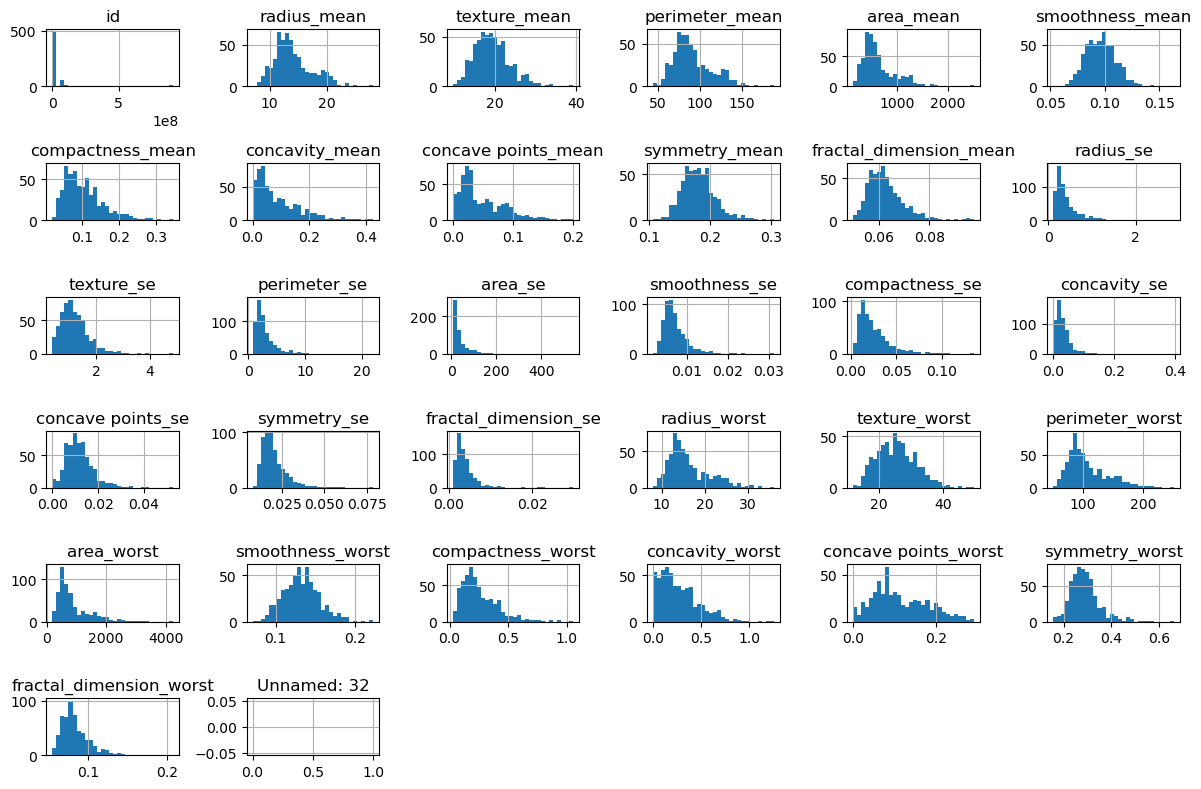

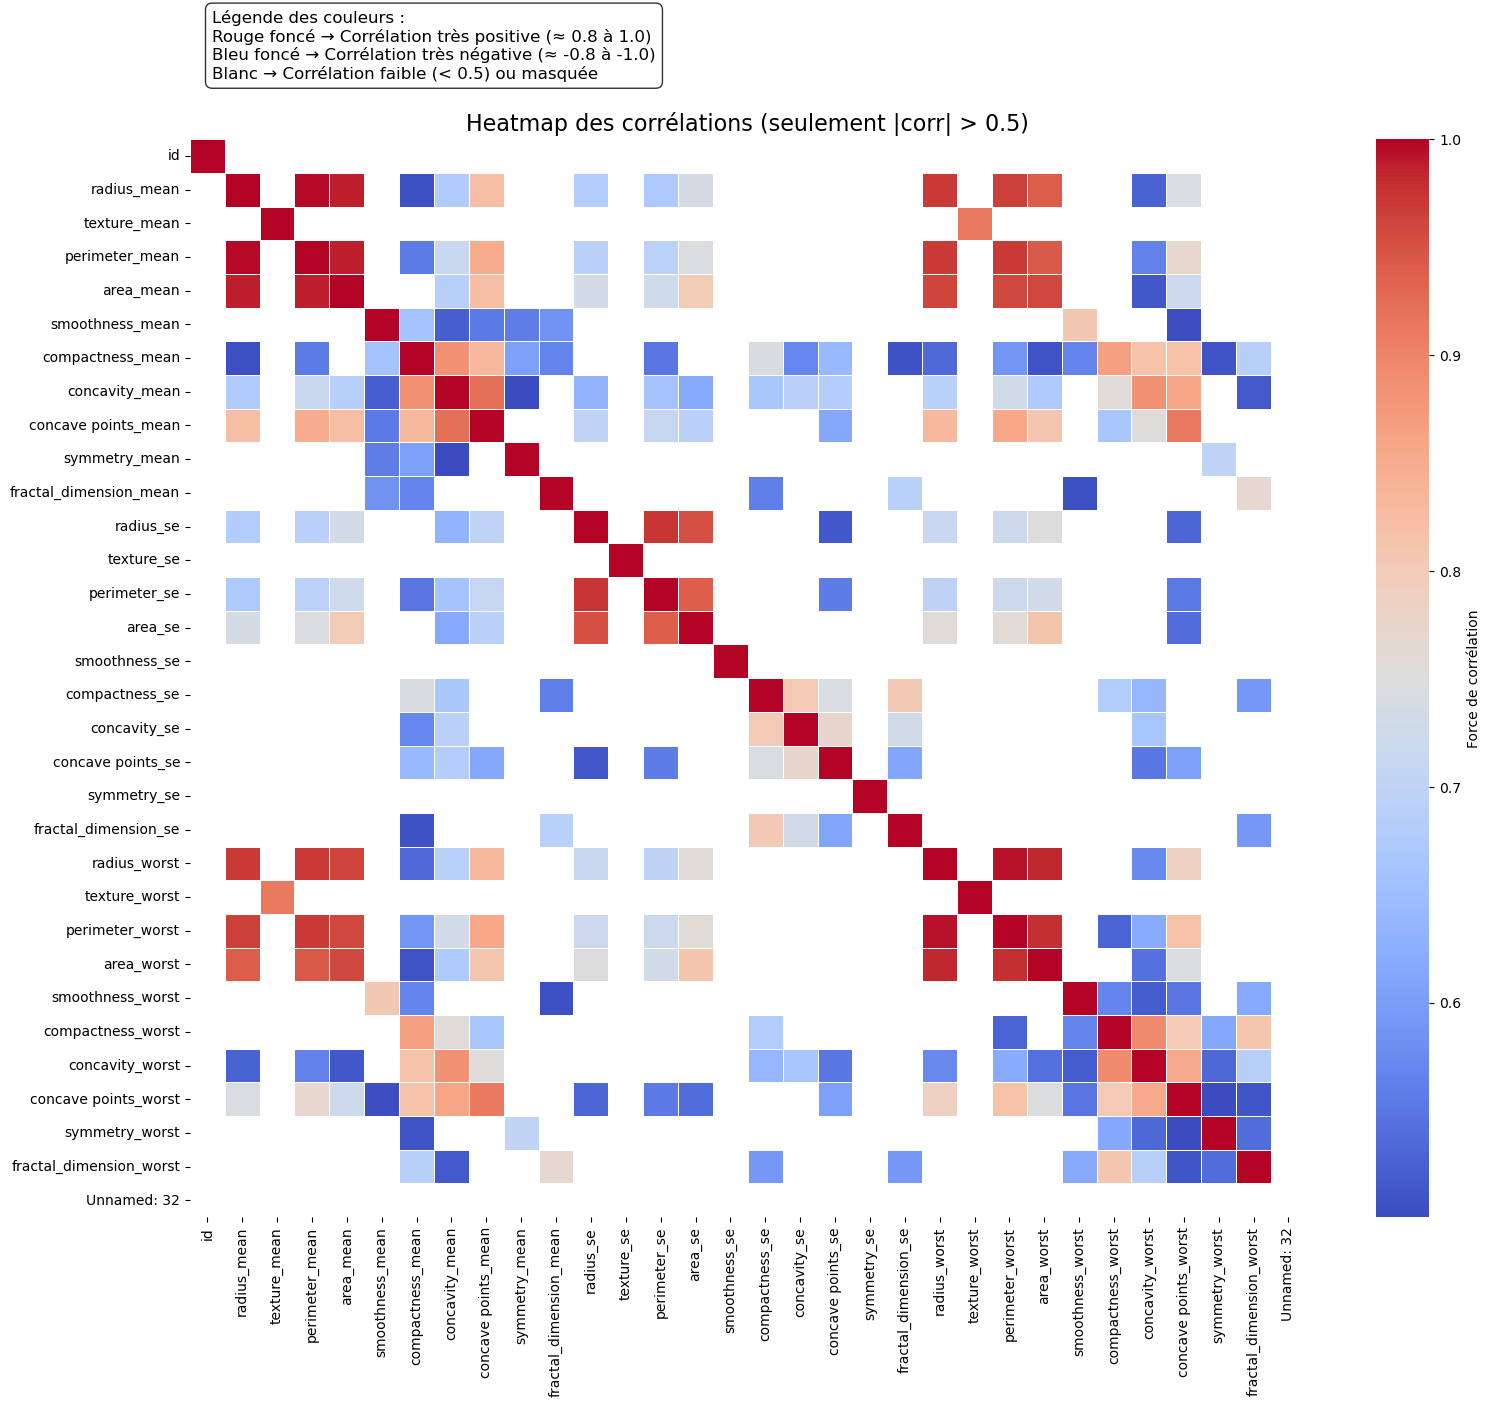

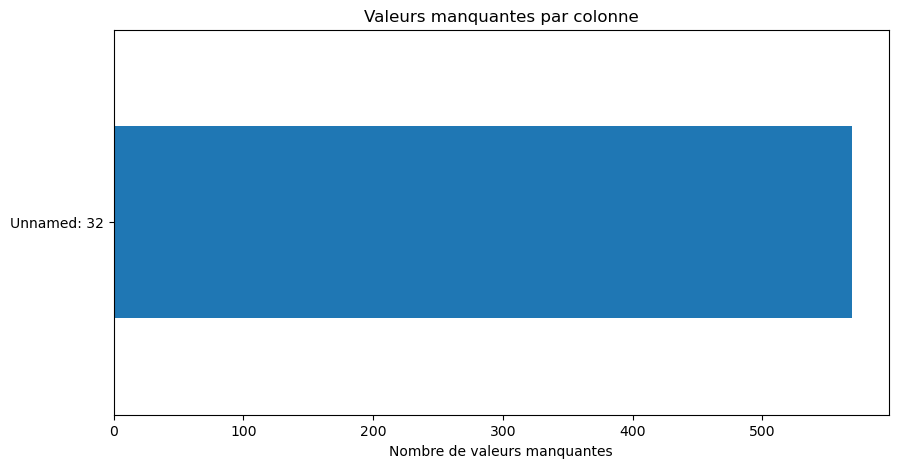

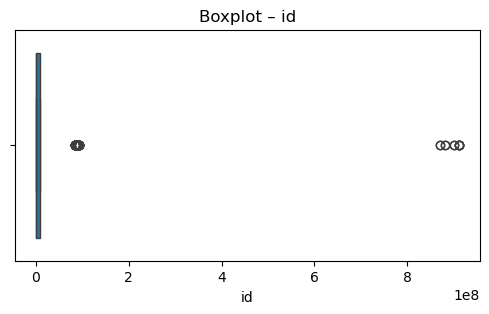

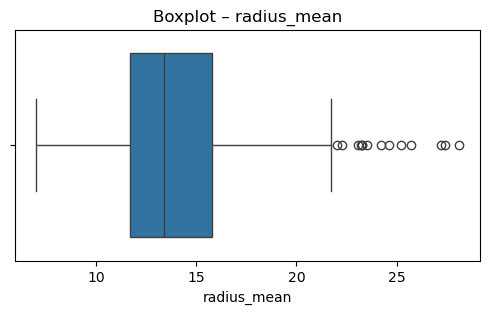

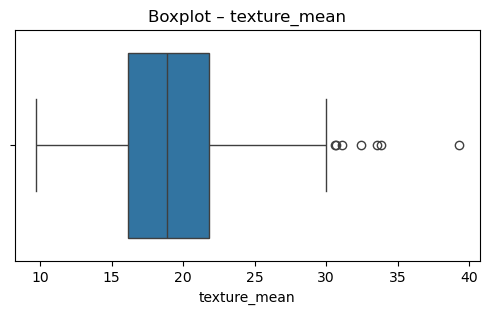

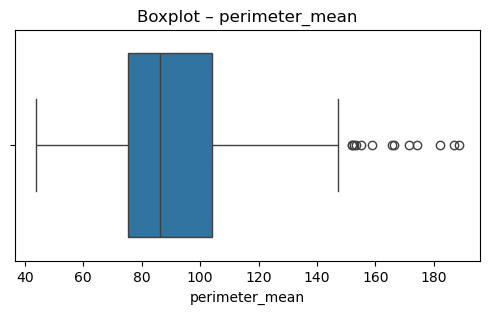

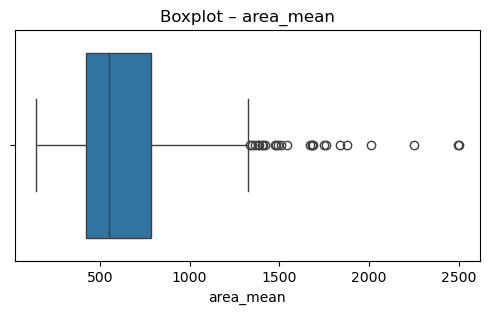

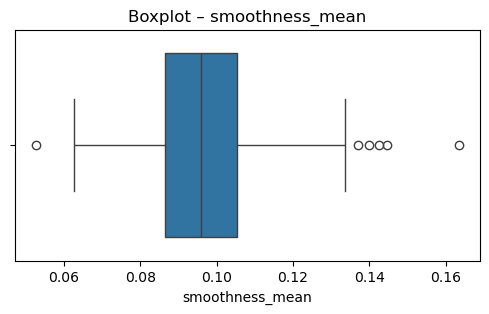

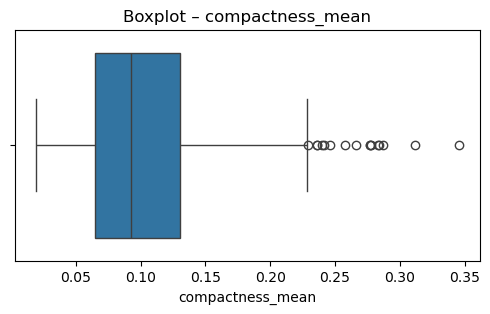

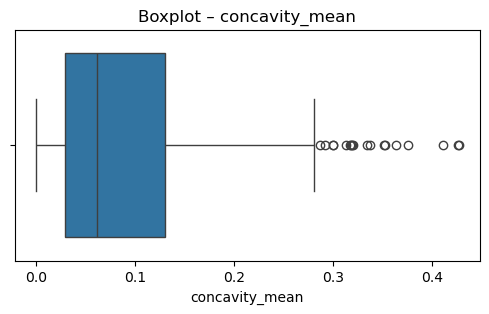

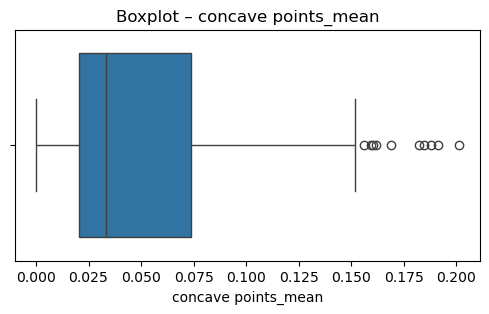

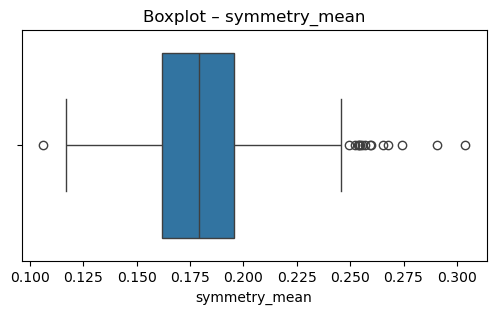

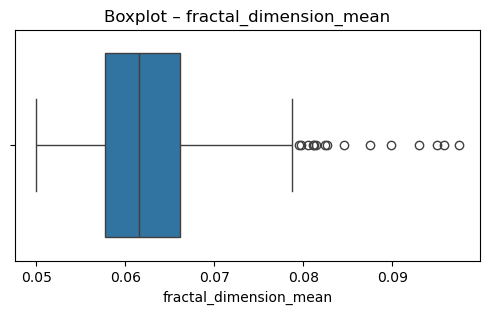

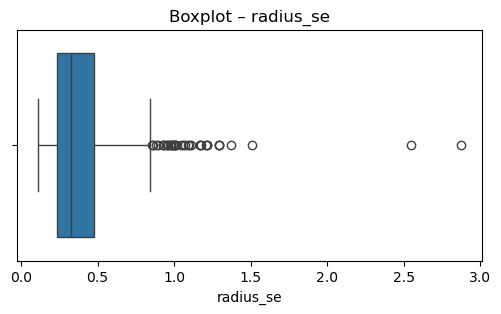

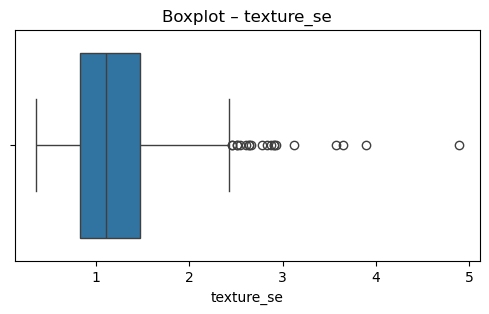

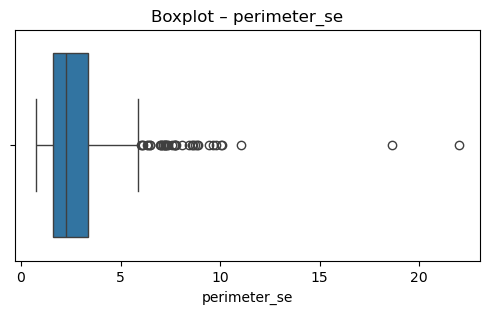

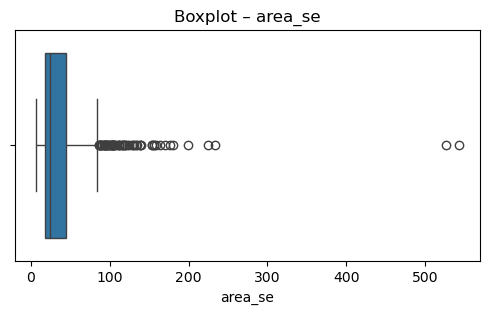

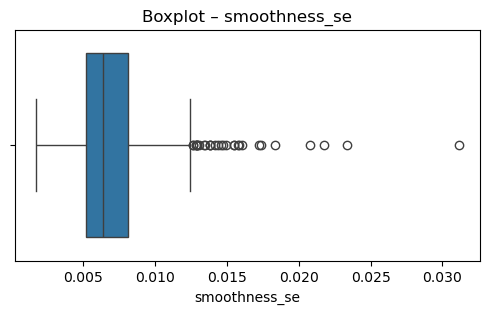

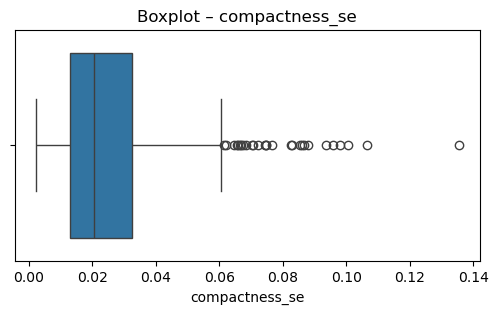

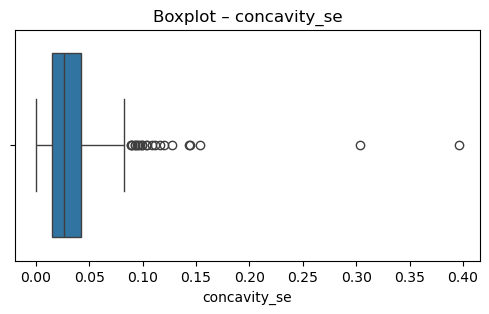

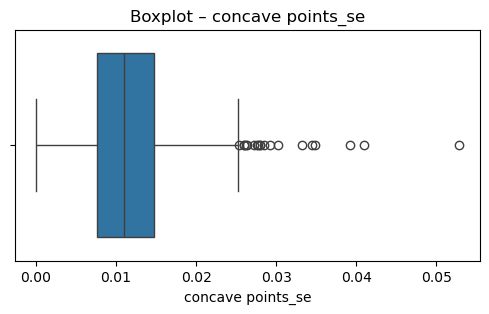

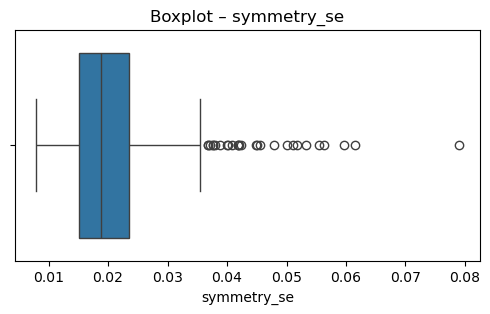

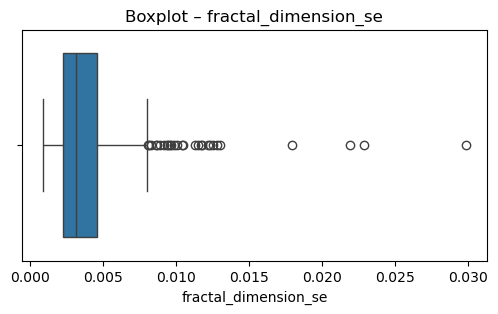

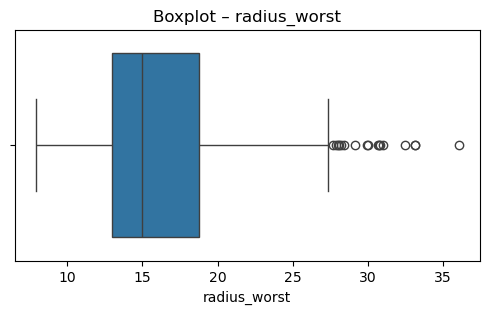

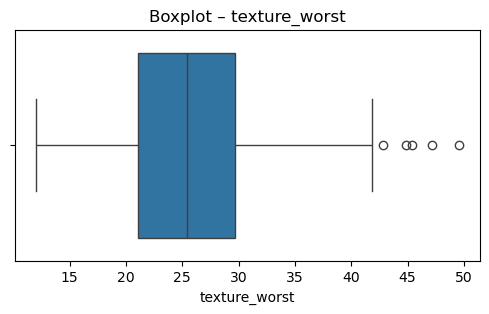

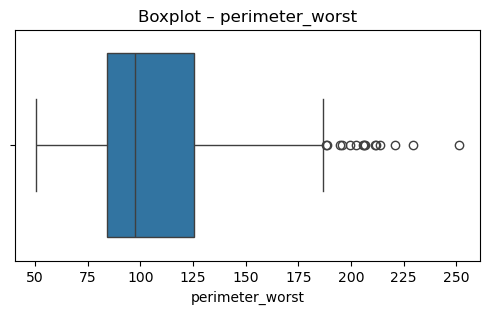

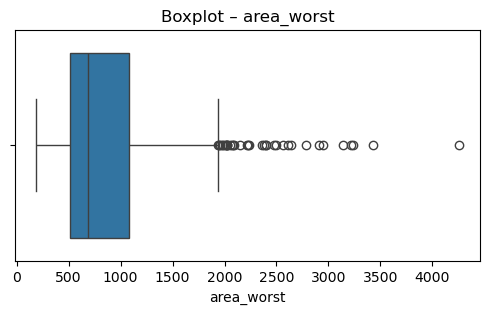

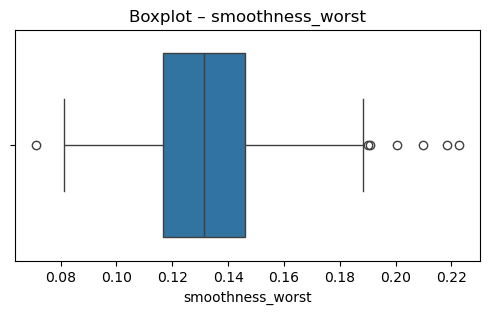

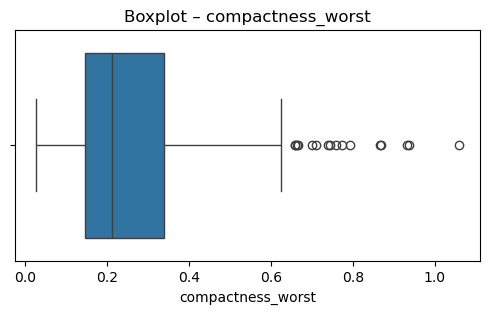

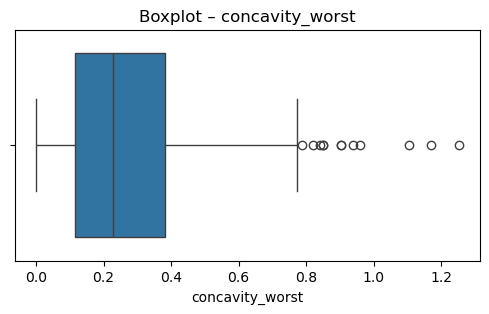

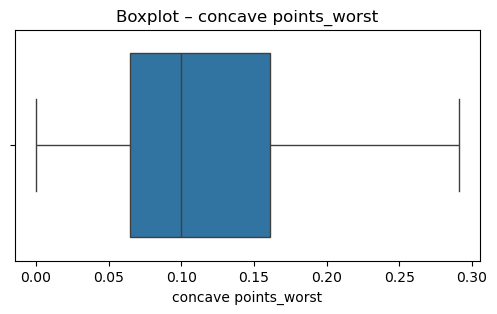

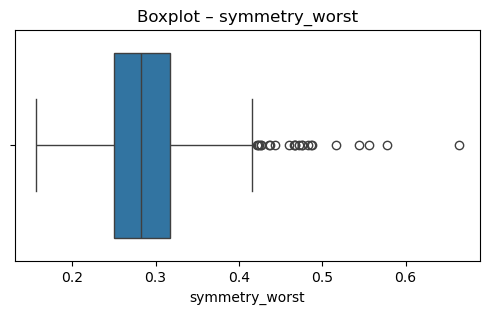

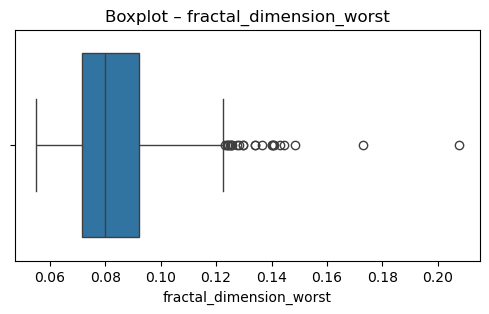

Impossible de tracer un boxplot pour Unnamed: 32 (pas assez de valeurs).
--------------------------------------------------------------------------------

 Dataset 2/14 : df2

🔹 Shape: (398, 9)

🔹 First 5 rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino



🔹 Last 5 rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10



🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None

🔹 Data types:
mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

🔹 Missing values per column:


...


🔹 Duplicate rows count: 0

🔹 Target variable preview:


,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0



🔹 Number of outliers per numeric column:


{'mpg': 1,
 'cylinders': 0,
 'displacement': 0,
 'weight': 0,
 'acceleration': 7,
 'model year': 0,
 'origin': 0}


Distribution des variables numériques :


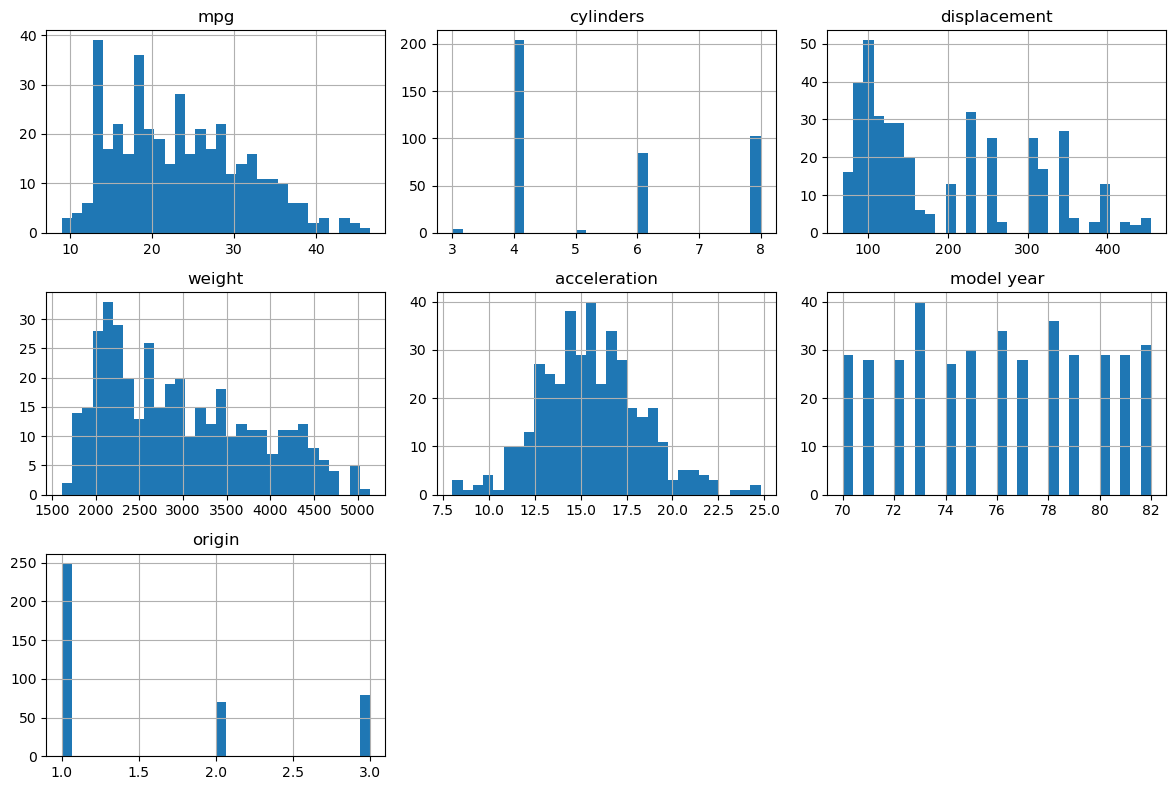

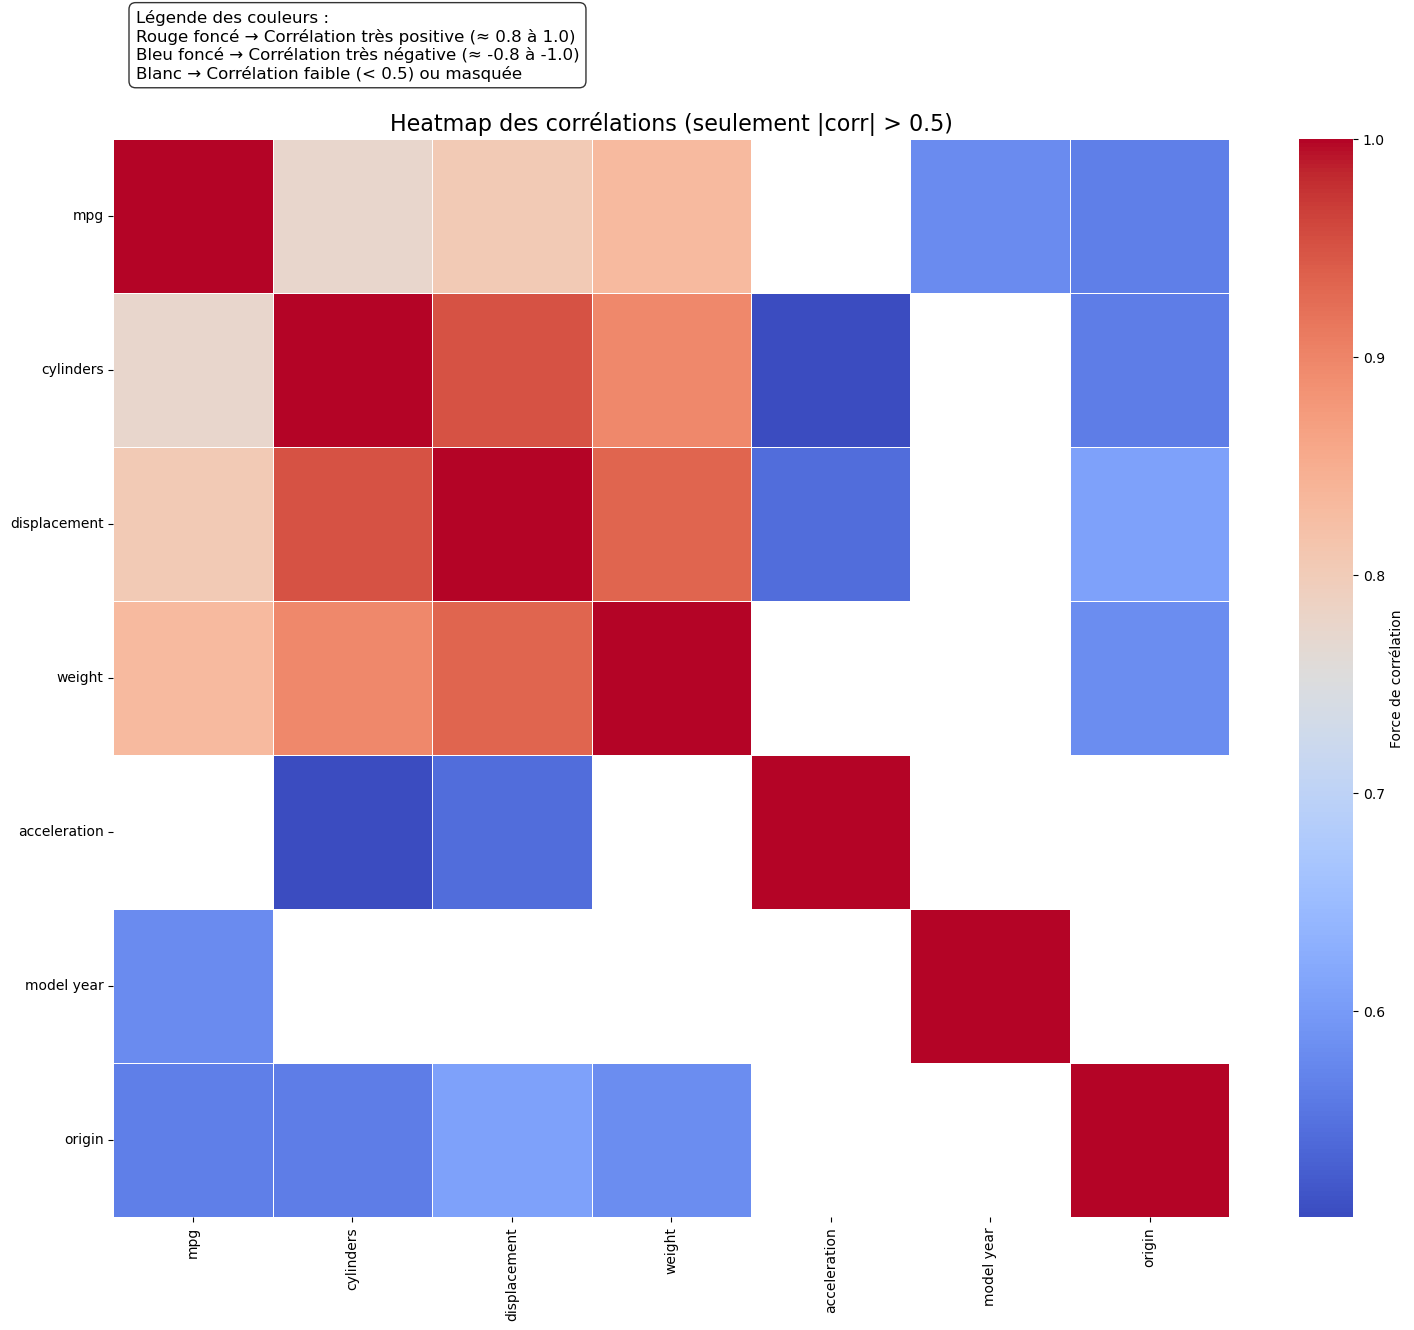

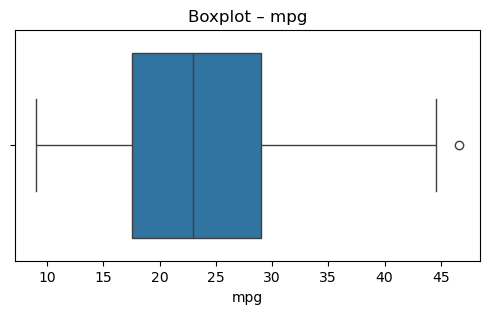

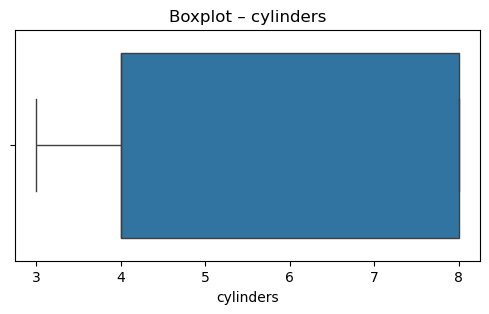

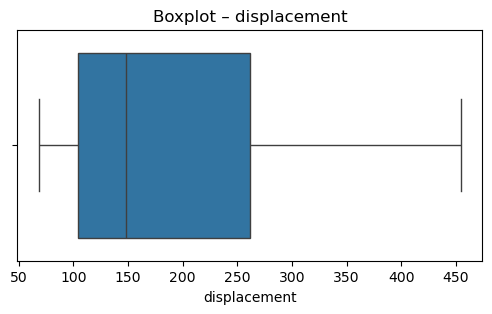

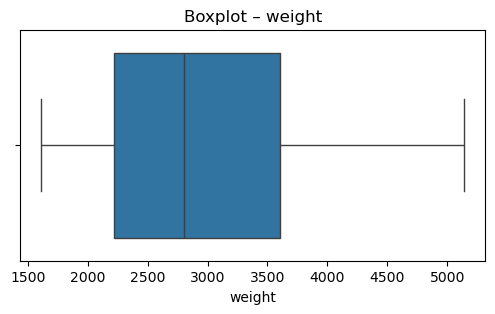

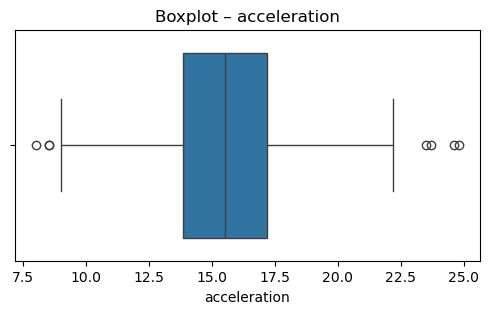

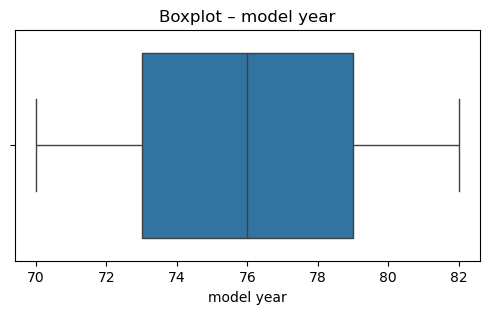

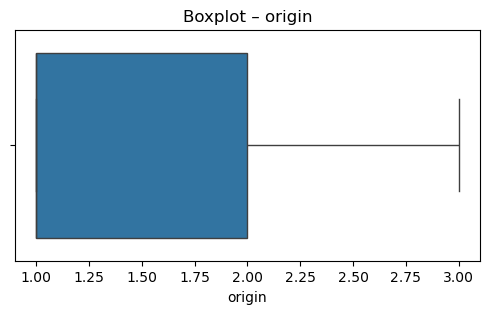

--------------------------------------------------------------------------------

 Dataset 3/14 : df3

🔹 Shape: (1030, 9)

🔹 First 5 rows:


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30



🔹 Last 5 rows:


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77
1029,260.9,100.5,78.3,200.6,8.6,864.5,761.5,28,32.40



🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB
None

🔹 Data types:
cement                           float64
blast_furnace_slag               float64
fly_ash                          float64
water                          

...


🔹 Target variable preview:


,concrete_compressive_strength
0,79.99
1,61.89
2,40.27
3,41.05
4,44.30



🔹 Number of outliers per numeric column:


{'cement': 0,
 'blast_furnace_slag': 2,
 'fly_ash': 0,
 'water': 9,
 'superplasticizer': 10,
 'coarse_aggregate': 0,
 'fine_aggregate ': 5,
 'age': 59,
 'concrete_compressive_strength': 4}


Distribution des variables numériques :


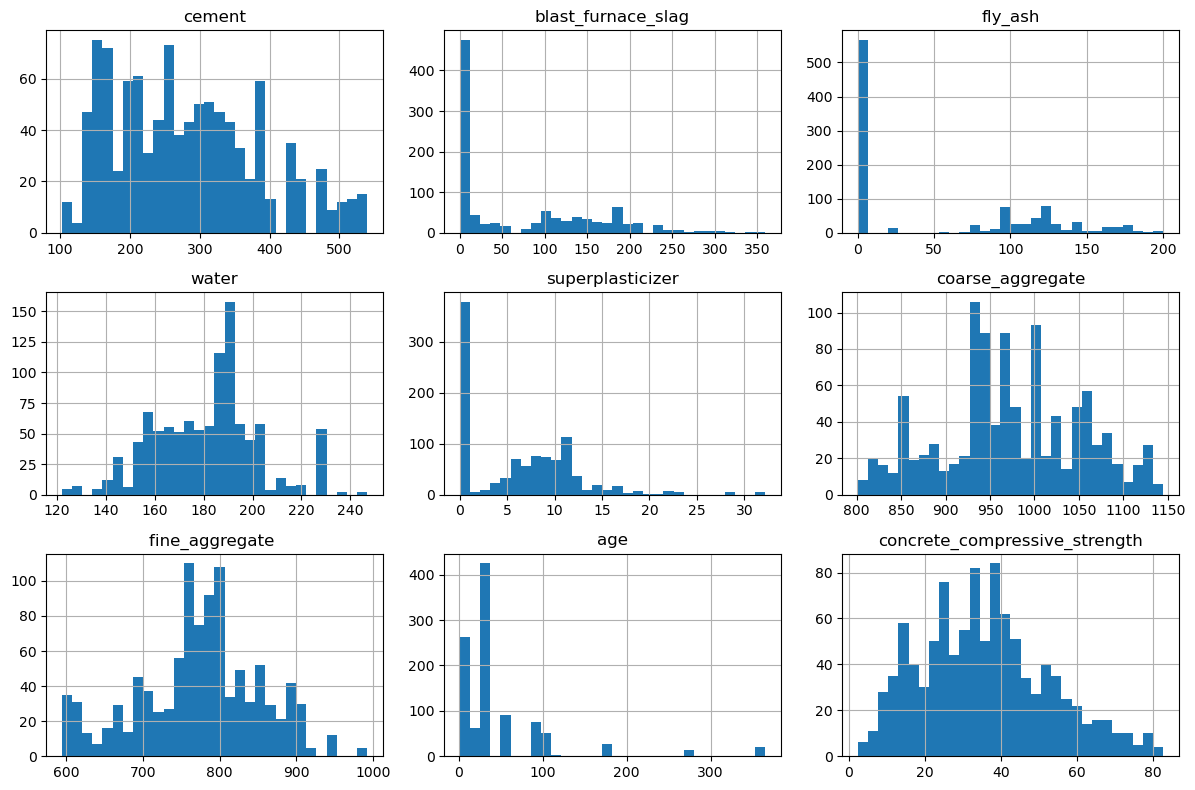

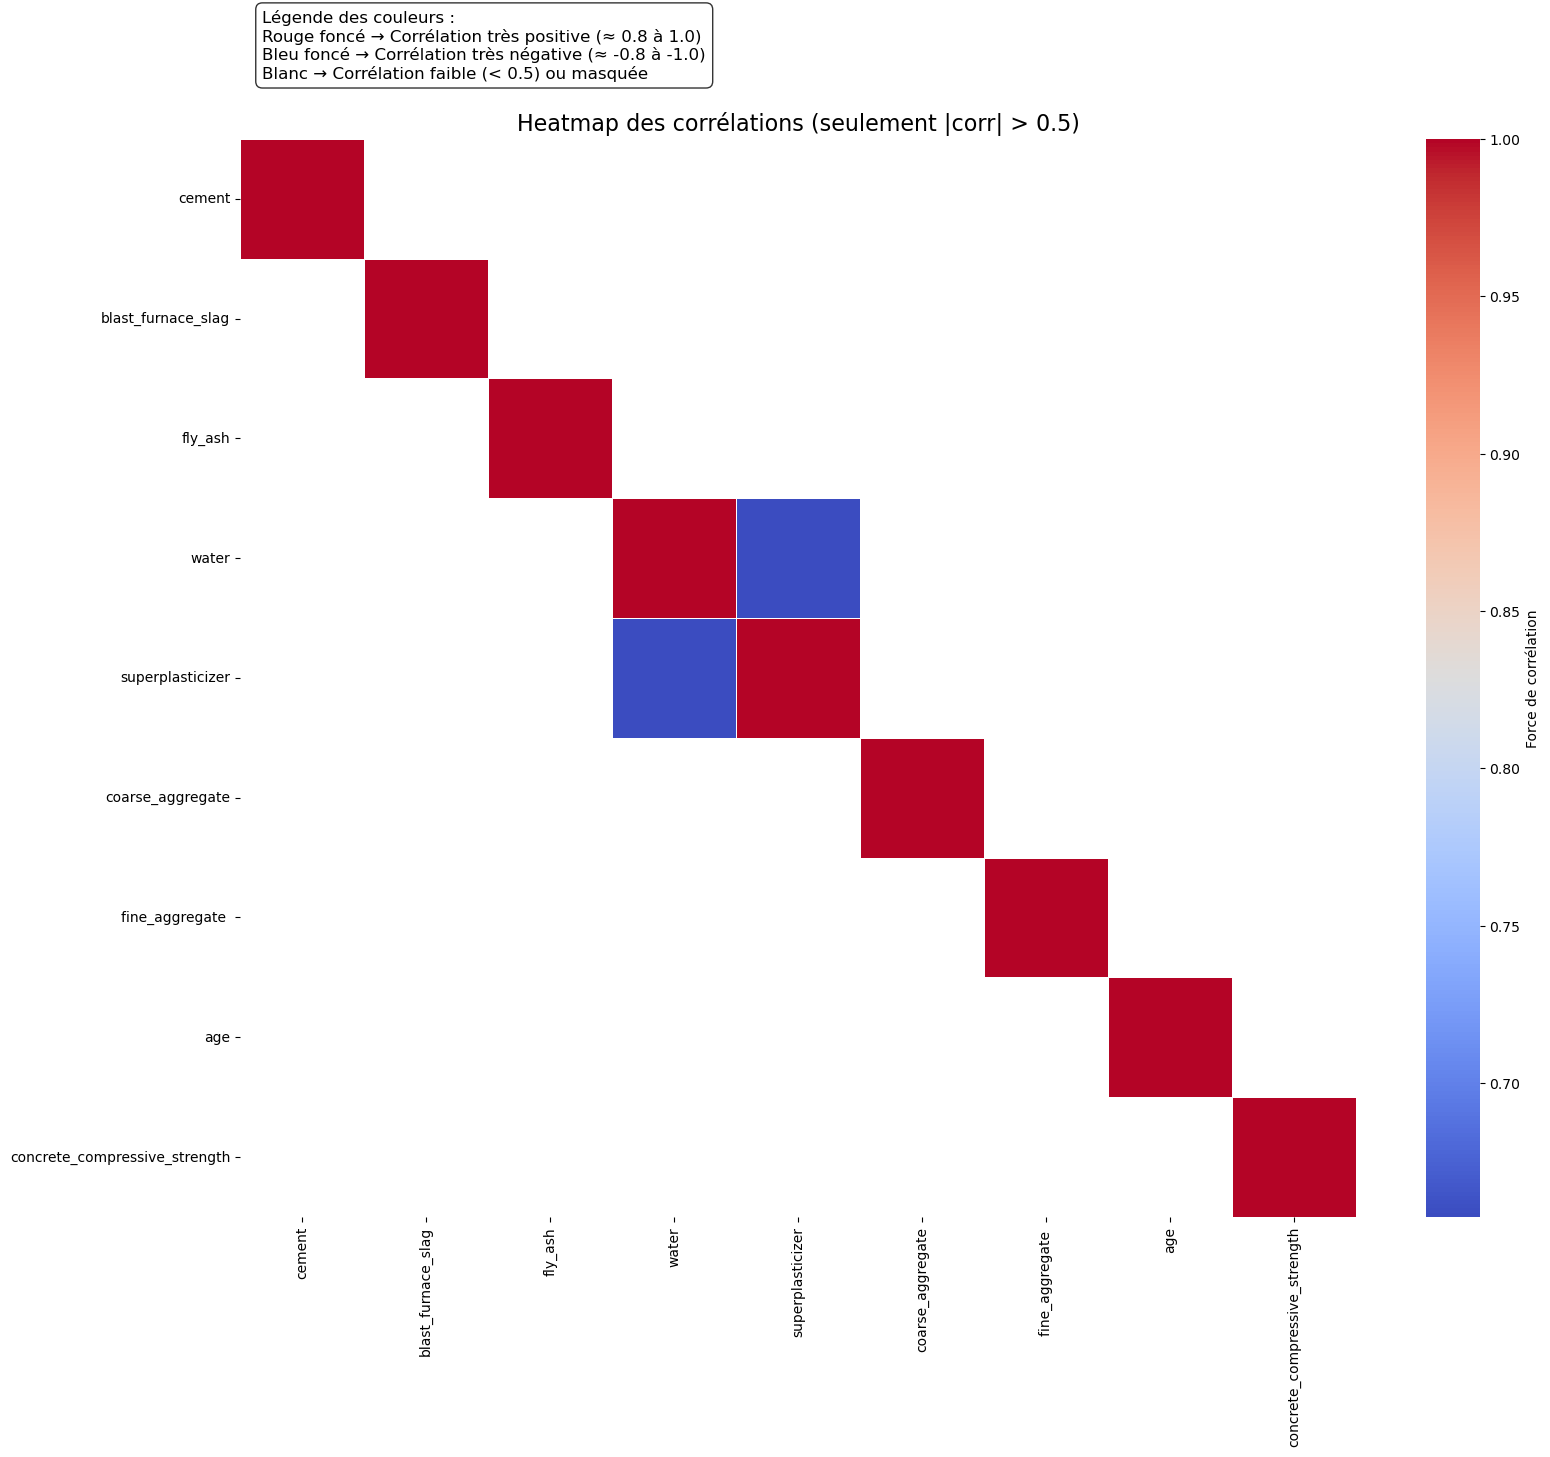

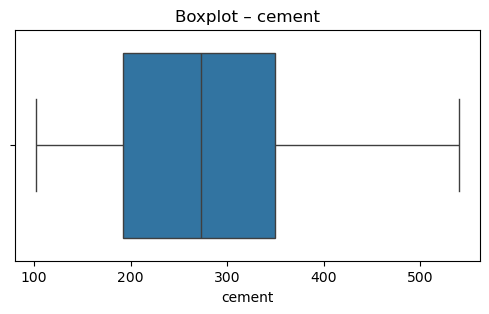

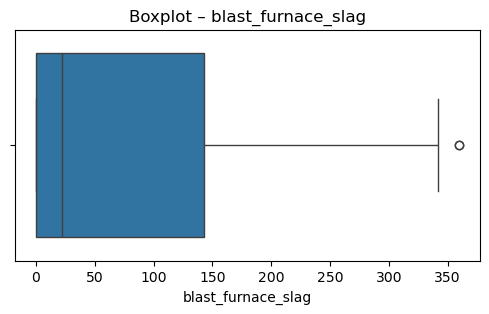

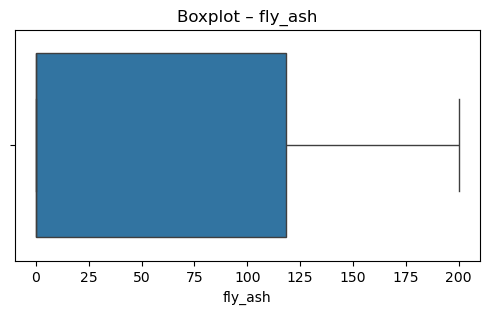

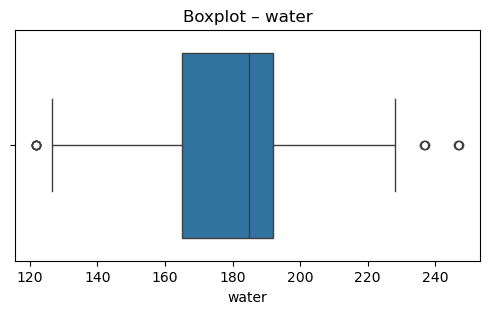

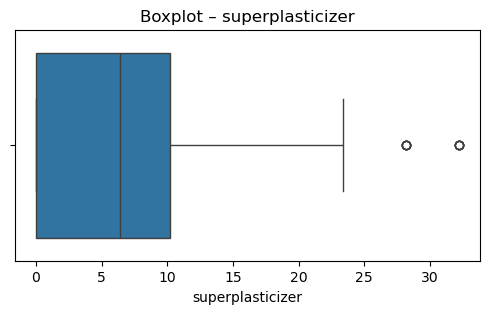

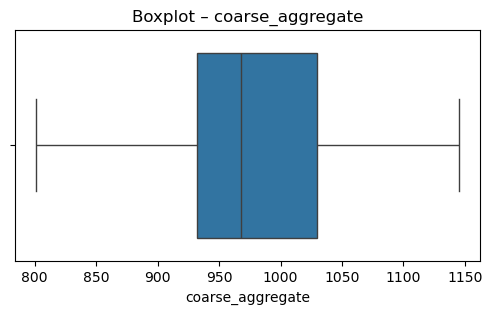

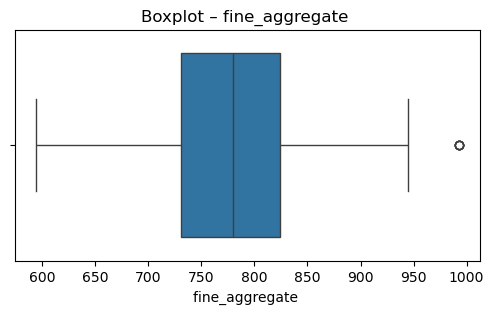

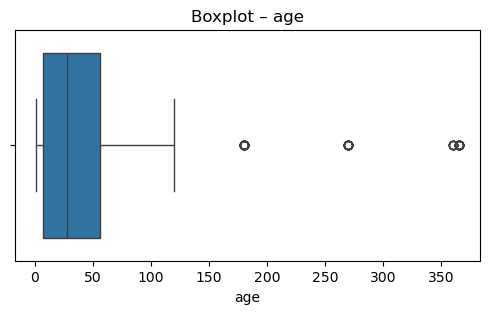

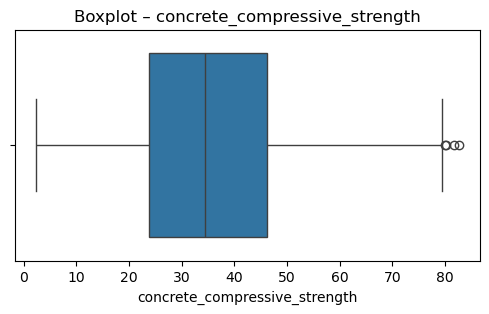

--------------------------------------------------------------------------------

 Dataset 4/14 : df4

🔹 Shape: (506, 14)

🔹 First 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2



🔹 Last 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0.0,0.573,6.030,NaN,2.5050,1,273,21.0,396.90,7.88,11.9



🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None

🔹 Data types:
CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float

...


🔹 Duplicate rows count: 0

🔹 Target variable preview:


,MEDV
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2



🔹 Number of outliers per numeric column:


{'CRIM': 65,
 'ZN': 63,
 'INDUS': 0,
 'CHAS': 34,
 'NOX': 0,
 'RM': 30,
 'AGE': 0,
 'DIS': 5,
 'RAD': 0,
 'TAX': 0,
 'PTRATIO': 15,
 'B': 77,
 'LSTAT': 7,
 'MEDV': 40}


Distribution des variables numériques :


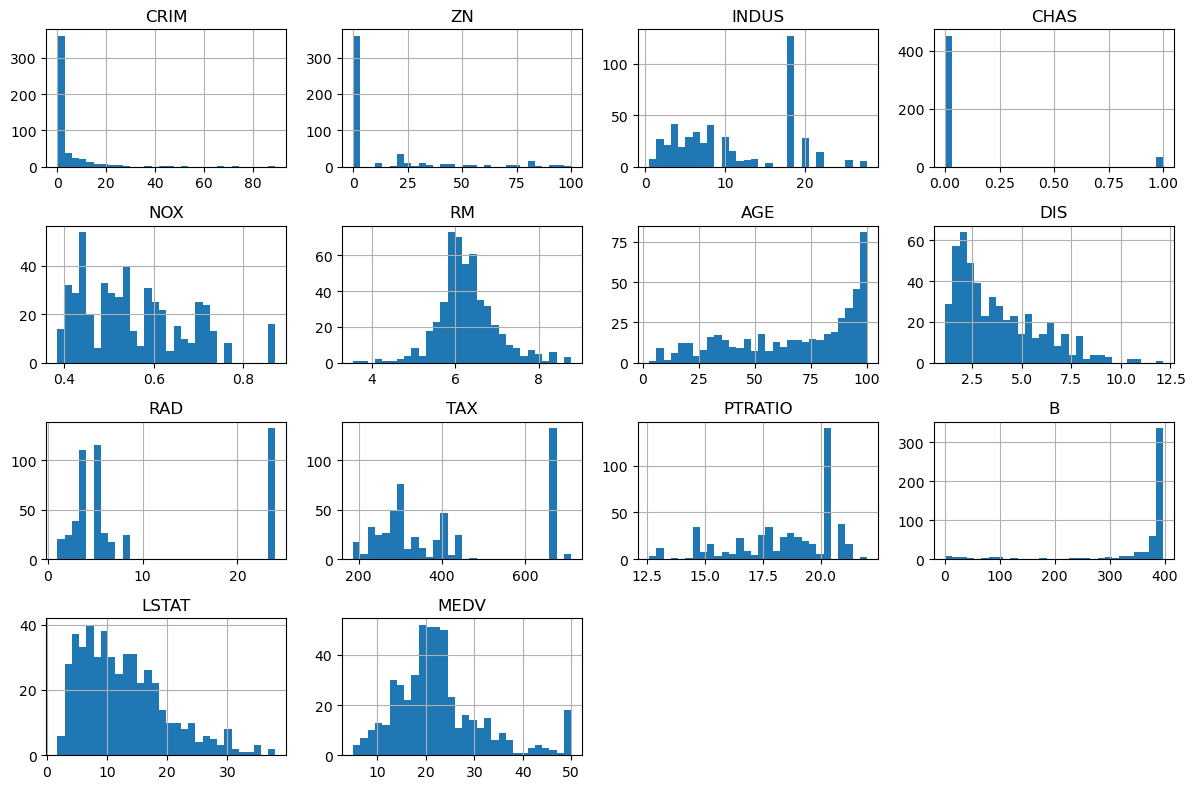

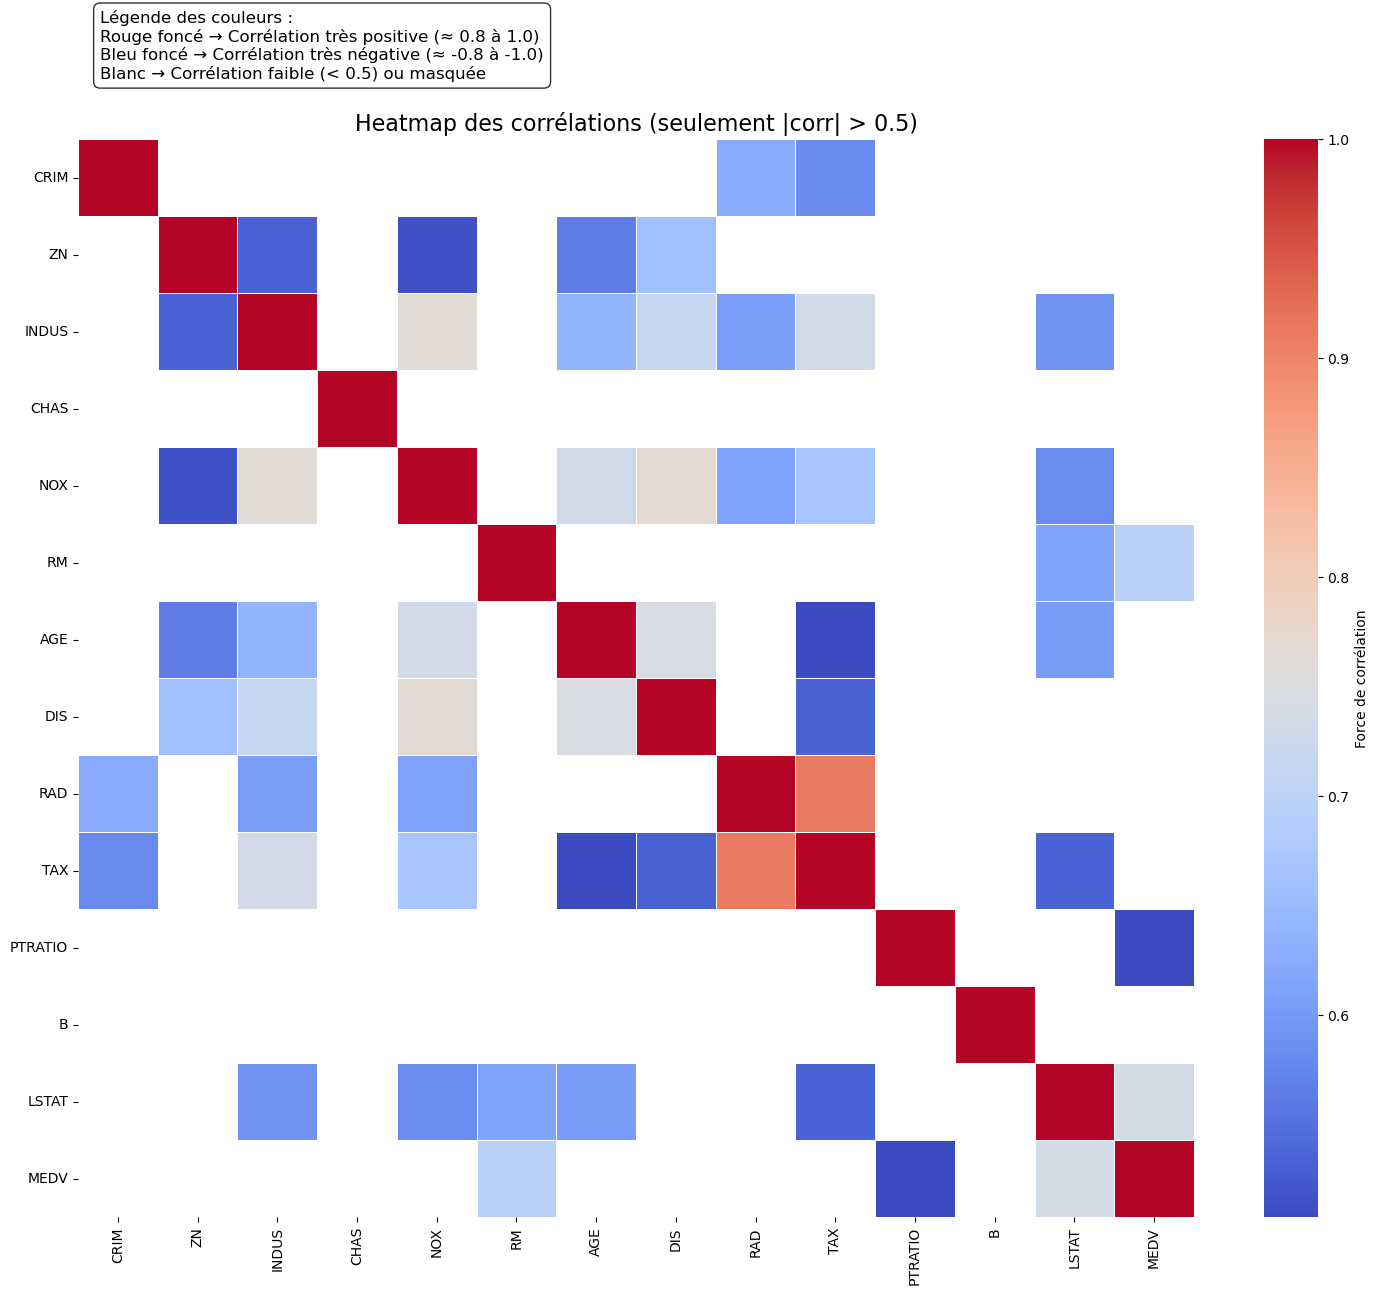

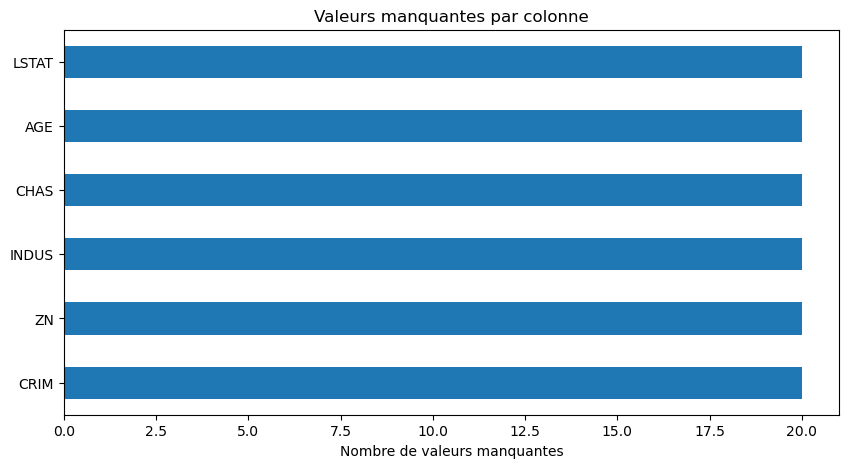

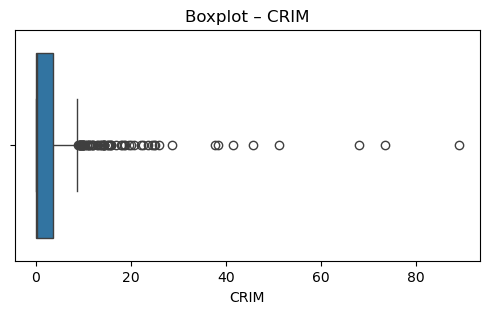

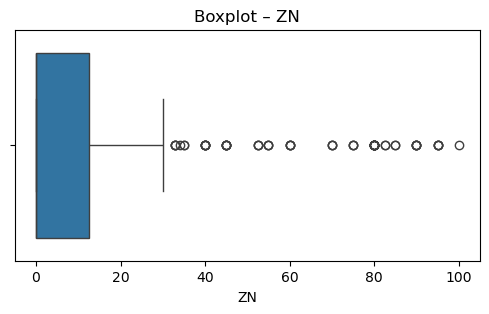

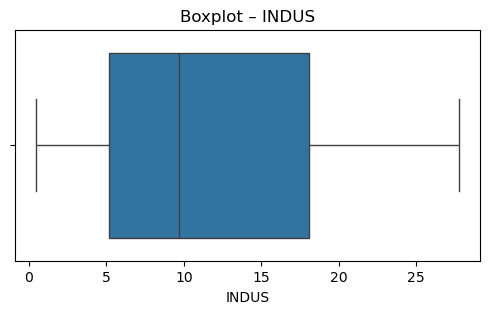

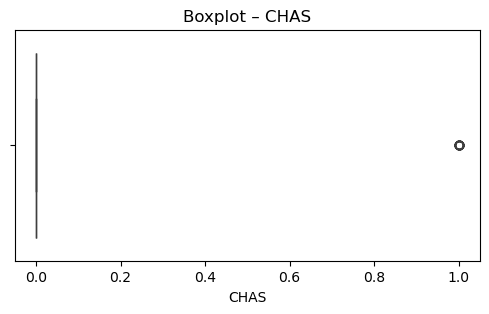

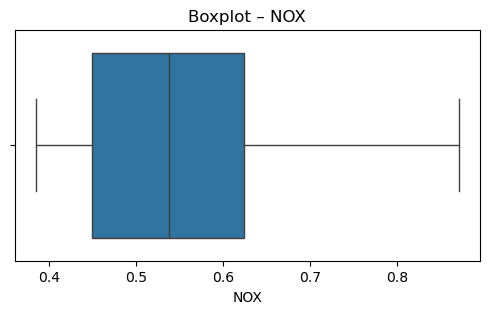

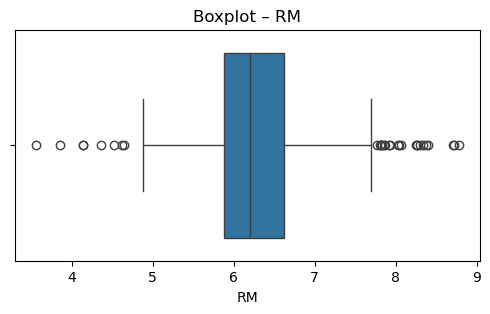

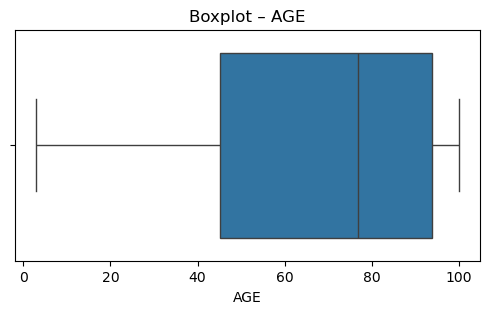

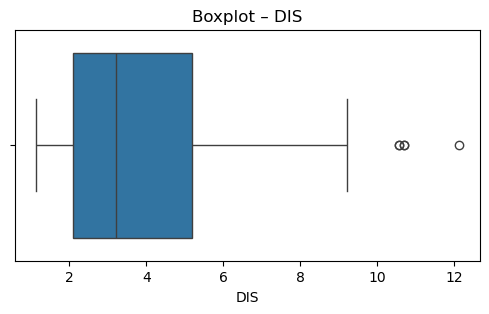

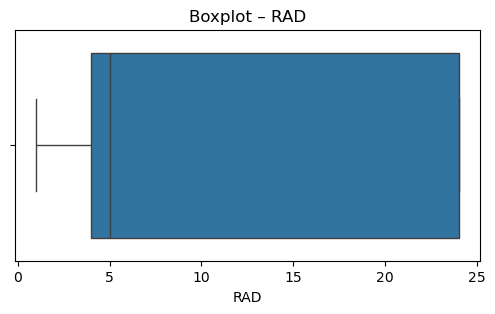

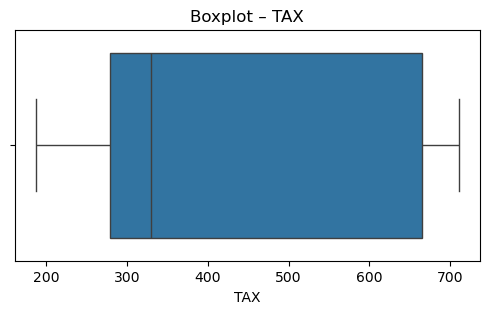

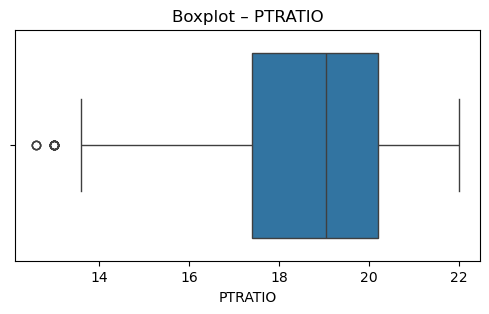

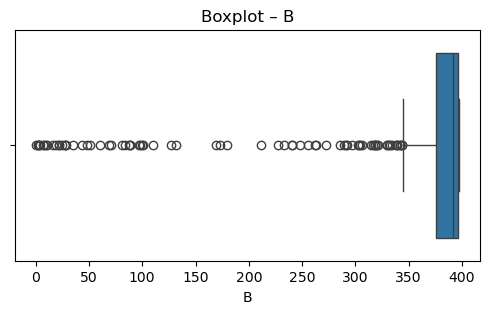

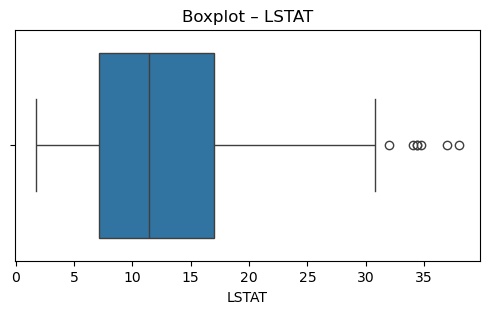

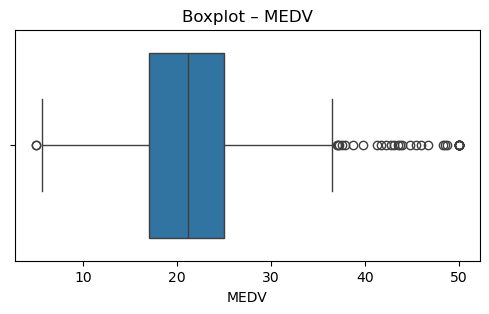

--------------------------------------------------------------------------------

 Dataset 5/14 : df5

🔹 Shape: (112, 14)

🔹 First 5 rows:


,obs,maxO3,T9,T12,T15,Ne9,Ne12,Ne15,Vx9,Vx12,Vx15,maxO3v,vent,pluie
0,601,87,"15,6","18,5","18,4",4,4,8,"0,6946","-1,7101","-0,6946",84,Nord,Sec
1,602,82,17,"18,4","17,7",5,5,7,"-4,3301",-4,-3,87,Nord,Sec
2,603,92,"15,3","17,6","19,5",2,5,4,"2,9544","1,8794","0,5209",82,Est,Sec
3,604,114,"16,2","19,7","22,5",1,1,0,"0,9848","0,3473","-0,1736",92,Nord,Sec
4,605,94,"17,4","20,5","20,4",8,8,7,"-0,5","-2,9544","-4,3301",114,Ouest,Sec



🔹 Last 5 rows:


,obs,maxO3,T9,T12,T15,Ne9,Ne12,Ne15,Vx9,Vx12,Vx15,maxO3v,vent,pluie
107,925,84,"13,3","17,7","17,8",3,5,6,0,-1,"-1,2856",76,Sud,Sec
108,927,77,"16,2","20,8","22,1",6,5,5,"-0,6946",-2,"-1,3681",71,Sud,Pluie
109,928,99,"16,9",23,"22,6",6,4,7,"1,5","0,8682","0,8682",77,Sud,Sec
110,929,83,"16,9","19,8","22,1",6,5,3,-4,"-3,7588",-4,99,Ouest,Pluie
111,930,70,"15,7","18,6","20,7",7,7,7,0,"-1,0419",-4,83,Sud,Sec



🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0    obs    112 non-null    int64 
 1   maxO3   112 non-null    int64 
 2   T9      112 non-null    object
 3   T12     112 non-null    object
 4   T15     112 non-null    object
 5   Ne9     112 non-null    int64 
 6   Ne12    112 non-null    int64 
 7   Ne15    112 non-null    int64 
 8   Vx9     112 non-null    object
 9   Vx12    112 non-null    object
 10  Vx15    112 non-null    object
 11  maxO3v  112 non-null    int64 
 12  vent    112 non-null    object
 13  pluie   112 non-null    object
dtypes: int64(6), object(8)
memory usage: 12.4+ KB
None

🔹 Data types:
 obs       int64
maxO3      int64
T9        object
T12       object
T15       object
Ne9        int64
Ne12       int64
Ne15       int64
Vx9       object
Vx12      object
Vx15      object
maxO3v     int64
vent      object
pluie     object
d

...


🔹 Percentage of missing values per column:


Series([], dtype: float64)


🔹 Duplicate rows count: 0

🔹 Target variable preview:

🔹 Number of outliers per numeric column:


{' obs': 0, 'maxO3': 4, 'Ne9': 0, 'Ne12': 0, 'Ne15': 0, 'maxO3v': 4}


Distribution des variables numériques :


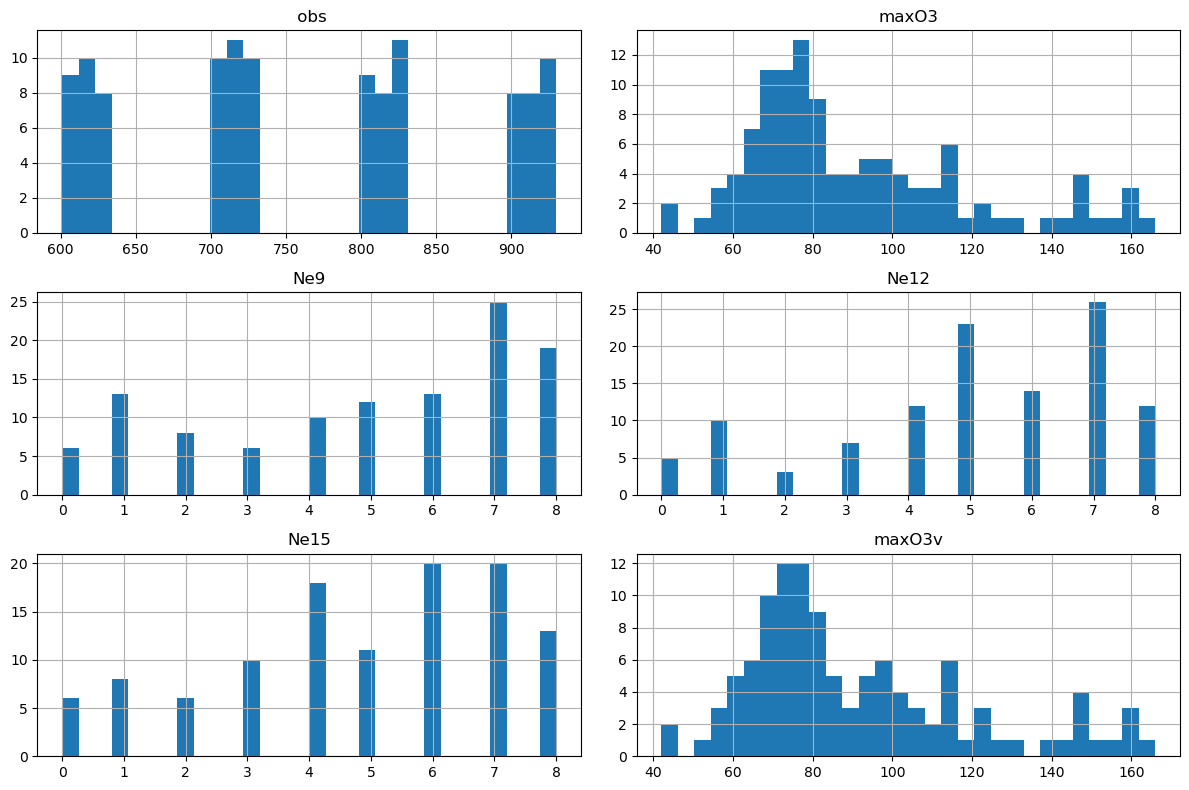

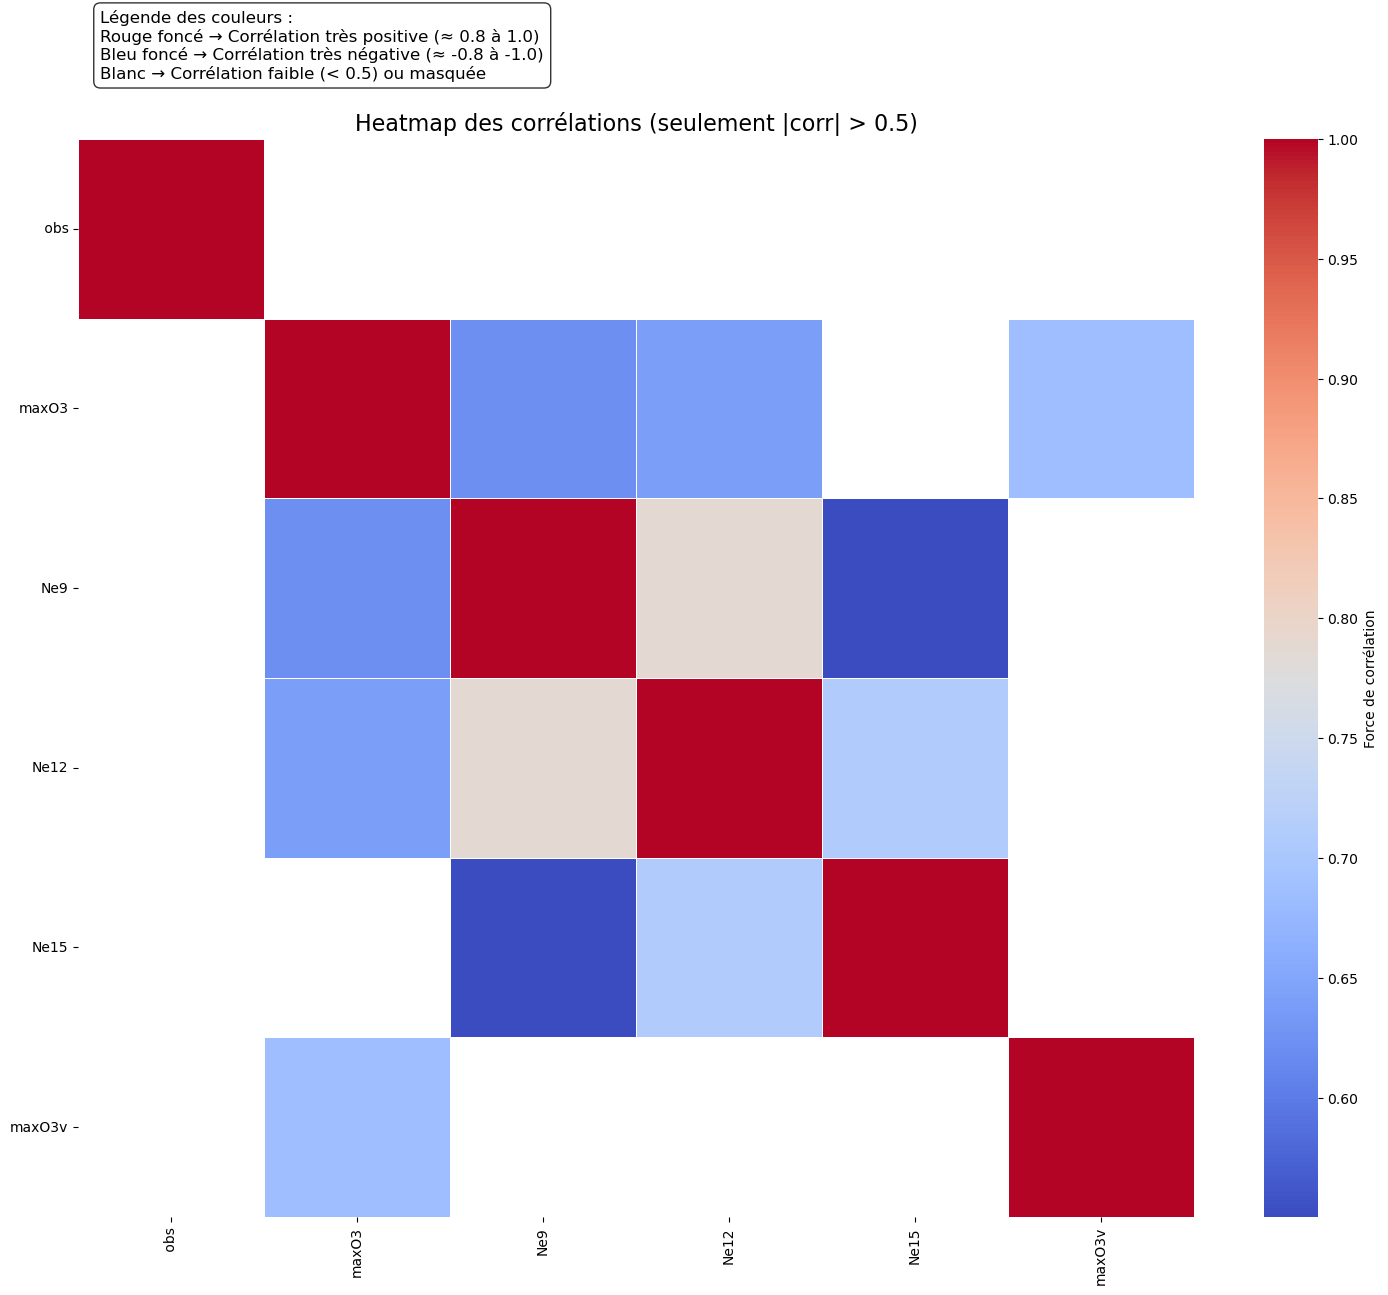

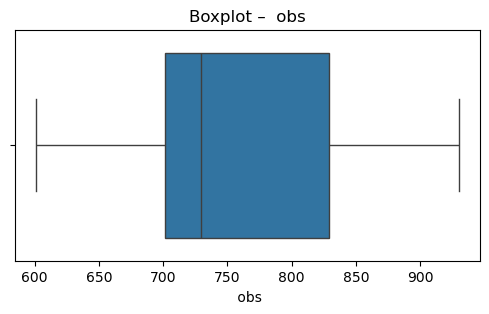

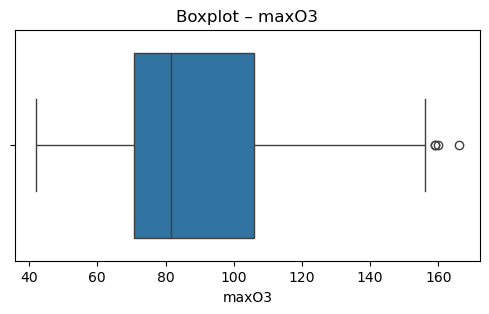

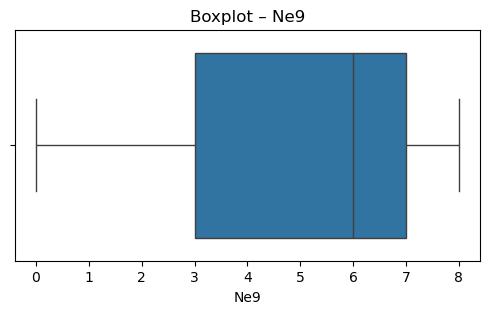

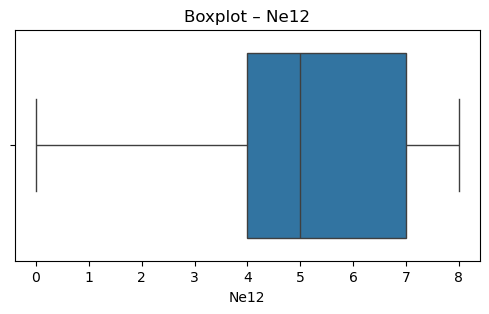

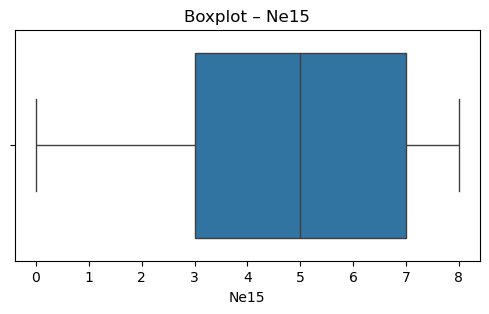

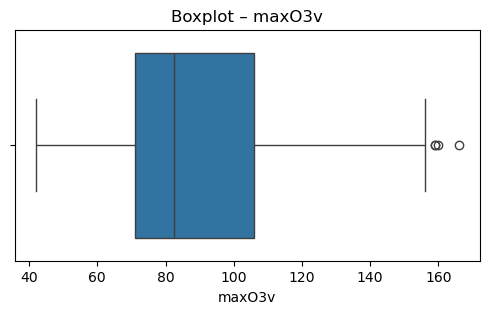

--------------------------------------------------------------------------------

 Dataset 6/14 : df6

🔹 Shape: (195, 24)

🔹 First 5 rows:


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335



🔹 Last 5 rows:


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306
194,phon_R01_S50_6,214.289,260.277,77.973,0.00567,0.00003,0.00295,0.00317,0.00885,0.01884,...,0.03078,0.04398,21.209,0,0.462803,0.664357,-5.724056,0.190667,2.555477,0.148569



🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    f

...


🔹 Duplicate rows count: 0

🔹 Target variable preview:


,status
0,0.284654
1,0.368674
2,0.332634
3,0.368975
4,0.410335



🔹 Number of outliers per numeric column:


{'MDVP:Fo(Hz)': 0,
 'MDVP:Fhi(Hz)': 11,
 'MDVP:Flo(Hz)': 9,
 'MDVP:Jitter(%)': 14,
 'MDVP:Jitter(Abs)': 7,
 'MDVP:RAP': 14,
 'MDVP:PPQ': 15,
 'Jitter:DDP': 14,
 'MDVP:Shimmer': 8,
 'MDVP:Shimmer(dB)': 10,
 'Shimmer:APQ3': 6,
 'Shimmer:APQ5': 13,
 'MDVP:APQ': 12,
 'Shimmer:DDA': 6,
 'NHR': 19,
 'HNR': 3,
 'RPDE': 48,
 'DFA': 0,
 'spread1': 0,
 'spread2': 4,
 'D2': 2,
 'PPE': 1,
 'status': 5}


Distribution des variables numériques :


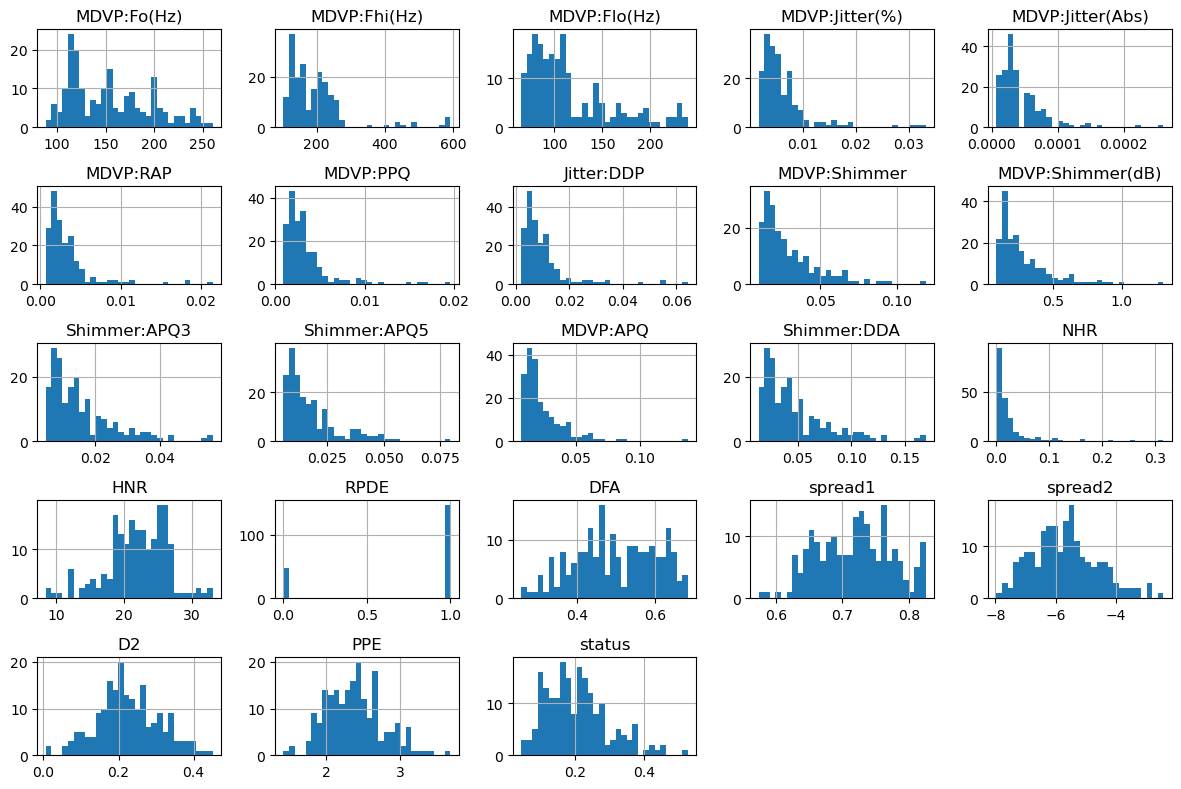

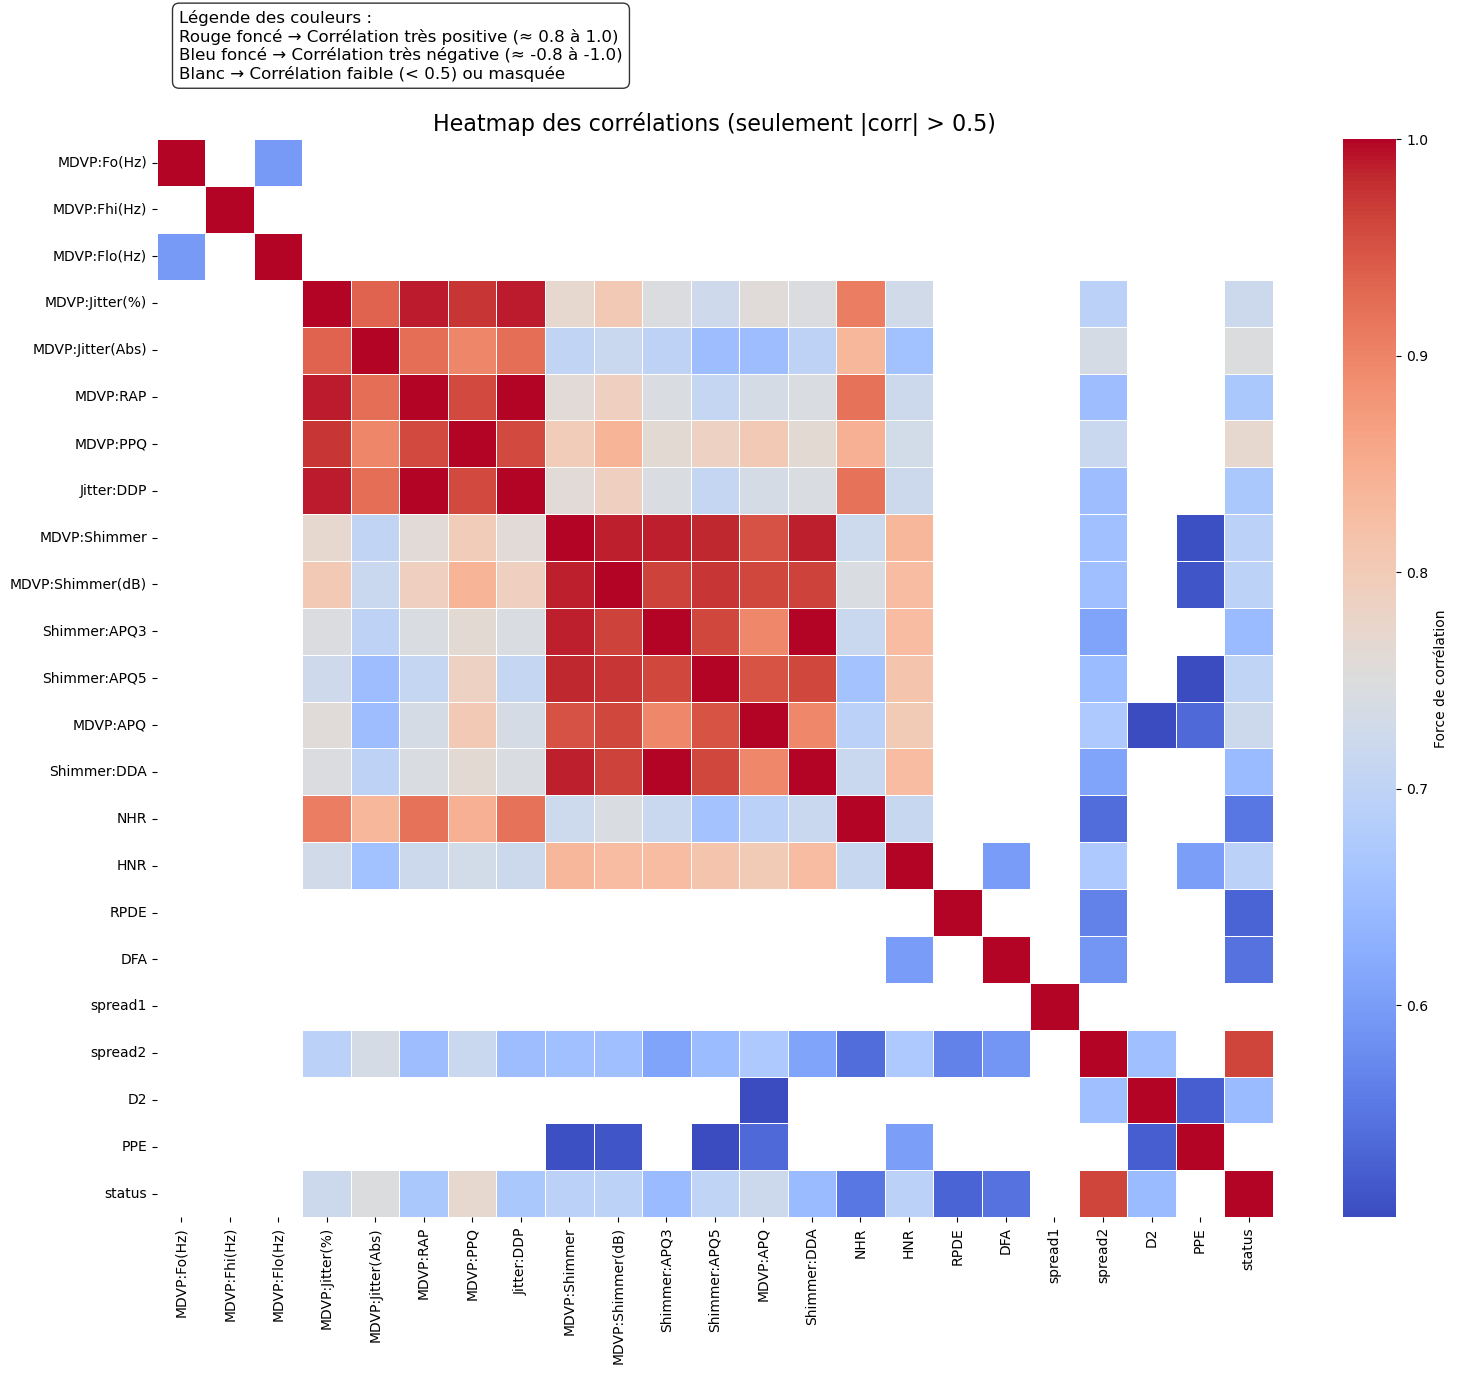

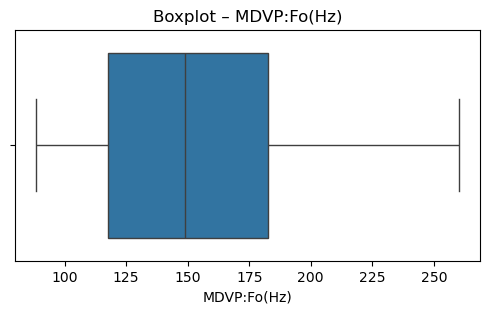

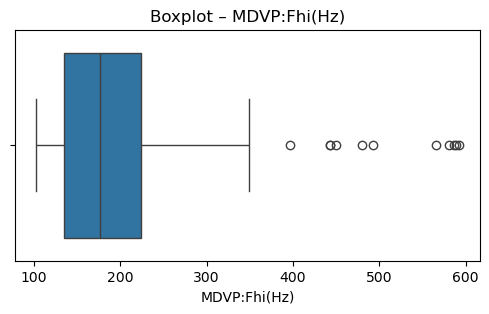

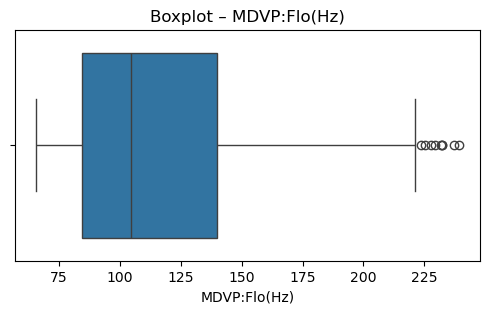

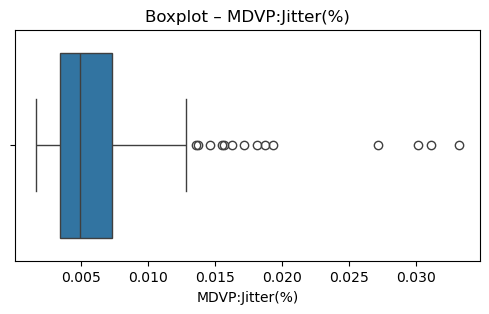

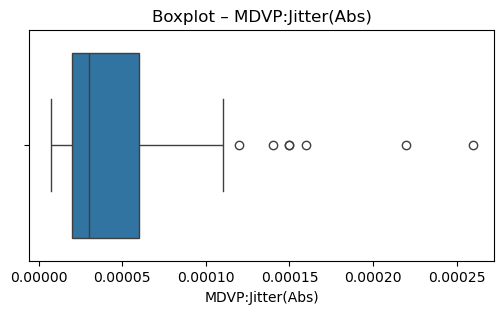

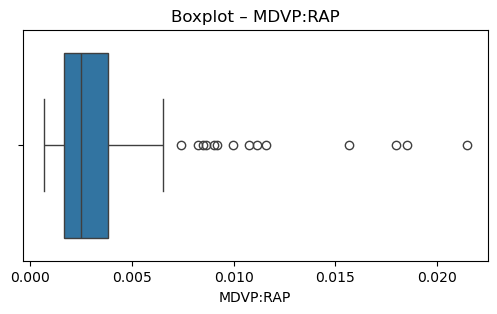

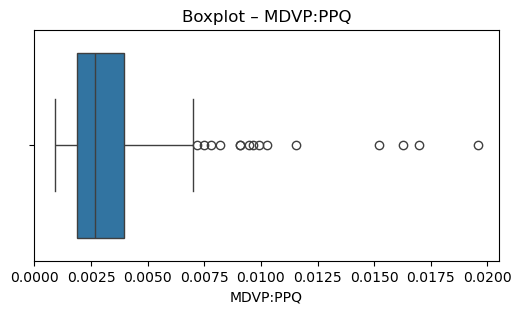

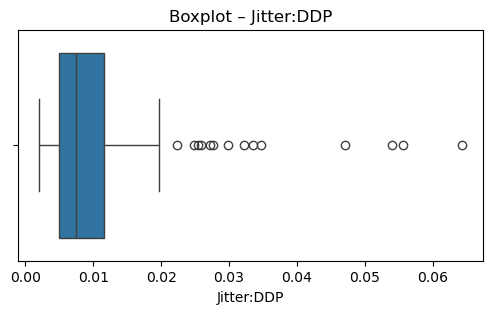

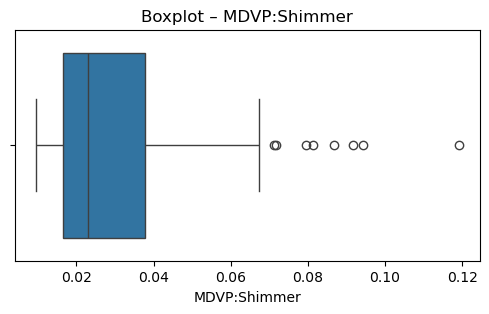

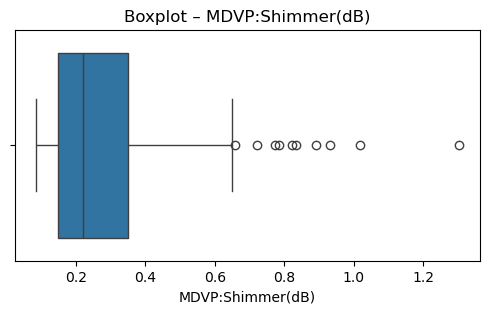

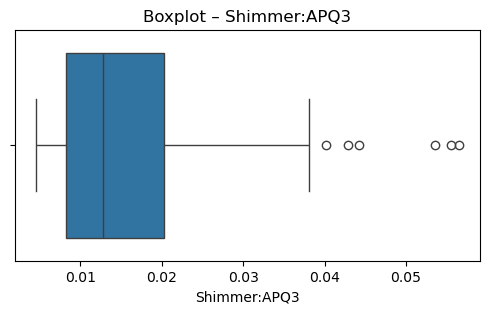

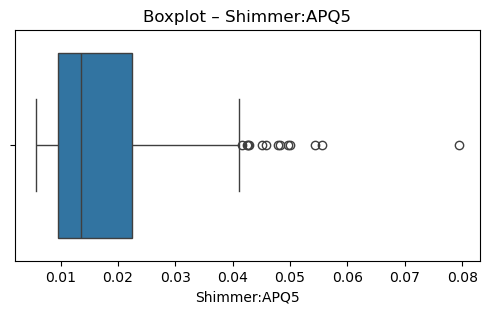

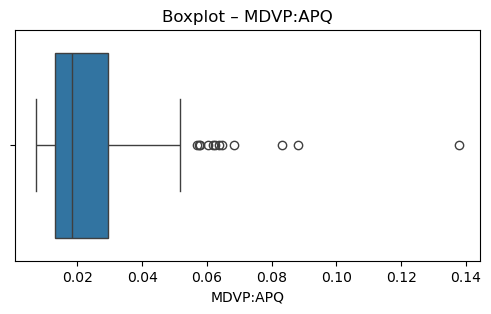

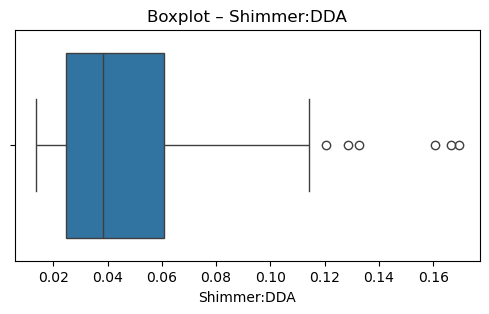

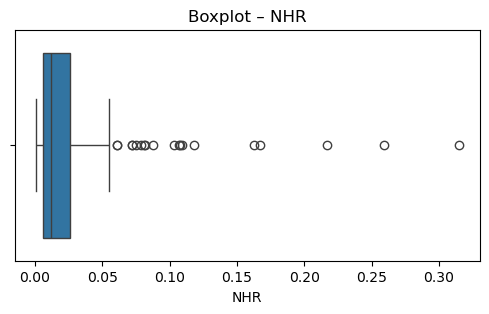

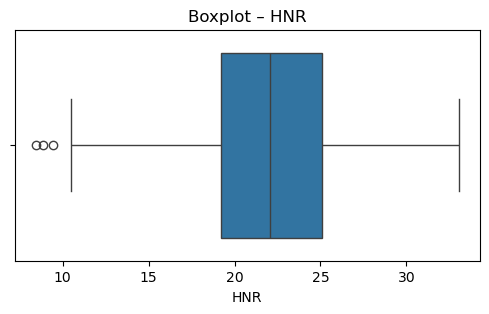

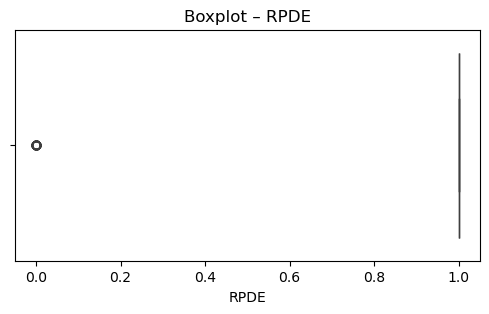

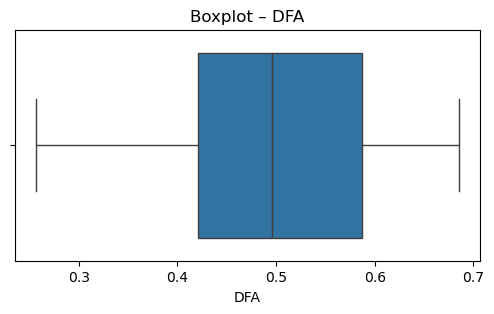

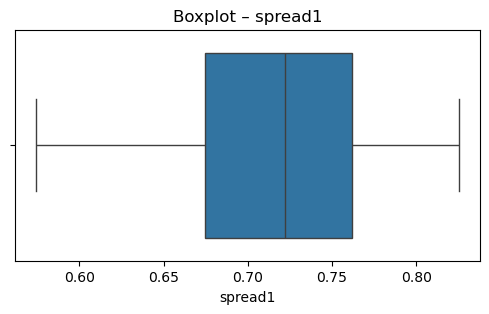

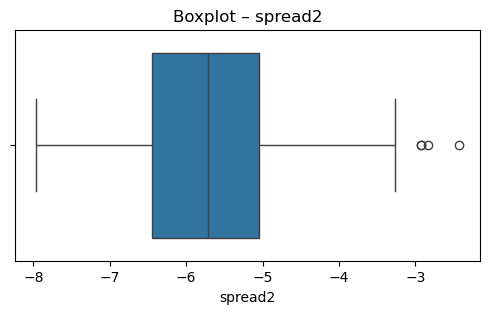

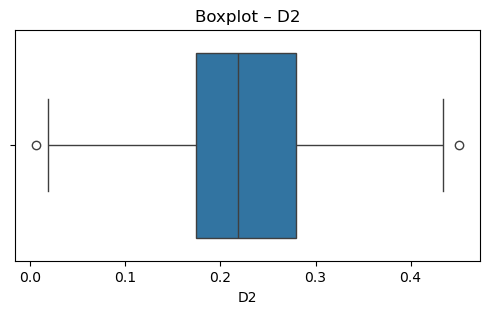

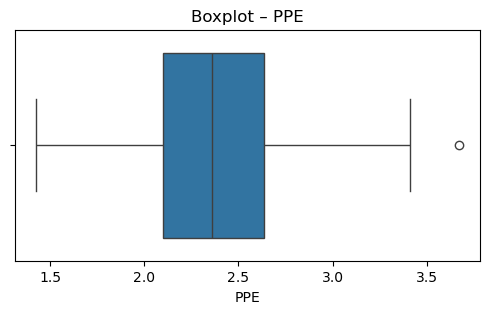

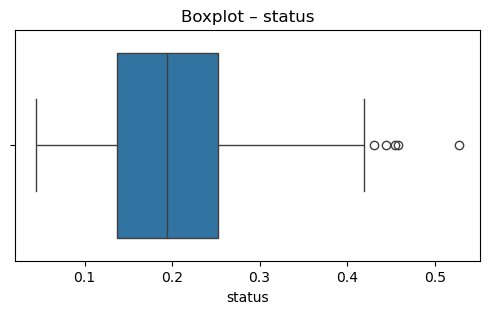

--------------------------------------------------------------------------------

 Dataset 7/14 : df7

🔹 Shape: (240, 48)

🔹 First 5 rows:


,ID,Recording,Status,Gender,Jitter_rel,Jitter_abs,Jitter_RAP,Jitter_PPQ,Shim_loc,Shim_dB,...,Delta3,Delta4,Delta5,Delta6,Delta7,Delta8,Delta9,Delta10,Delta11,Delta12
0,CONT-01,1,0,1,0.25546,0.000015,0.001467,0.001673,0.030256,0.26313,...,1.407701,1.417218,1.380352,1.420670,1.451240,1.440295,1.403678,1.405495,1.416705,1.354610
1,CONT-01,2,0,1,0.36964,0.000022,0.001932,0.002245,0.023146,0.20217,...,1.331232,1.227338,1.213377,1.352739,1.354242,1.365692,1.322870,1.314549,1.318999,1.323508
2,CONT-01,3,0,1,0.23514,0.000013,0.001353,0.001546,0.019338,0.16710,...,1.412304,1.324674,1.276088,1.429634,1.455996,1.368882,1.438053,1.388910,1.305469,1.305402
3,CONT-02,1,0,0,0.29320,0.000017,0.001105,0.001444,0.024716,0.20892,...,1.501200,1.534170,1.323993,1.496442,1.472926,1.643177,1.551286,1.638346,1.604008,1.621456
4,CONT-02,2,0,0,0.23075,0.000015,0.001073,0.001404,0.013119,0.11607,...,1.508468,1.334511,1.610694,1.685021,1.417614,1.574895,1.640088,1.533666,1.297536,1.382023



🔹 Last 5 rows:


,ID,Recording,Status,Gender,Jitter_rel,Jitter_abs,Jitter_RAP,Jitter_PPQ,Shim_loc,Shim_dB,...,Delta3,Delta4,Delta5,Delta6,Delta7,Delta8,Delta9,Delta10,Delta11,Delta12
235,PARK-39,2,1,0,0.57585,0.000037,0.003701,0.005149,0.016868,0.14928,...,1.116409,1.104511,1.099866,1.080320,1.154057,1.117423,1.167076,1.132436,1.107824,1.109144
236,PARK-39,3,1,0,0.23322,0.000015,0.001270,0.001497,0.017923,0.16720,...,1.107477,1.083859,1.101819,1.114161,1.090095,1.140705,1.126667,1.158444,1.096073,1.141835
237,PARK-40,1,1,0,0.26862,0.000022,0.001354,0.001615,0.028040,0.24182,...,1.335189,1.385580,1.281551,1.367171,1.319055,1.367095,1.343193,1.374330,1.383364,1.456409
238,PARK-40,2,1,0,0.45376,0.000037,0.002724,0.002258,0.064605,0.58002,...,1.327629,1.349928,1.461323,1.350599,1.346363,1.415338,1.361937,1.331923,1.423062,1.307353
239,PARK-40,3,1,0,0.34706,0.000028,0.001746,0.002060,0.019914,0.17087,...,1.440003,1.327946,1.531764,1.471198,1.445675,1.415942,1.304214,1.395653,1.315691,1.422534



🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 48 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          240 non-null    object 
 1   Recording   240 non-null    int64  
 2   Status      240 non-null    int64  
 3   Gender      240 non-null    int64  
 4   Jitter_rel  240 non-null    float64
 5   Jitter_abs  240 non-null    float64
 6   Jitter_RAP  240 non-null    float64
 7   Jitter_PPQ  240 non-null    float64
 8   Shim_loc    240 non-null    float64
 9   Shim_dB     240 non-null    float64
 10  Shim_APQ3   240 non-null    float64
 11  Shim_APQ5   240 non-null    float64
 12  Shi_APQ11   240 non-null    float64
 13  HNR05       240 non-null    float64
 14  HNR15       240 non-null    float64
 15  HNR25       240 non-null    float64
 16  HNR35       240 non-null    float64
 17  HNR38       240 non-null    float64
 18  RPDE        240 non-null    float64
 19  DFA         240 non-

...


🔹 Duplicate rows count: 0

🔹 Target variable preview:


,Status
0,0
1,0
2,0
3,0
4,0



🔹 Number of outliers per numeric column:


{'Recording': 0,
 'Status': 0,
 'Gender': 0,
 'Jitter_rel': 11,
 'Jitter_abs': 10,
 'Jitter_RAP': 15,
 'Jitter_PPQ': 13,
 'Shim_loc': 11,
 'Shim_dB': 11,
 'Shim_APQ3': 12,
 'Shim_APQ5': 12,
 'Shi_APQ11': 12,
 'HNR05': 2,
 'HNR15': 1,
 'HNR25': 1,
 'HNR35': 1,
 'HNR38': 1,
 'RPDE': 2,
 'DFA': 0,
 'PPE': 0,
 'GNE': 0,
 'MFCC0': 2,
 'MFCC1': 0,
 'MFCC2': 2,
 'MFCC3': 2,
 'MFCC4': 1,
 'MFCC5': 4,
 'MFCC6': 3,
 'MFCC7': 2,
 'MFCC8': 3,
 'MFCC9': 1,
 'MFCC10': 8,
 'MFCC11': 1,
 'MFCC12': 2,
 'Delta0': 4,
 'Delta1': 3,
 'Delta2': 4,
 'Delta3': 1,
 'Delta4': 3,
 'Delta5': 1,
 'Delta6': 1,
 'Delta7': 0,
 'Delta8': 0,
 'Delta9': 1,
 'Delta10': 2,
 'Delta11': 2,
 'Delta12': 3}


Distribution des variables numériques :


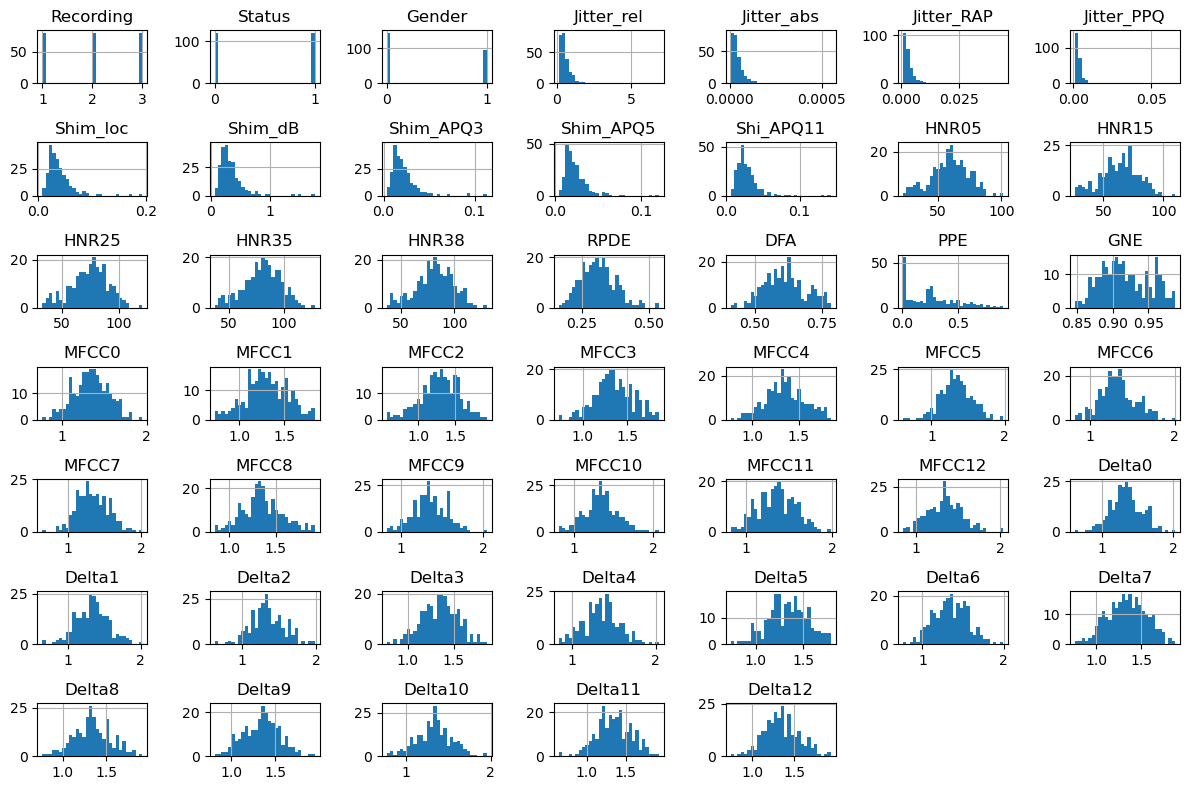

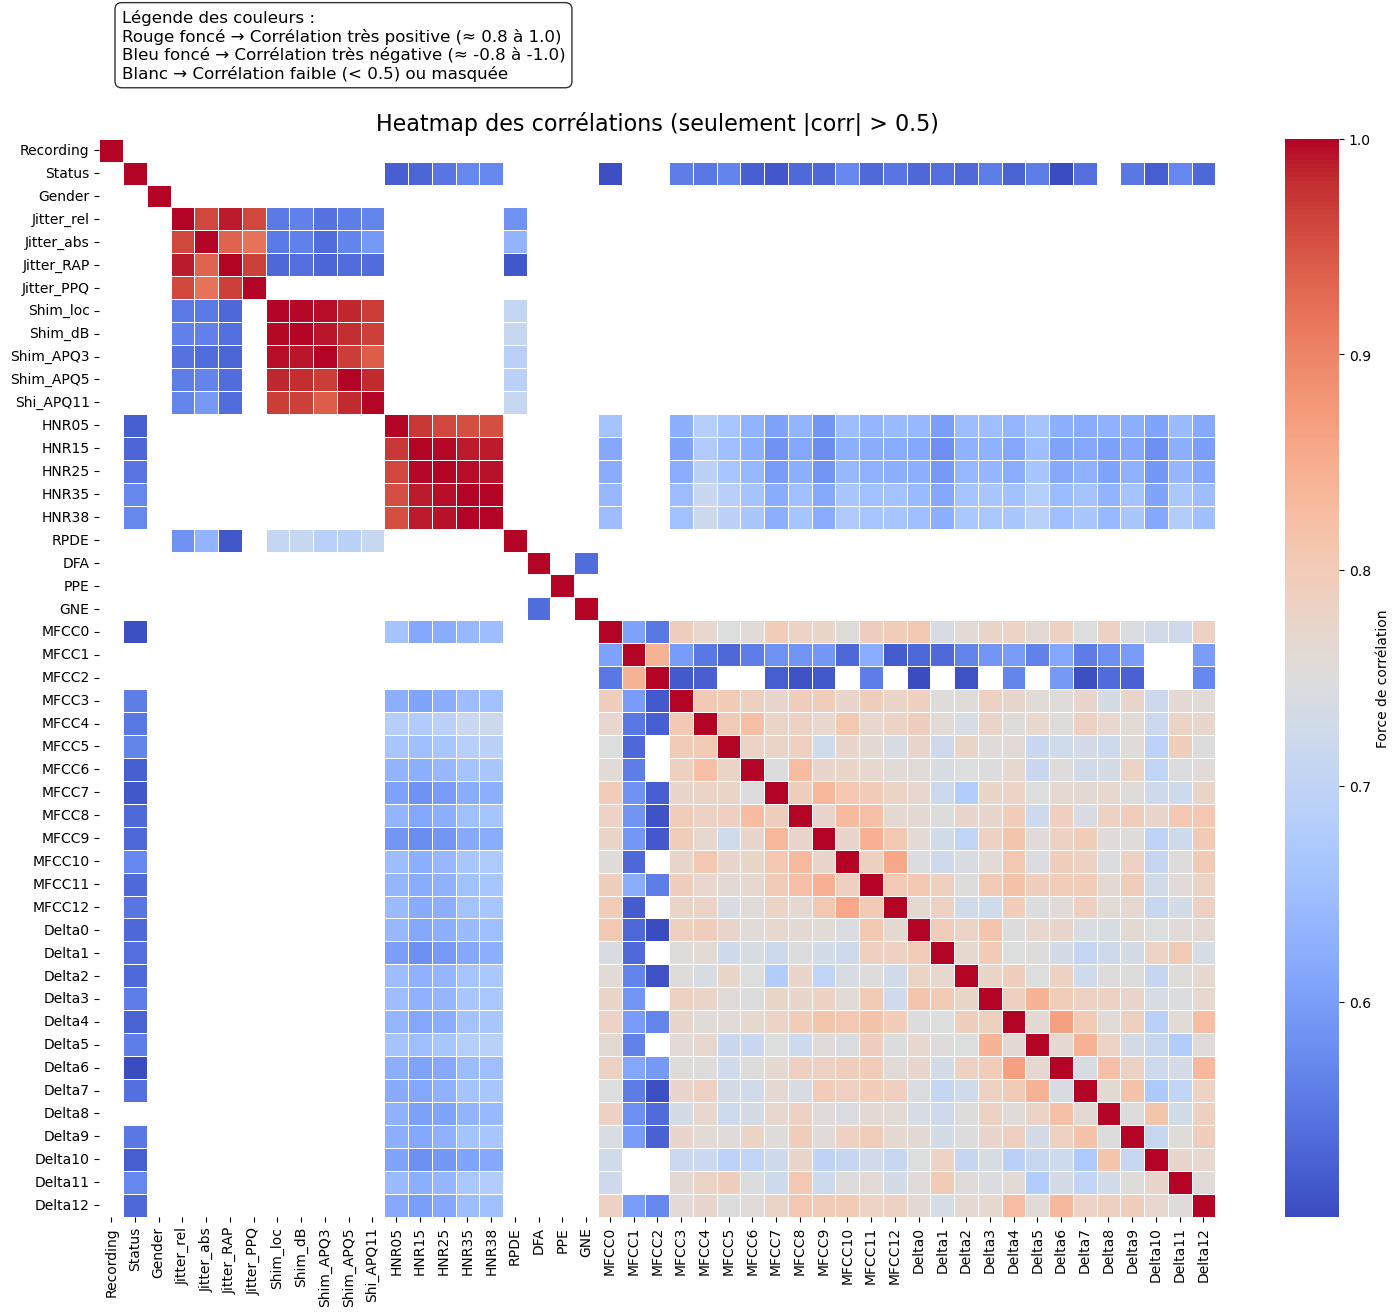

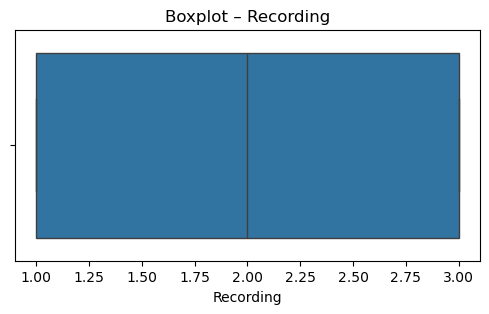

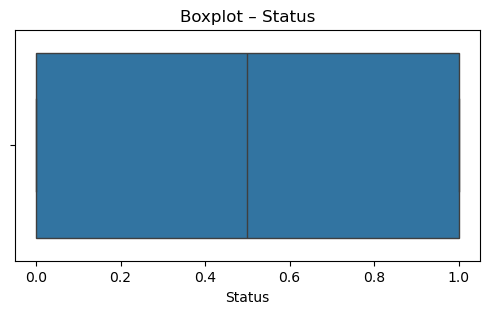

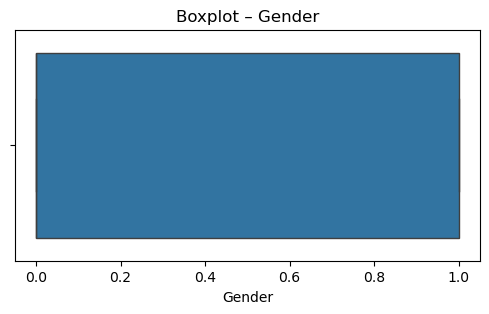

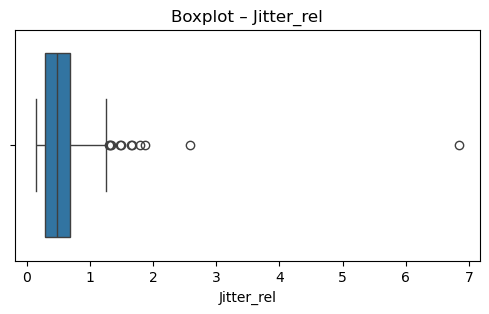

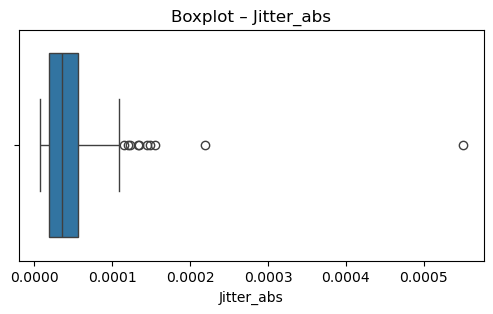

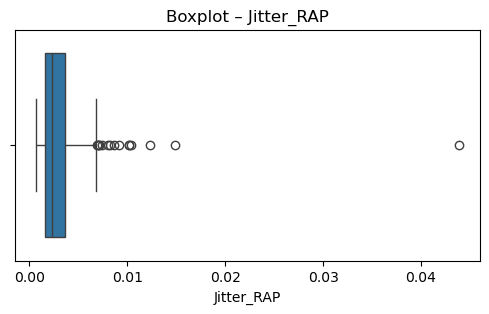

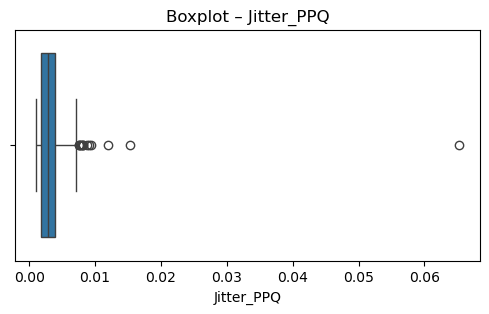

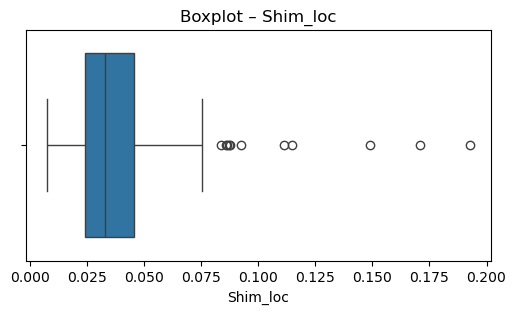

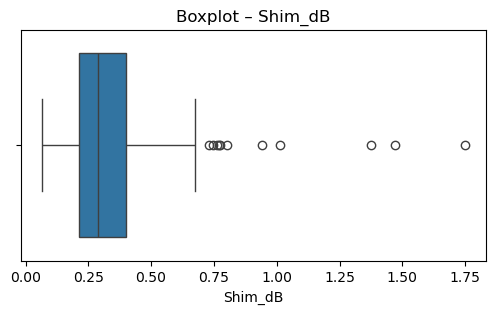

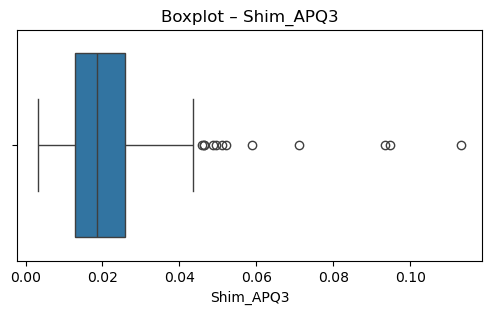

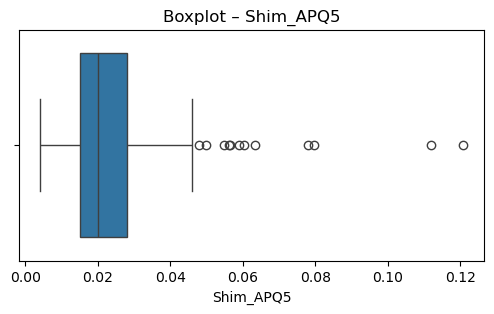

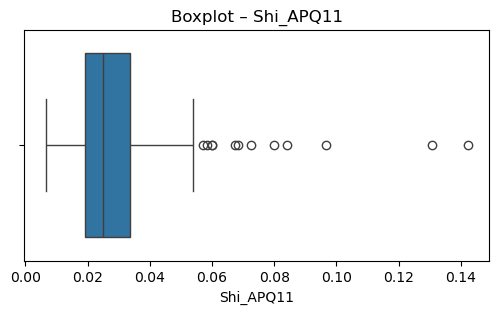

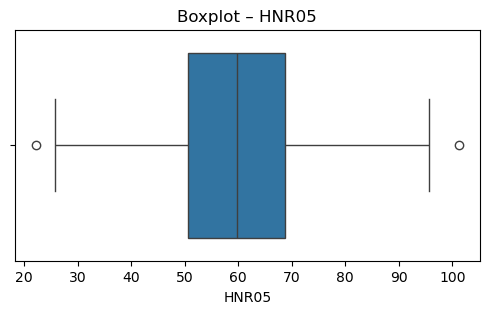

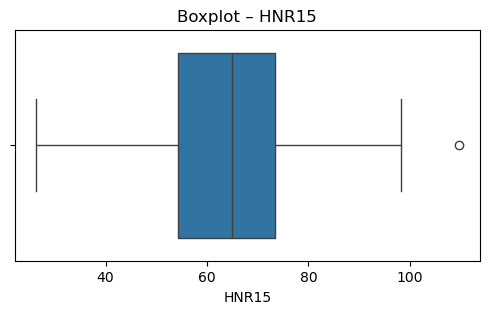

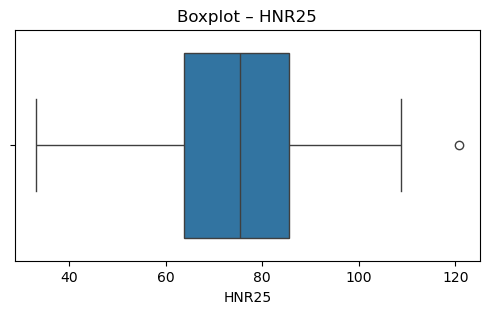

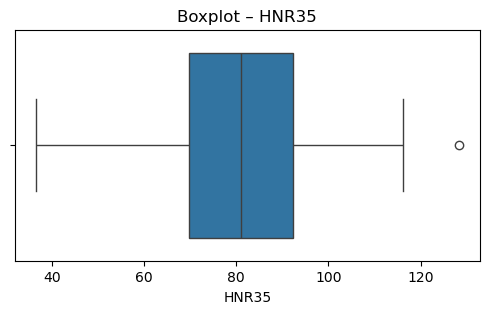

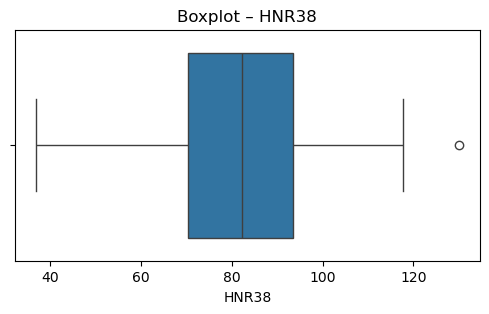

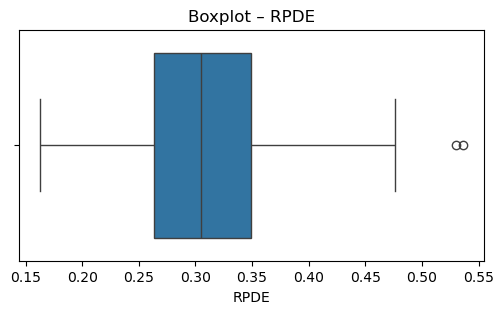

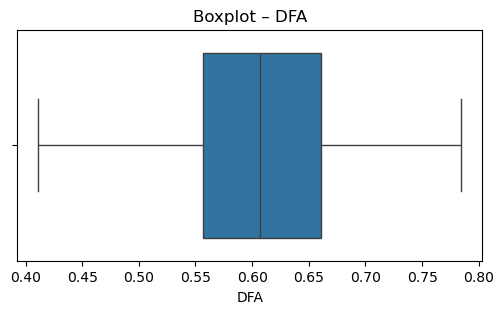

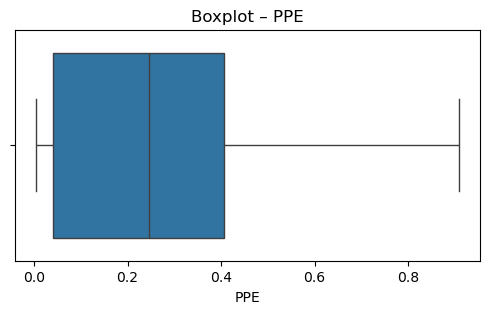

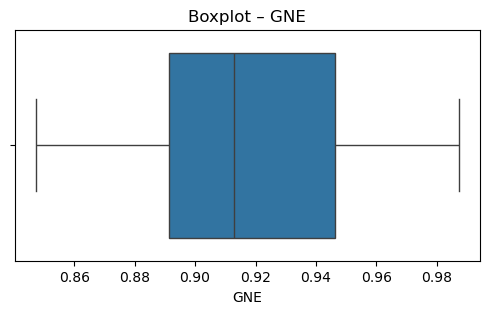

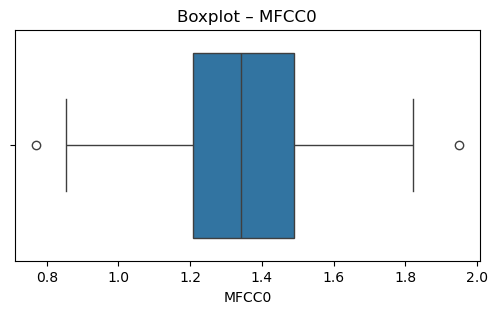

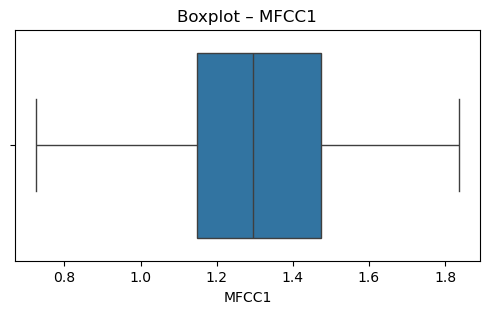

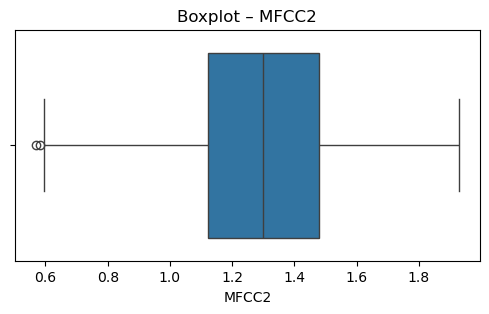

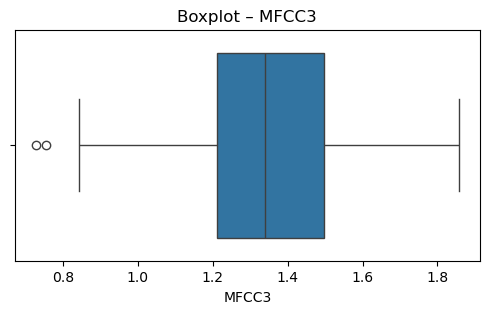

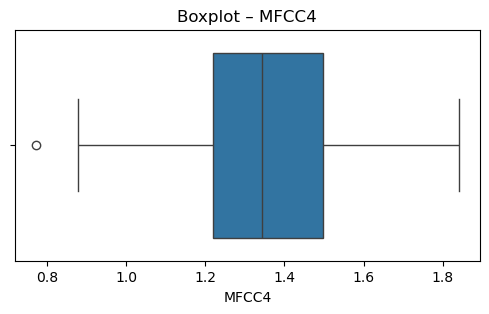

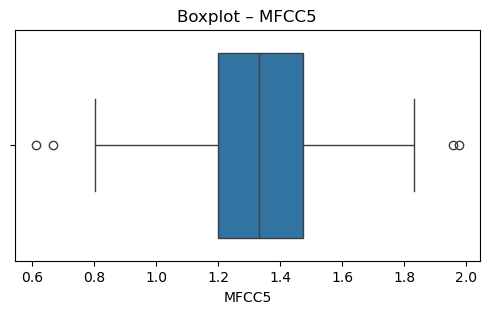

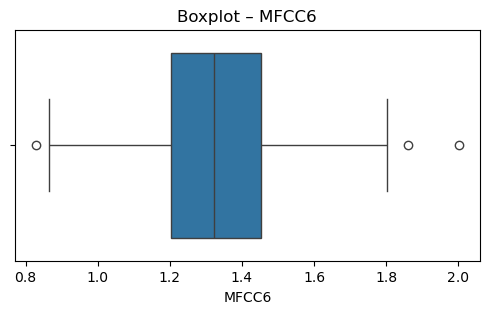

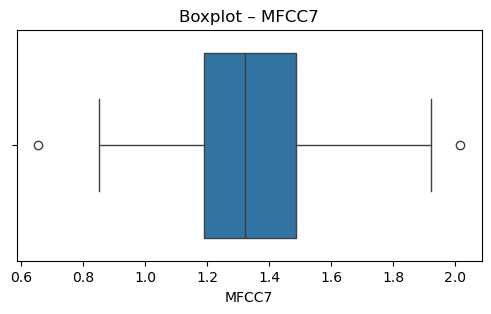

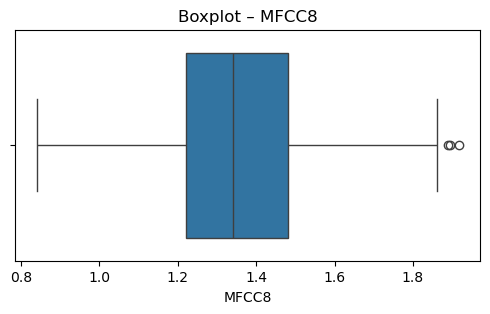

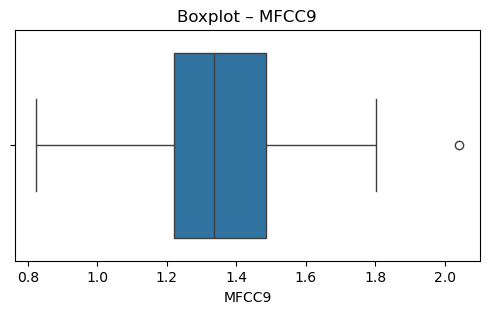

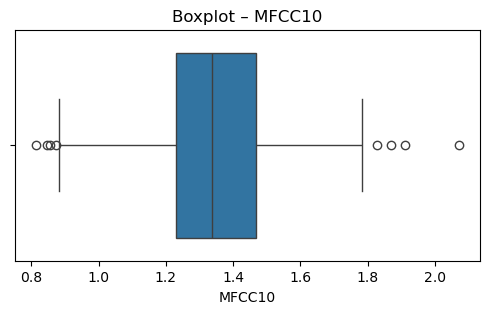

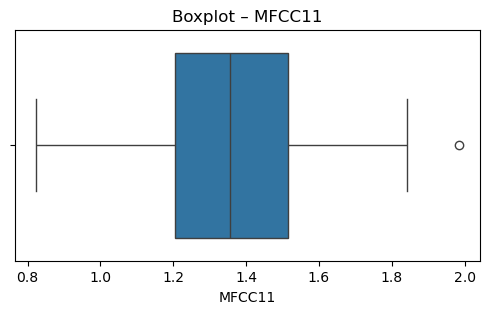

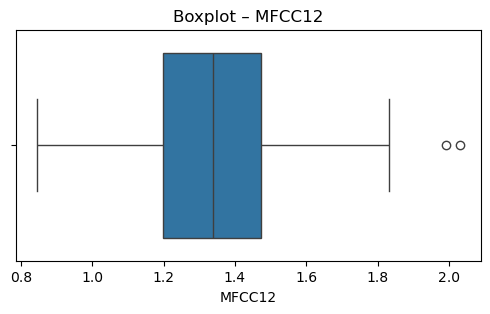

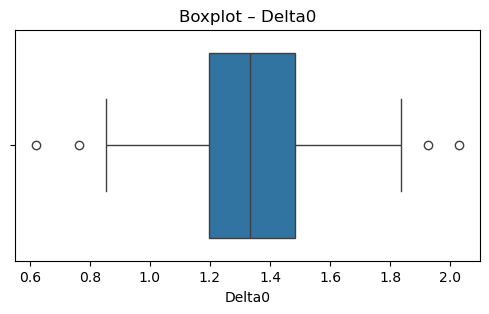

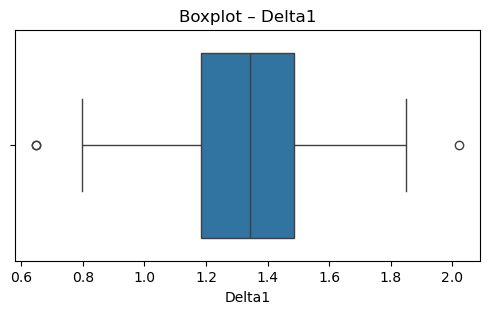

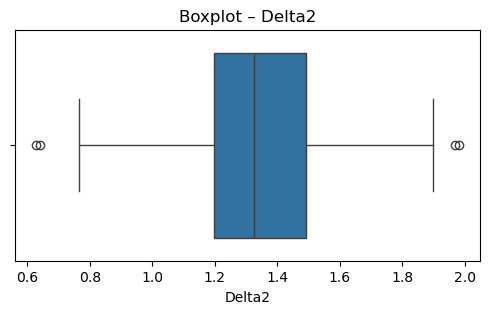

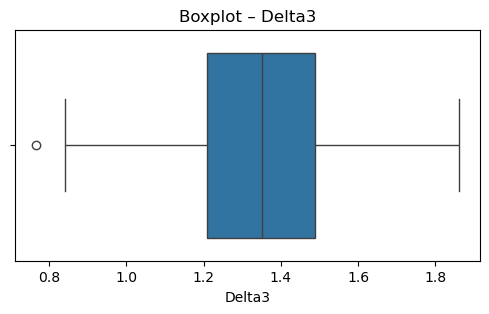

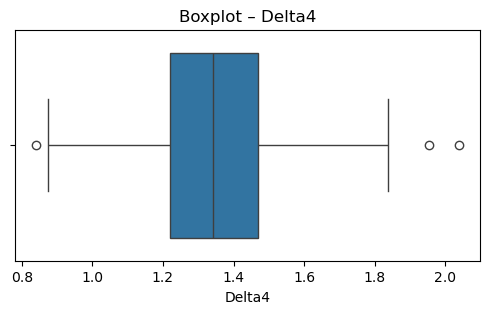

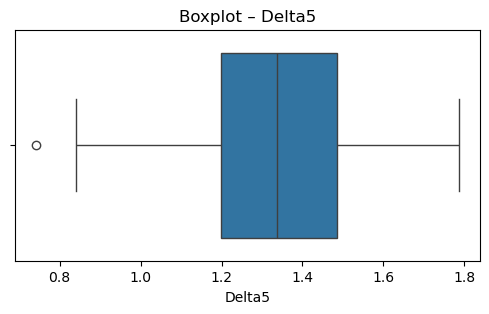

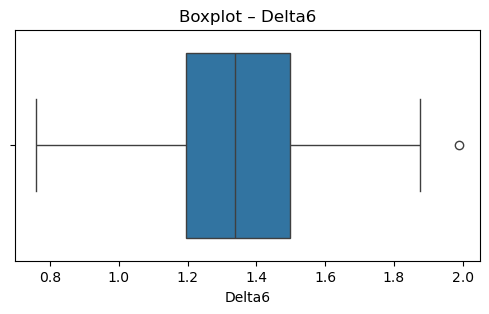

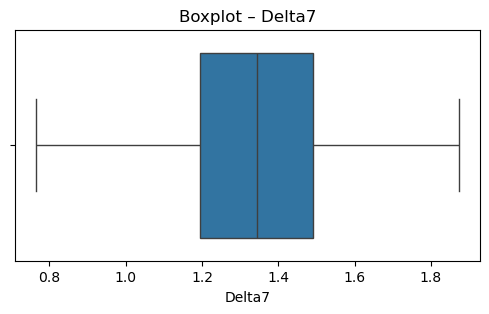

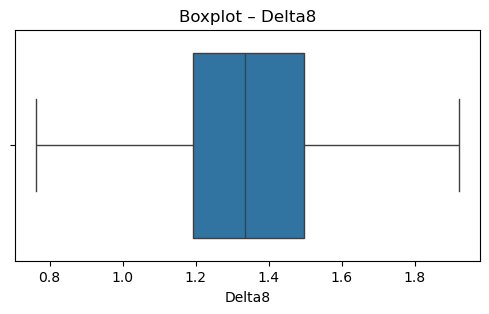

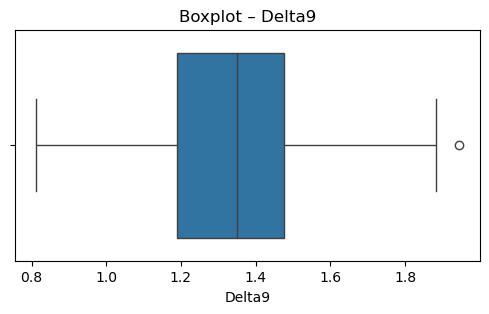

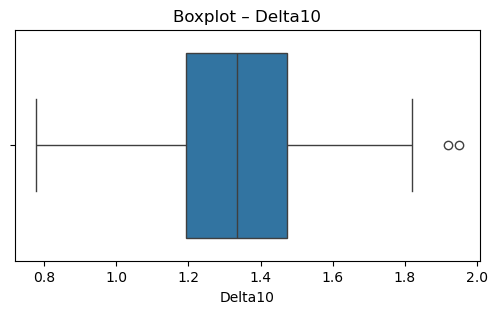

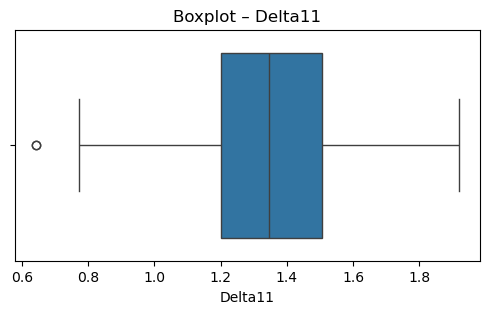

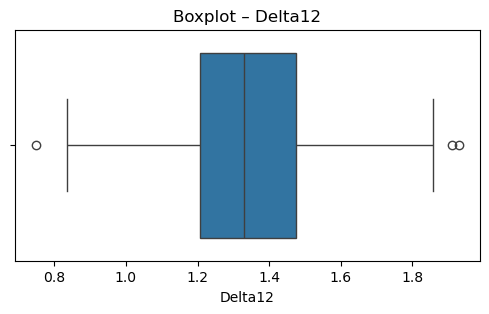

--------------------------------------------------------------------------------

 Dataset 8/14 : df8

🔹 Shape: (207, 61)

🔹 First 5 rows:


,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
2,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
3,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,...,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,R



🔹 Last 5 rows:


,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
202,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,M
203,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
204,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,M
205,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M
206,0.0260,0.0363,0.0136,0.0272,0.0214,0.0338,0.0655,0.1400,0.1843,0.2354,...,0.0146,0.0129,0.0047,0.0039,0.0061,0.0040,0.0036,0.0061,0.0115,M



🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0.0200  207 non-null    float64
 1   0.0371  207 non-null    float64
 2   0.0428  207 non-null    float64
 3   0.0207  207 non-null    float64
 4   0.0954  207 non-null    float64
 5   0.0986  207 non-null    float64
 6   0.1539  207 non-null    float64
 7   0.1601  207 non-null    float64
 8   0.3109  207 non-null    float64
 9   0.2111  207 non-null    float64
 10  0.1609  207 non-null    float64
 11  0.1582  207 non-null    float64
 12  0.2238  207 non-null    float64
 13  0.0645  207 non-null    float64
 14  0.0660  207 non-null    float64
 15  0.2273  207 non-null    float64
 16  0.3100  207 non-null    float64
 17  0.2999  207 non-null    float64
 18  0.5078  207 non-null    float64
 19  0.4797  207 non-null    float64
 20  0.5783  207 non-null    float64
 21  0.5071  207 non-null    float6

...


🔹 Duplicate rows count: 0

🔹 Target variable preview:


,R
0,R
1,R
2,R
3,R
4,R



🔹 Number of outliers per numeric column:


{'0.0200': 15,
 '0.0371': 12,
 '0.0428': 11,
 '0.0207': 11,
 '0.0954': 5,
 '0.0986': 8,
 '0.1539': 5,
 '0.1601': 11,
 '0.3109': 9,
 '0.2111': 10,
 '0.1609': 5,
 '0.1582': 2,
 '0.2238': 4,
 '0.0645': 5,
 '0.0660': 2,
 '0.2273': 0,
 '0.3100': 0,
 '0.2999': 0,
 '0.5078': 0,
 '0.4797': 0,
 '0.5783': 0,
 '0.5071': 0,
 '0.4328': 0,
 '0.5550': 2,
 '0.6711': 0,
 '0.6415': 0,
 '0.7104': 0,
 '0.8080': 0,
 '0.6791': 0,
 '0.3857': 0,
 '0.1307': 0,
 '0.2604': 0,
 '0.5121': 0,
 '0.7547': 0,
 '0.8537': 0,
 '0.8507': 0,
 '0.6692': 0,
 '0.6097': 9,
 '0.4943': 5,
 '0.2744': 4,
 '0.0510': 4,
 '0.2834': 3,
 '0.2825': 5,
 '0.4256': 12,
 '0.2641': 25,
 '0.1386': 16,
 '0.1051': 13,
 '0.1343': 9,
 '0.0383': 7,
 '0.0324': 14,
 '0.0232': 6,
 '0.0027': 14,
 '0.0065': 3,
 '0.0159': 7,
 '0.0072': 9,
 '0.0167': 9,
 '0.0180': 8,
 '0.0084': 8,
 '0.0090': 12,
 '0.0032': 8}


Distribution des variables numériques :


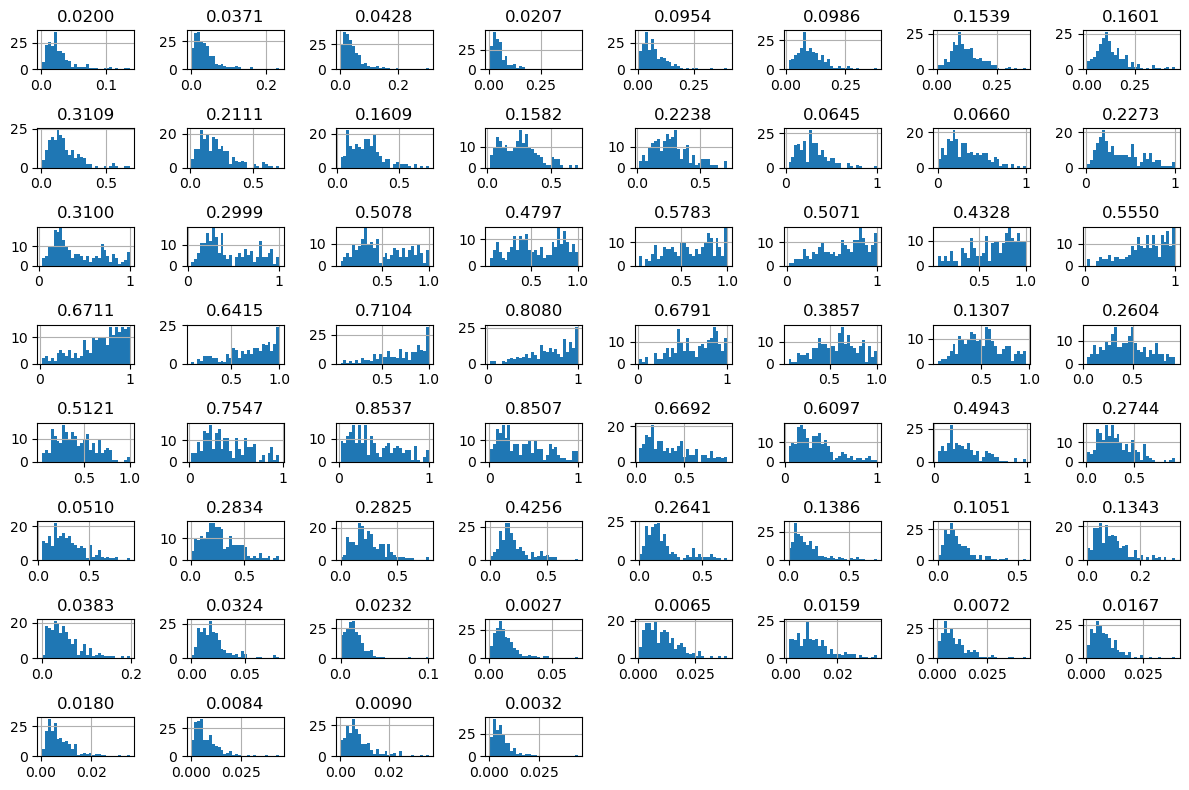

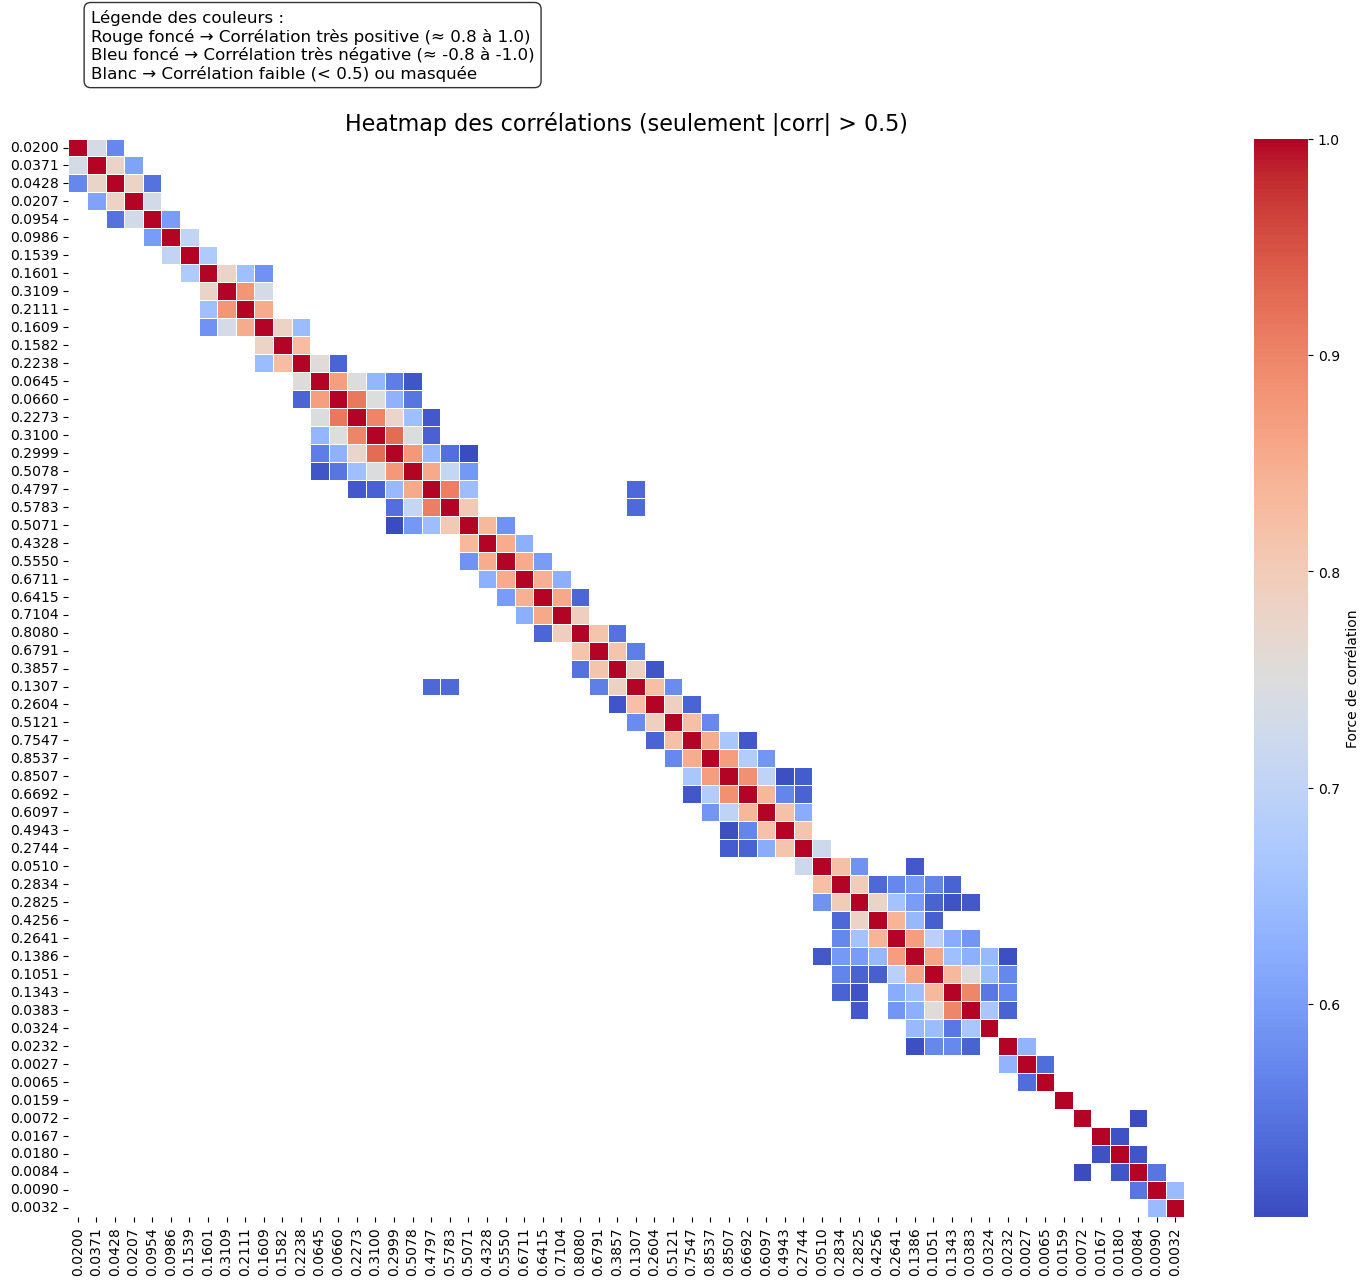

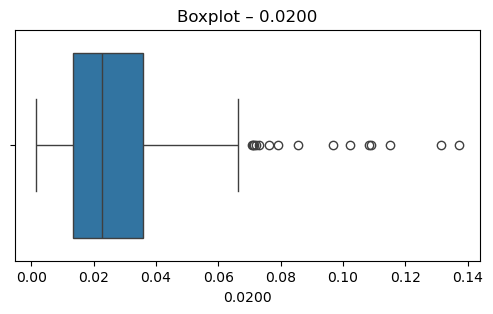

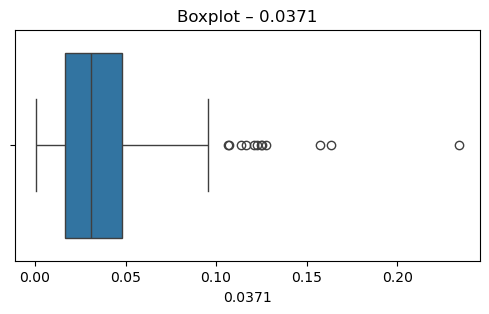

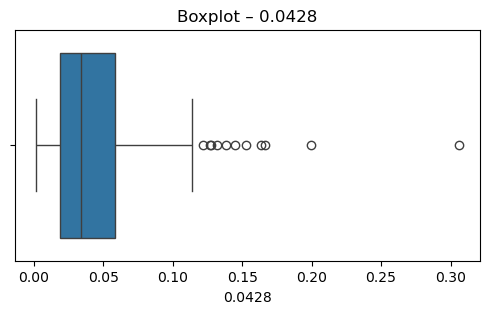

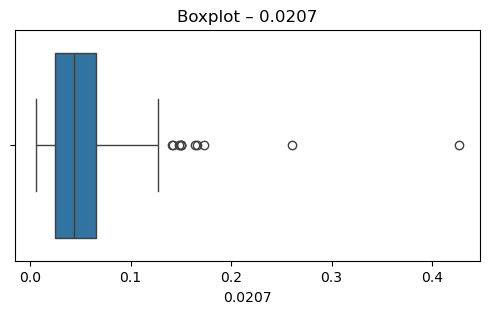

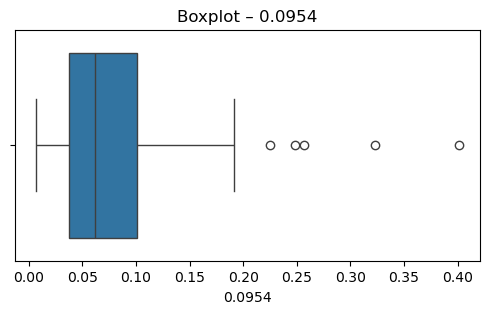

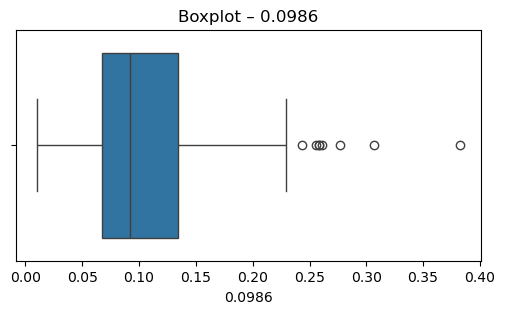

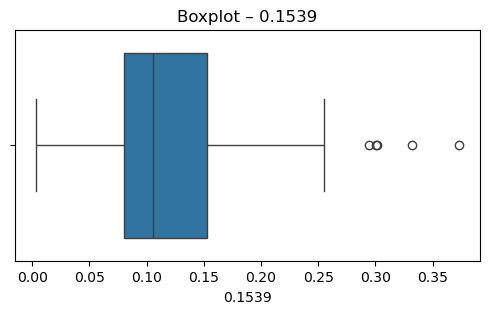

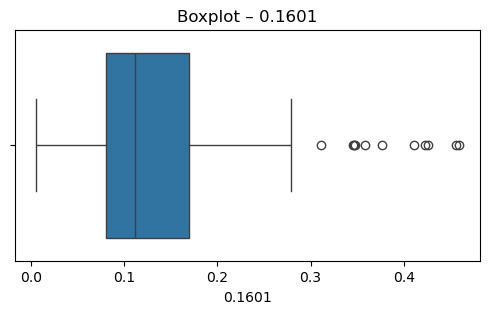

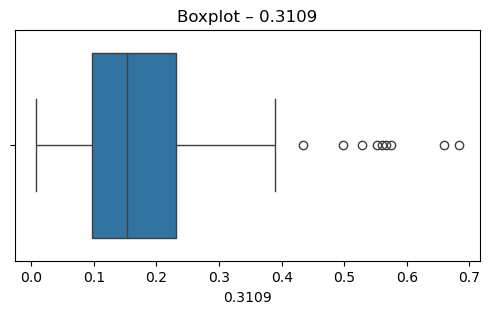

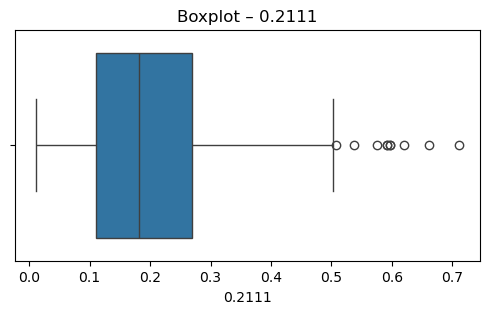

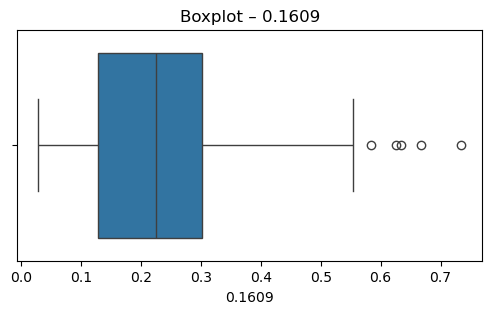

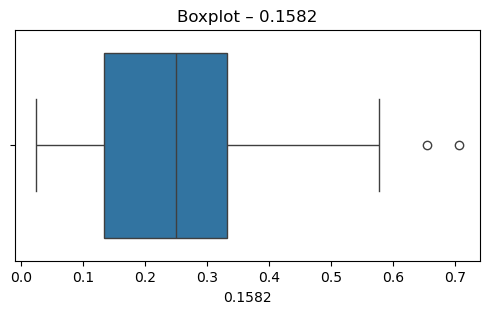

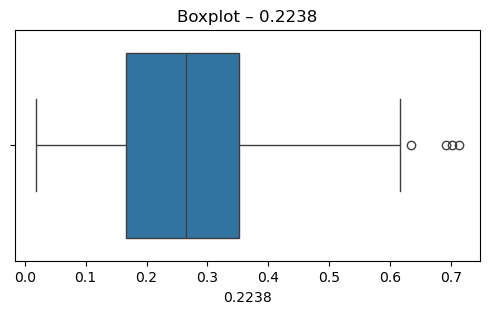

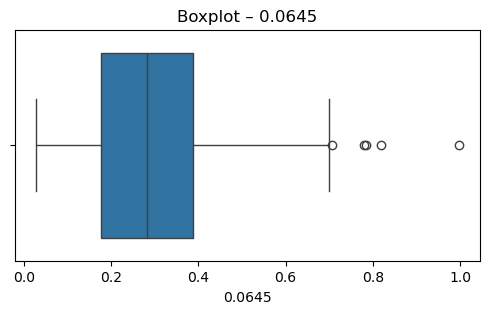

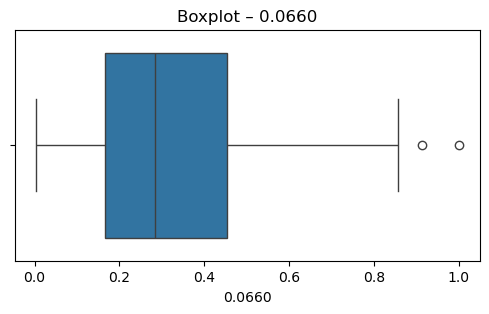

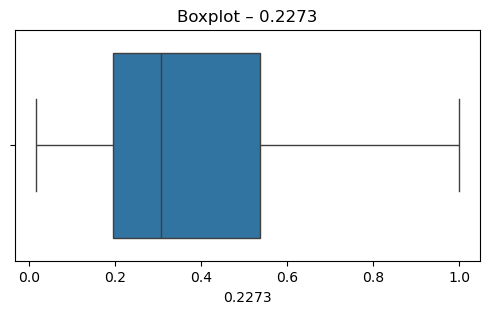

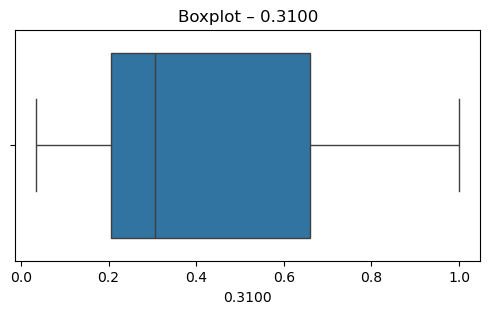

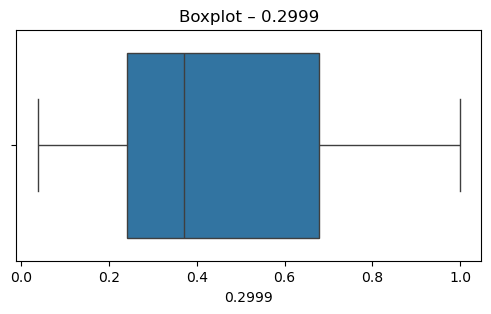

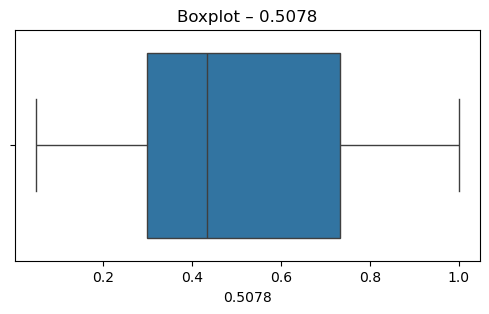

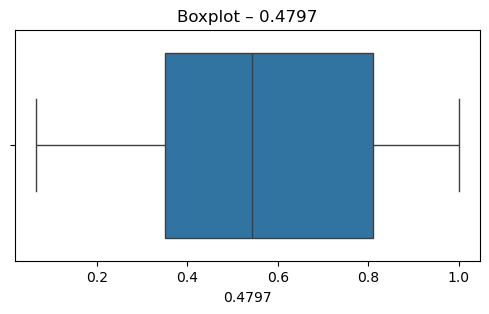

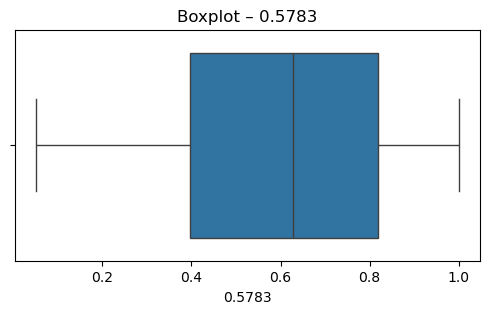

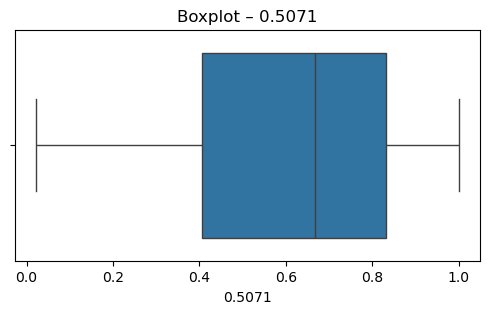

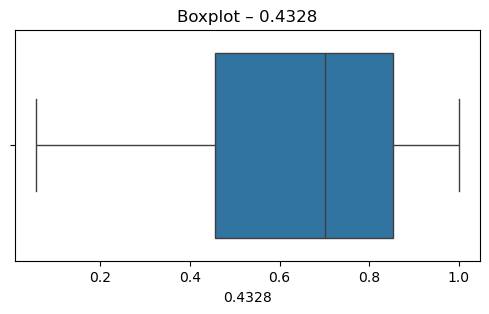

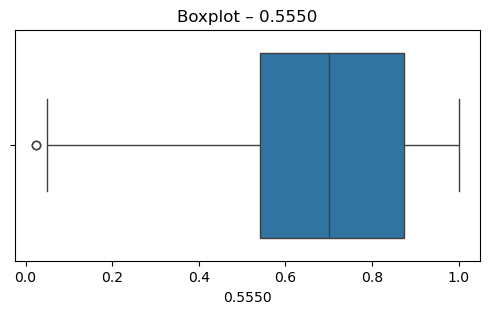

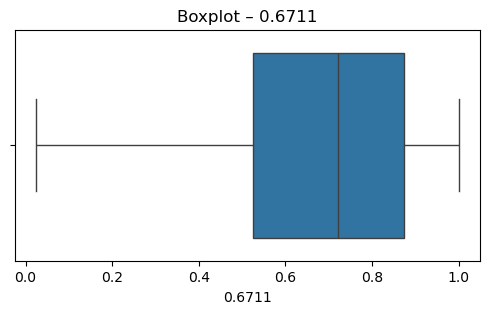

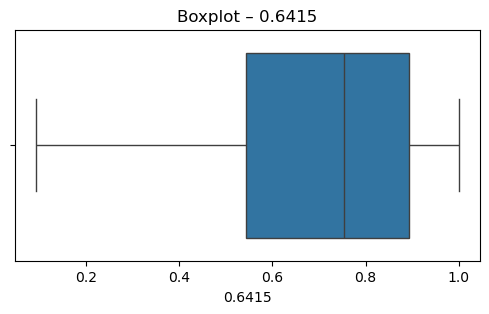

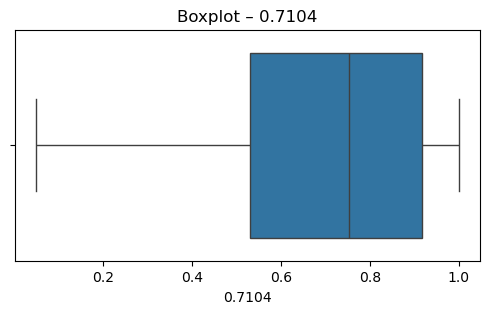

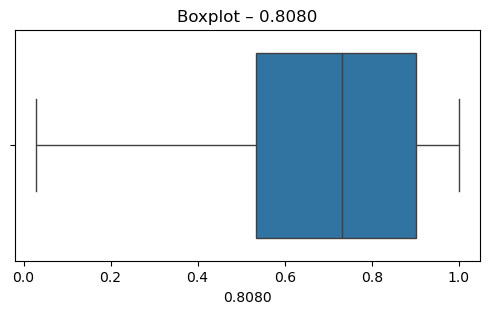

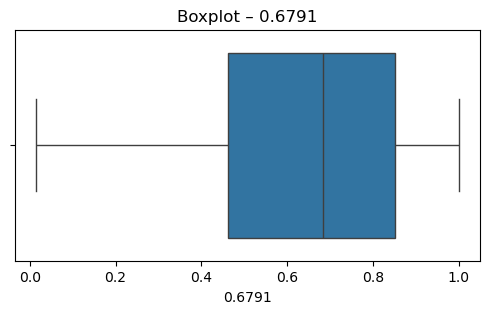

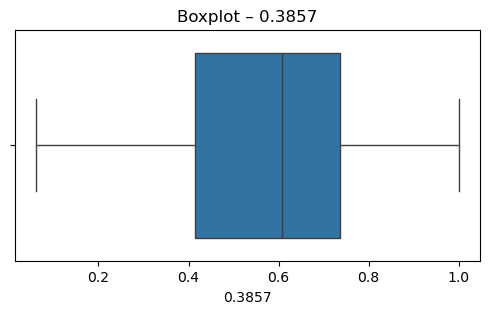

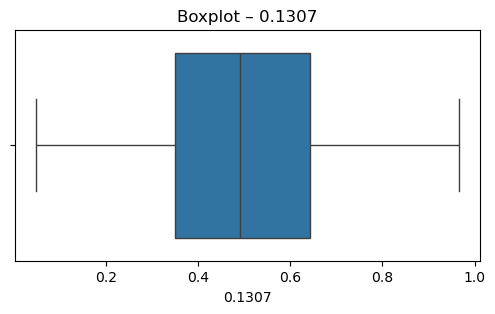

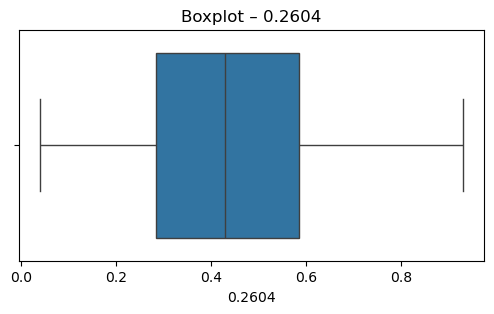

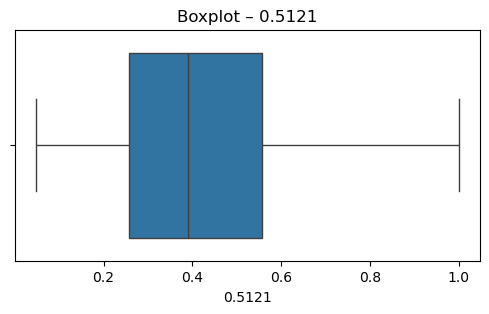

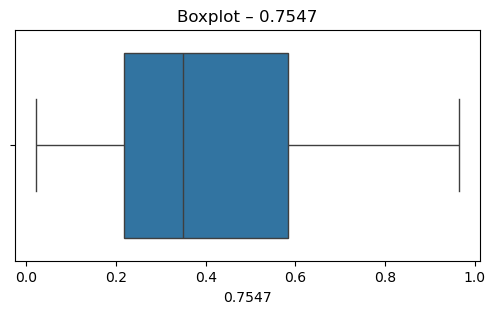

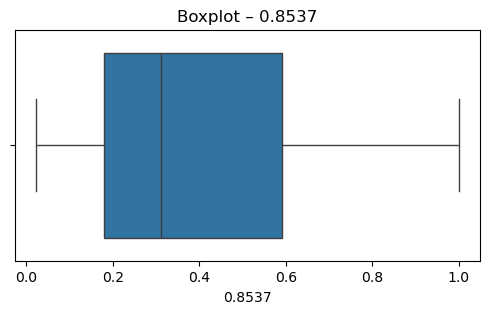

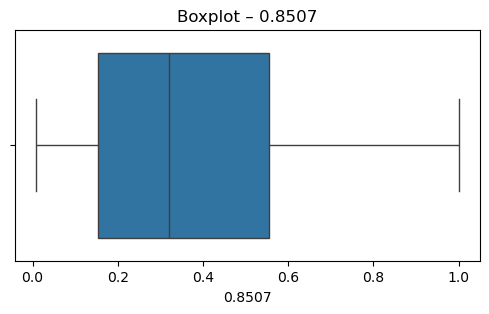

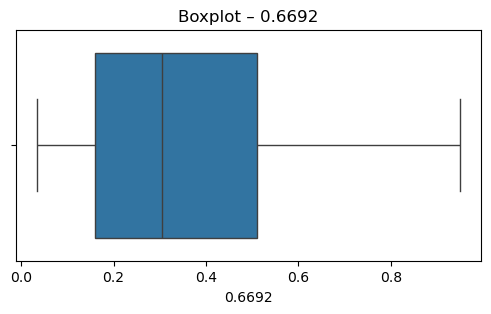

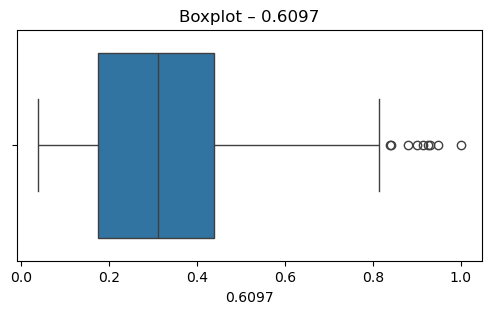

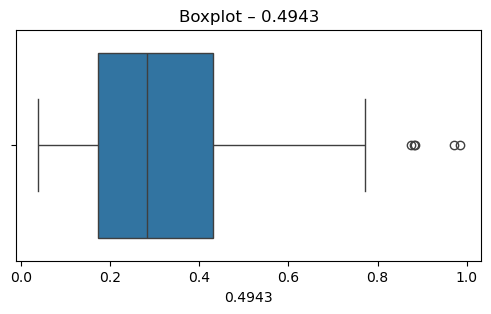

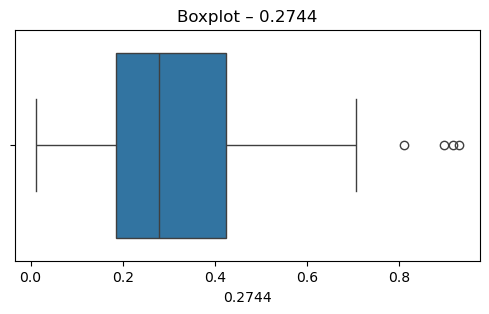

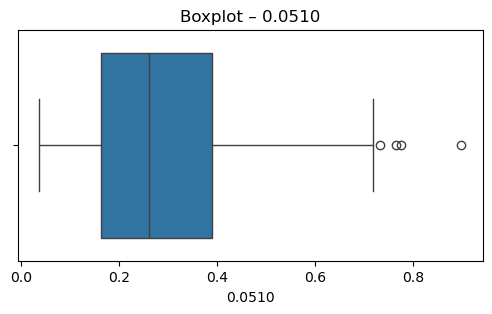

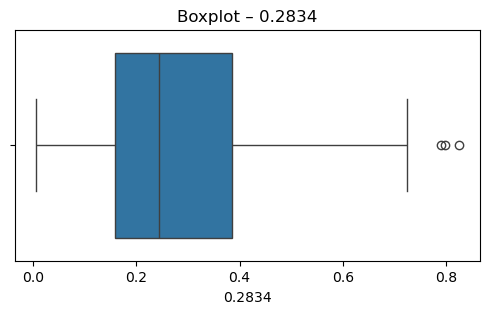

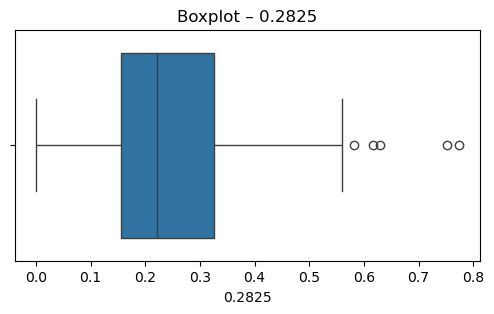

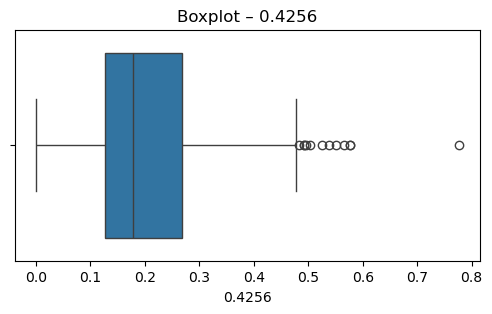

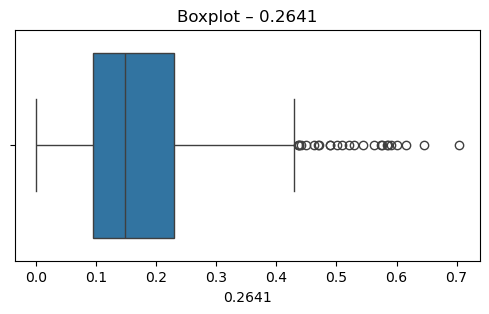

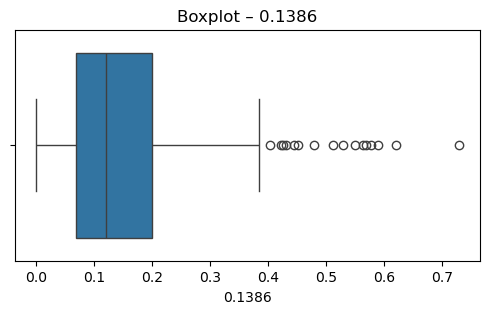

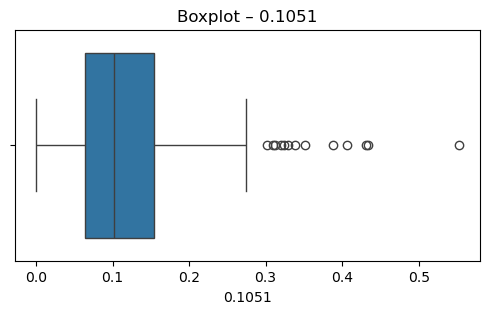

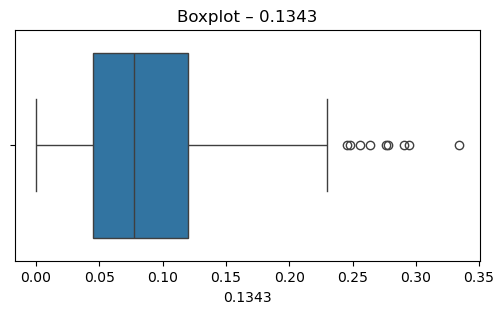

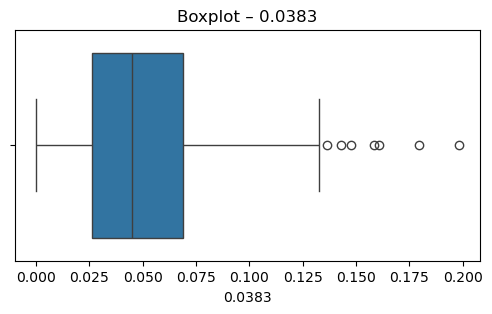

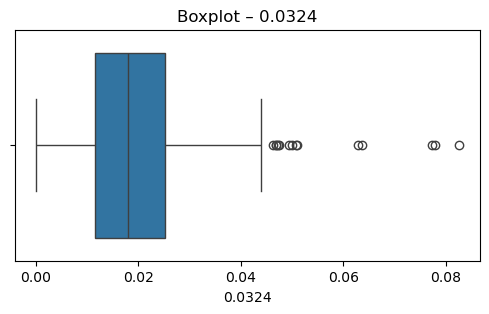

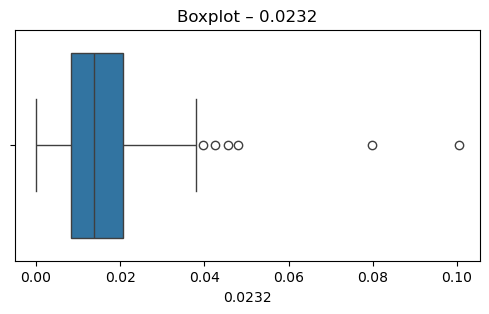

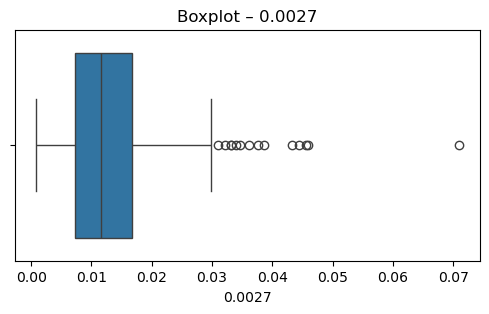

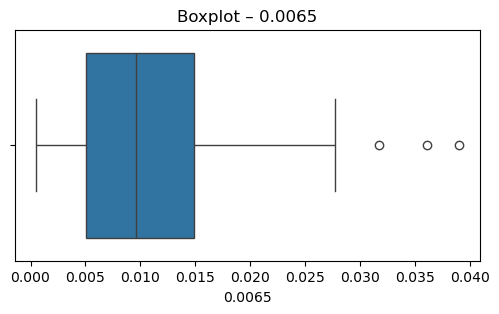

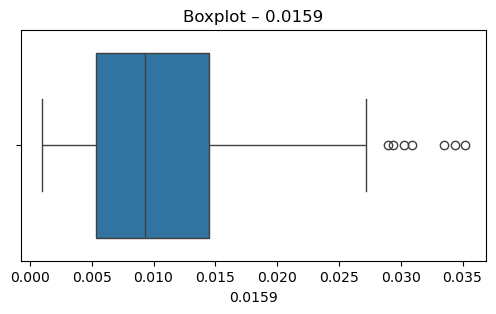

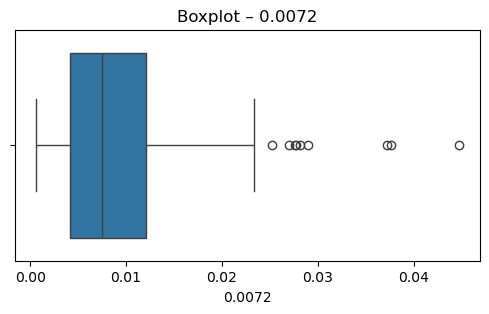

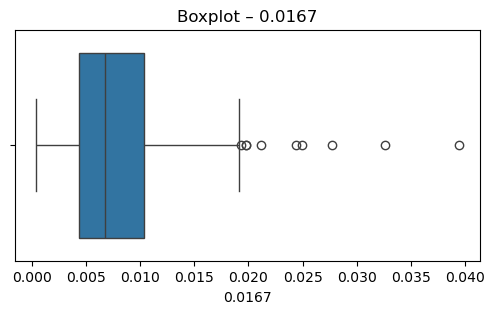

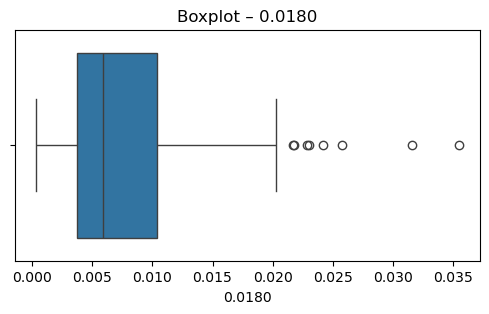

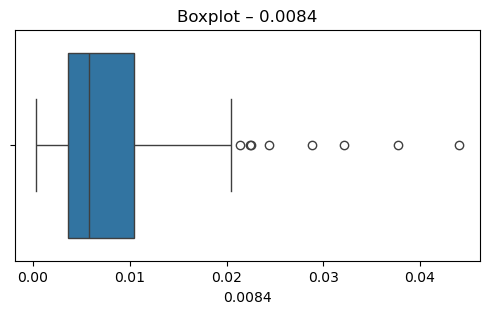

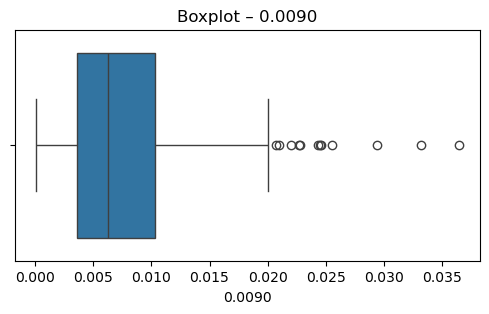

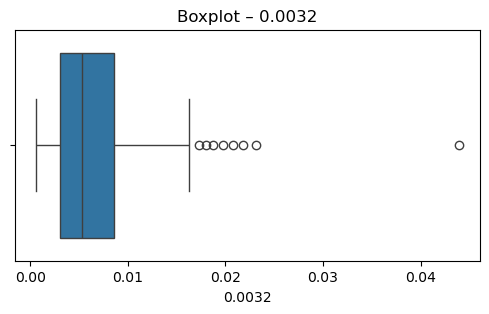

--------------------------------------------------------------------------------

 Dataset 9/14 : df9

🔹 Shape: (1599, 12)

🔹 First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



🔹 Last 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6



🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

🔹 Data types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
r

...


🔹 Target variable preview:


,quality
0,5
1,5
2,5
3,6
4,5



🔹 Number of outliers per numeric column:


{'fixed acidity': 49,
 'volatile acidity': 19,
 'citric acid': 1,
 'residual sugar': 155,
 'chlorides': 112,
 'free sulfur dioxide': 30,
 'total sulfur dioxide': 55,
 'density': 45,
 'pH': 35,
 'sulphates': 59,
 'alcohol': 13,
 'quality': 28}


Distribution des variables numériques :


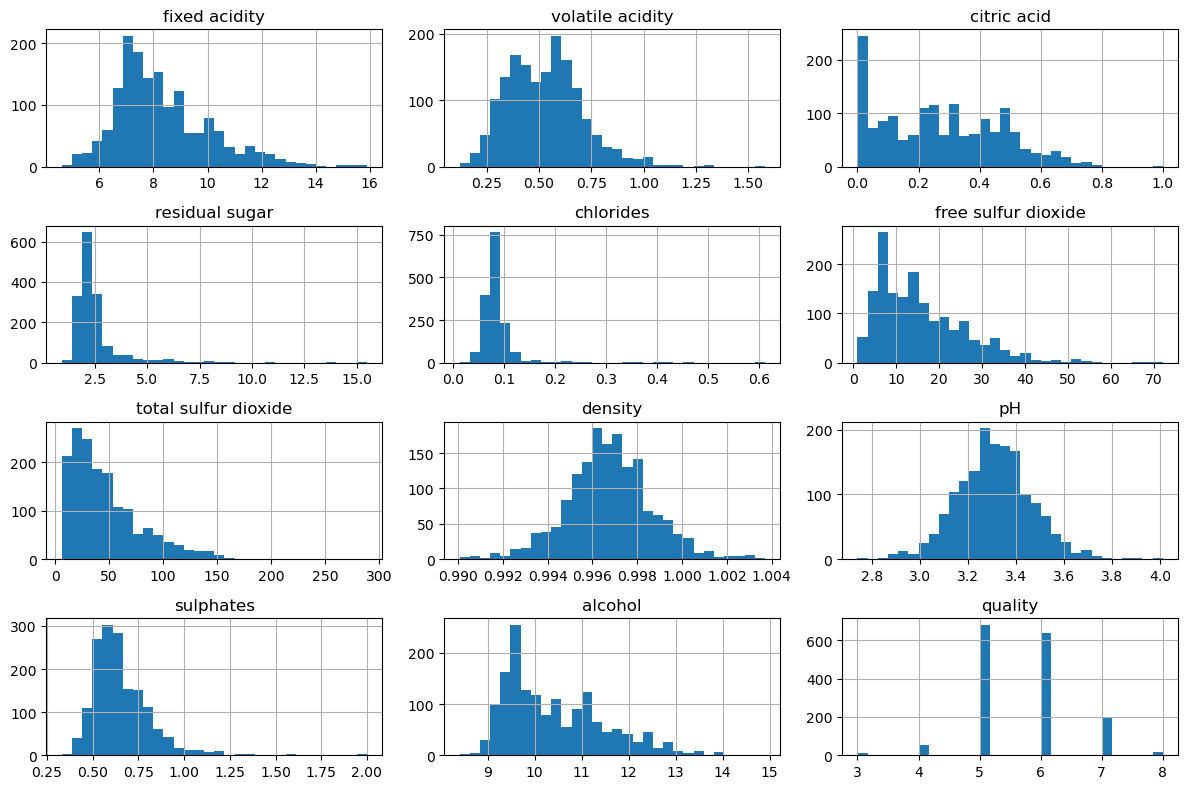

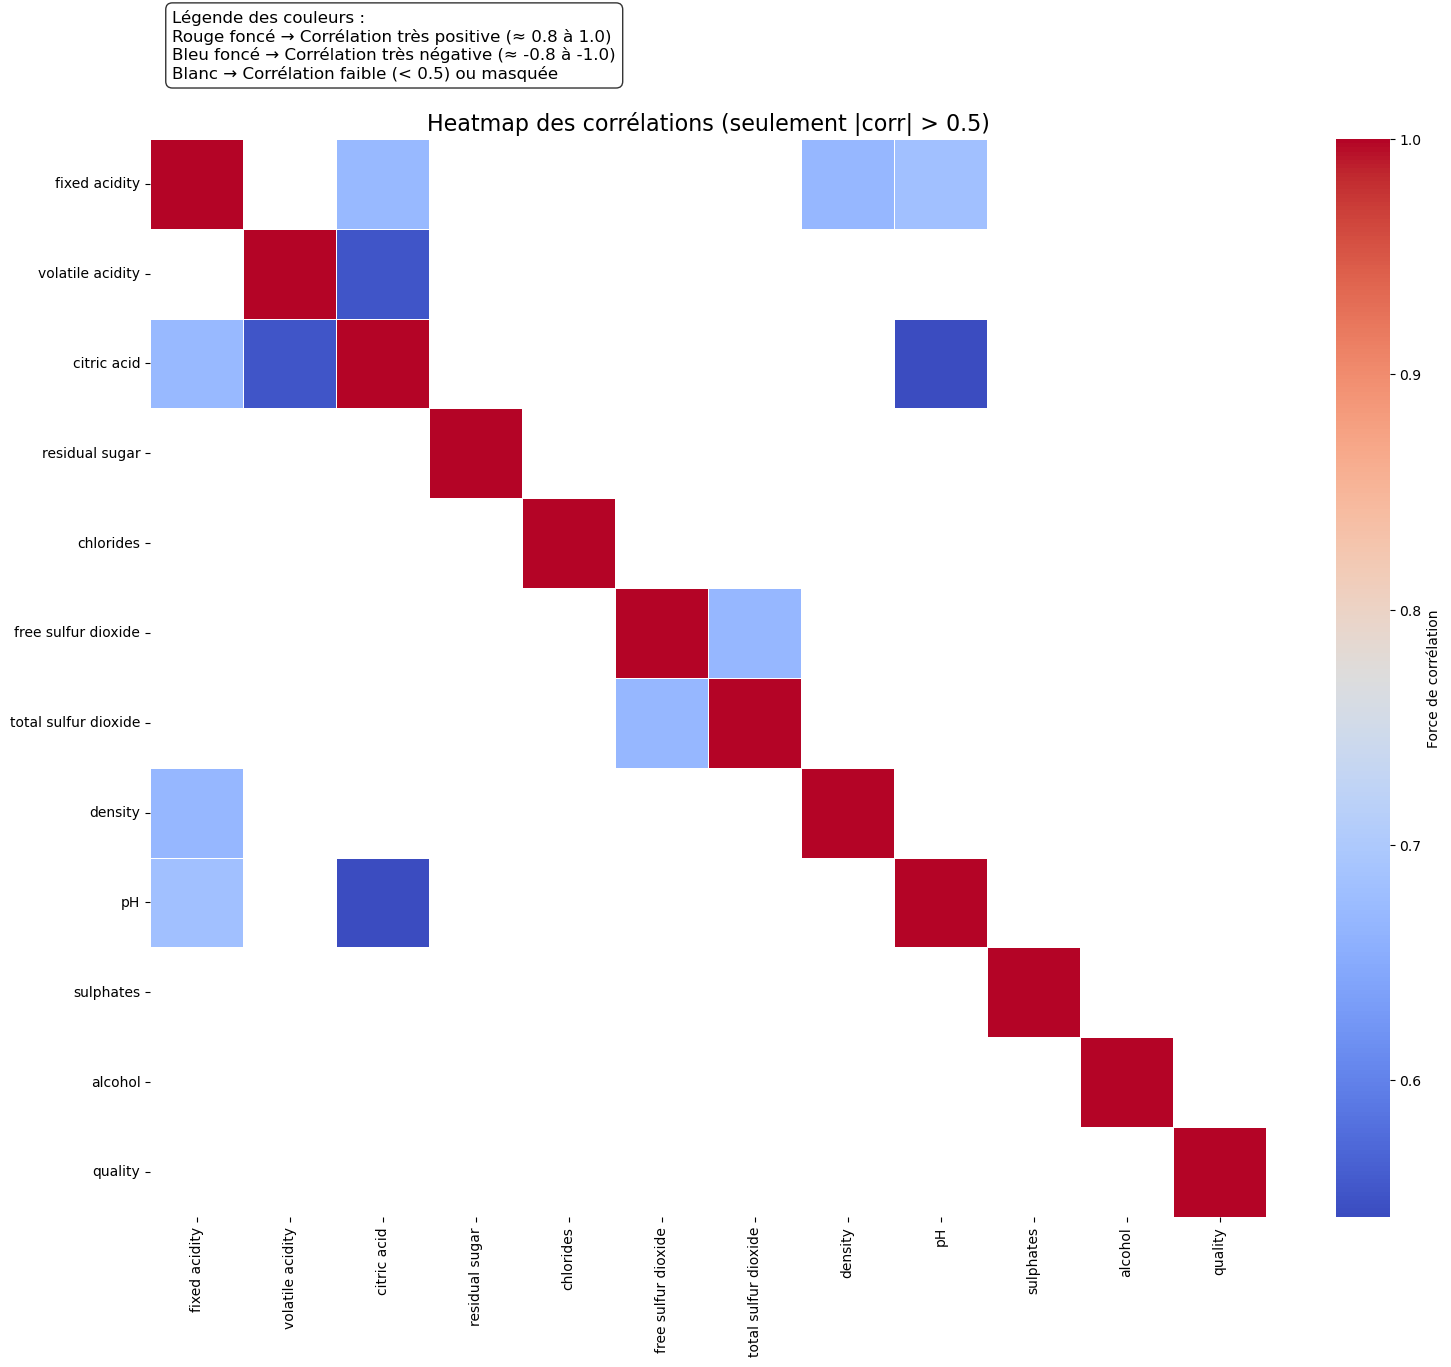

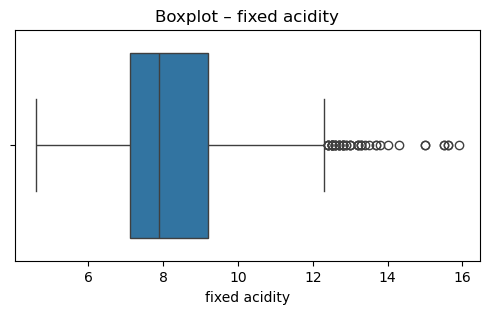

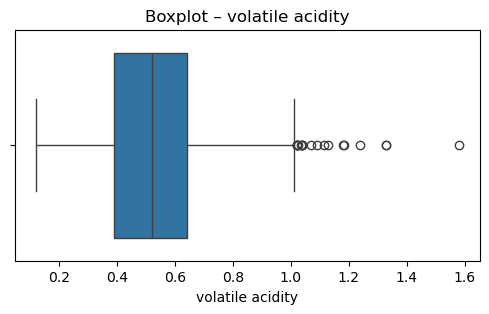

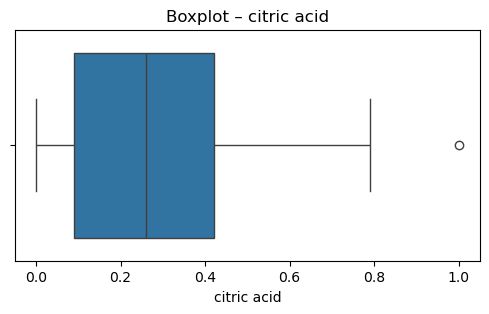

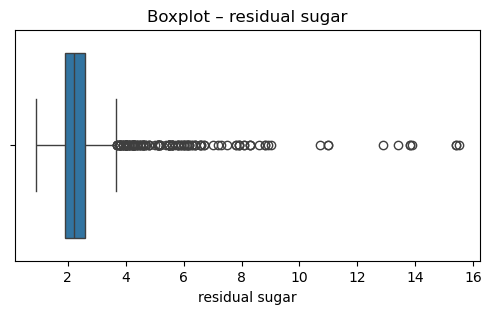

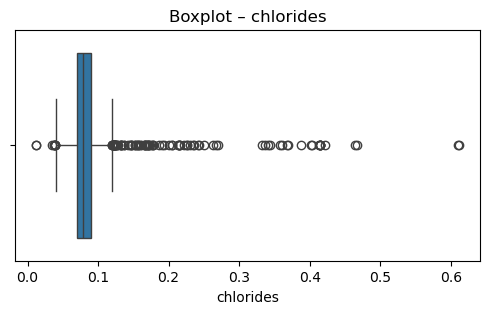

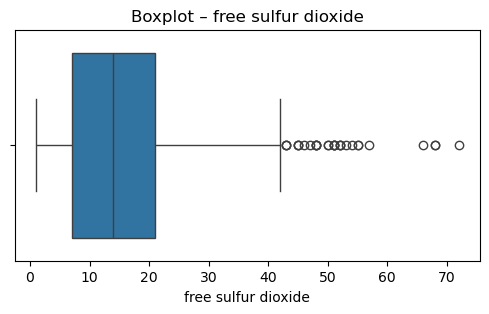

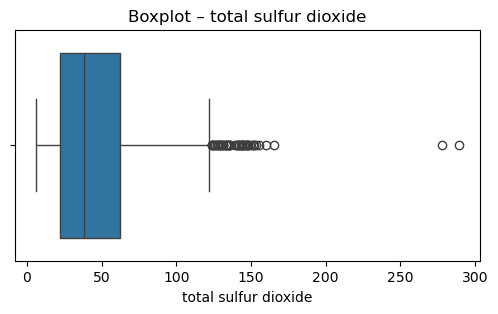

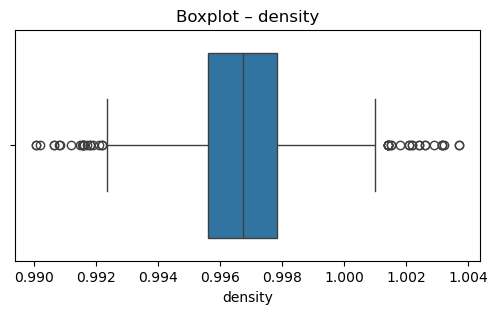

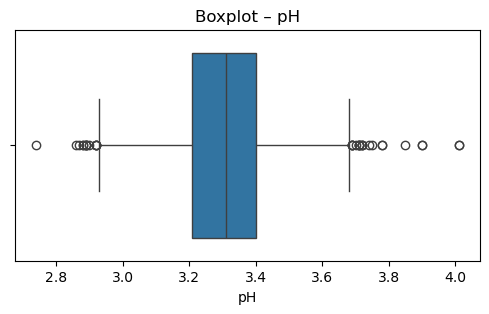

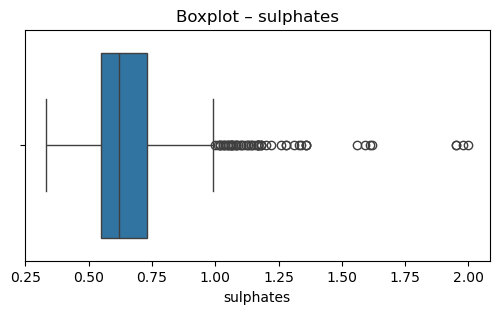

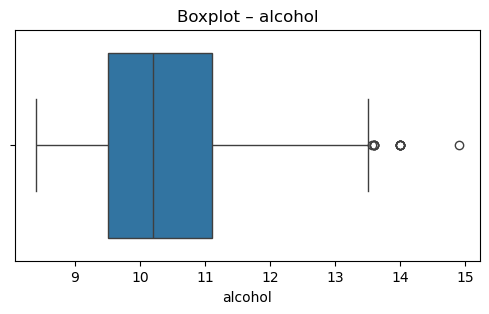

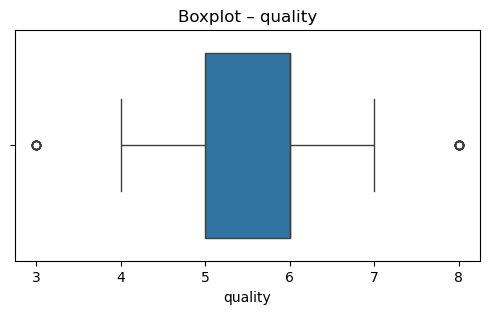

--------------------------------------------------------------------------------

 Dataset 10/14 : df10

🔹 Shape: (4898, 1)

🔹 First 5 rows:


,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
0,7;0.27;0.36;20.7;0.045;45;170;1.001;3;0.45;8.8;6
1,6.3;0.3;0.34;1.6;0.049;14;132;0.994;3.3;0.49;9...
2,8.1;0.28;0.4;6.9;0.05;30;97;0.9951;3.26;0.44;1...
3,7.2;0.23;0.32;8.5;0.058;47;186;0.9956;3.19;0.4...
4,7.2;0.23;0.32;8.5;0.058;47;186;0.9956;3.19;0.4...



🔹 Last 5 rows:


,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
4893,6.2;0.21;0.29;1.6;0.039;24;92;0.99114;3.27;0.5...
4894,6.6;0.32;0.36;8;0.047;57;168;0.9949;3.15;0.46;...
4895,6.5;0.24;0.19;1.2;0.041;30;111;0.99254;2.99;0....
4896,5.5;0.29;0.3;1.1;0.022;20;110;0.98869;3.34;0.3...
4897,6;0.21;0.38;0.8;0.02;22;98;0.98941;3.26;0.32;1...



🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 1 columns):
 #   Column                                                                                                                                                                   Non-Null Count  Dtype 
---  ------                                                                                                                                                                   --------------  ----- 
 0   fixed acidity;"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"  4898 non-null   object
dtypes: object(1)
memory usage: 38.4+ KB
None

🔹 Data types:
fixed acidity;"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"    object
dtype: object

🔹 Missing values per column:


...


🔹 Duplicate rows count: 937
🔹 Duplicate rows:


,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
0,7;0.27;0.36;20.7;0.045;45;170;1.001;3;0.45;8.8;6
1,6.3;0.3;0.34;1.6;0.049;14;132;0.994;3.3;0.49;9...
2,8.1;0.28;0.4;6.9;0.05;30;97;0.9951;3.26;0.44;1...
3,7.2;0.23;0.32;8.5;0.058;47;186;0.9956;3.19;0.4...
4,7.2;0.23;0.32;8.5;0.058;47;186;0.9956;3.19;0.4...
...,...
4851,6.4;0.33;0.44;8.9;0.055;52;164;0.99488;3.1;0.4...
4855,7.1;0.23;0.39;13.7;0.058;26;172;0.99755;2.9;0....
4856,7.1;0.23;0.39;13.7;0.058;26;172;0.99755;2.9;0....
4879,6.6;0.34;0.4;8.1;0.046;68;170;0.99494;3.15;0.5...



🔹 Target variable preview:

🔹 Number of outliers per numeric column:


{}


Aucune variable numérique à afficher pour ce dataset.
Pas assez de variables numériques pour afficher une heatmap.
--------------------------------------------------------------------------------


In [149]:
for i, (name, X) in enumerate(df.items(), start=1):
    print("\n" + "=" * 80)
    print(f" Dataset {i}/14 : {name}")
    print("=" * 80)

    data_understanding(X,target_column = TARGET_COLS[name]
)

    print("-" * 80)
   

# Phase 3 : Data Preparation

In [112]:
for name, df_data in df.items():
    print("\n" + "="*80)
    print(f" Dataset : {name}")
    print("="*80)

    target_column = TARGET_COLS[name]

    if not target_column or target_column not in df_data.columns:
        print(f" Target '{target_column}' invalide pour {name}, skipping...")
        continue

    # Liste des colonnes numériques (sécurisée)
    numeric_columns = [
        col for col in df_data.select_dtypes(include=["int64", "float64"]).columns
        if col in df_data.columns and col != target_column
    ]

    # Appliquer le capping IQR (sur df_data et non df !!!)
    df_capped = cap_iqr(df_data, numeric_columns, factor=1.5)

    # Appliquer data_preparation()
    X, X_prepared, y, pipeline, removed_cols = data_preparation(
        df_capped,
        target_column=target_column,
        apply_capping=True
    )

    print(f" Dataset {name} traité avec succès.")






 Dataset : df1

=== DATA PREPARATION SUMMARY ===
Shape before preparation: (569, 33)
Shape after preparation: (569, 32)
Columns removed: ['Unnamed: 32']

Target preview:


0    M
1    M
2    M
3    M
4    M
Name: diagnosis, dtype: object


X (before preprocessing):


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302.0,17.99,10.38,122.80,1001.0,0.118400,0.22862,0.28241,0.14710,0.2419,...,25.38,17.33,184.60,1937.05,0.1622,0.62695,0.7119,0.2654,0.41915,0.11890
1,842517.0,20.57,17.77,132.90,1326.0,0.084740,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1937.05,0.1238,0.18660,0.2416,0.1860,0.27500,0.08902
2,20728995.5,19.69,21.25,130.00,1203.0,0.109600,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.00,0.1444,0.42450,0.4504,0.2430,0.36130,0.08758
3,20728995.5,11.42,20.38,77.58,386.1,0.133695,0.22862,0.24140,0.10520,0.2464,...,14.91,26.50,98.87,567.70,0.1901,0.62695,0.6869,0.2575,0.41915,0.12301
4,20728995.5,20.29,14.34,135.10,1297.0,0.100300,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.00,0.1374,0.20500,0.4000,0.1625,0.23640,0.07678



X_prepared shape: (569, 31)

Preprocessor used:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['id', 'radius_mean', 'texture_mean',
                                  'perimeter_mean', 'area_mean',
                                  'smoothness_mean', 'compactness_mean',
                                  'concavity_mean', 'concave points_mean',
                                  'symmetry_mean', 'fractal_dimension_mean',
                                  'radius_se', 'texture_se', 'perimeter_se',
                                  'area_se', 'smoothness_se', 'compactness_se',
                                  'concavity_se', 'concave points_se',
                                  'symmetry_se', 'fractal_dimension_se',
                                  'radius_worst', 'texture_worst',
                                  'perimeter_worst', 'area_worst',
                                  

...


X_prepared shape: (207, 60)

Preprocessor used:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['0.0200', '0.0371', '0.0428', '0.0207',
                                  '0.0954', '0.0986', '0.1539', '0.1601',
                                  '0.3109', '0.2111', '0.1609', '0.1582',
                                  '0.2238', '0.0645', '0.0660', '0.2273',
                                  '0.3100', '0.2999', '0.5078', '0.4797',
                                  '0.5783', '0.5071', '0.4328', '0.5550',
                                  '0.6711', '0.6415', '0.7104', '0.8080',
                                  '0.6791', '0.3857', ...]),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 [])])
 Dataset df8 trait

0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64


X (before preprocessing):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4



X_prepared shape: (1599, 11)

Preprocessor used:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['fixed acidity', 'volatile acidity',
                                  'citric acid', 'residual sugar', 'chlorides',
                                  'free sulfur dioxide', 'total sulfur dioxide',
                                  'density', 'pH', 'sulphates', 'alcohol']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 [])])
 Dataset df9 traité avec succès.

 Dataset : df10
 Target 'quality' invalide pour df10, skipping...


# Phase 4 : Modeling

In [133]:
all_results = []
for name, df_data in df.items():
    try:
        df_res = run_for_dataset(name, df_data)
        all_results.append(df_res)
    except Exception as e:
        print(f"Failed on {name}: {e}")

if all_results:
    res_concat = pd.concat(all_results, ignore_index=True)
    display(res_concat)
else:
    print("No results to summarize.")



=== Dataset: df1 ===
Failed on df1: Found array with 0 feature(s) (shape=(455, 0)) while a minimum of 1 is required.

=== Dataset: df2 ===
RandomForest -> {'rmse': 1.9979076398822821, 'r2': 0.9257597367596031, 'dataset': 'df2', 'model': 'RandomForest'}
ExtraTrees -> {'rmse': 2.1469159253741155, 'r2': 0.9142727755613371, 'dataset': 'df2', 'model': 'ExtraTrees'}
GradientBoosting -> {'rmse': 2.2314598469655293, 'r2': 0.9073880900181459, 'dataset': 'df2', 'model': 'GradientBoosting'}
RF-log1p -> {'rmse': 1.9917091117837684, 'r2': 0.9262196844483975, 'dataset': 'df2', 'model': 'RF-log1p'}

=== Dataset: df3 ===
RandomForest -> {'rmse': 5.5284389400617595, 'r2': 0.8813877465051168, 'dataset': 'df3', 'model': 'RandomForest'}
ExtraTrees -> {'rmse': 5.256598386223906, 'r2': 0.8927656021998773, 'dataset': 'df3', 'model': 'ExtraTrees'}
GradientBoosting -> {'rmse': 4.934091245184691, 'r2': 0.9055202195137996, 'dataset': 'df3', 'model': 'GradientBoosting'}
RF-log1p -> {'rmse': 5.669009699832258, 'r

,rmse,r2,dataset,model,accuracy,f1,auc
0,1.997908,0.925760,df2,RandomForest,NaN,NaN,NaN
1,2.146916,0.914273,df2,ExtraTrees,NaN,NaN,NaN
2,2.231460,0.907388,df2,GradientBoosting,NaN,NaN,NaN
3,1.991709,0.926220,df2,RF-log1p,NaN,NaN,NaN
4,5.528439,0.881388,df3,RandomForest,NaN,NaN,NaN
5,5.256598,0.892766,df3,ExtraTrees,NaN,NaN,NaN
6,4.934091,0.905520,df3,GradientBoosting,NaN,NaN,NaN
7,5.669010,0.875279,df3,RF-log1p,NaN,NaN,NaN
8,2.942535,0.881930,df4,RandomForest,NaN,NaN,NaN
9,3.236118,0.857195,df4,ExtraTrees,NaN,NaN,NaN
